In [1]:
import requests
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import time
import os
import json
import re
import itertools
import hashlib
import numpy as np
import shutil
import seaborn as sns

from matplotlib.patches import Patch
from pdfminer.high_level import extract_text
from pathlib import Path
from dotenv import load_dotenv
from networkx.algorithms.community import (greedy_modularity_communities, modularity)
from getpass import getpass
from tqdm.notebook import tqdm
from tqdm import tqdm

In [2]:
KCL_API_URL = ""
KCL_API_KEY = "".strip()

QWEN_API_URL = ""
QWEN_API_KEY = ""

MODEL_CONFIGS = [
    {
        "label": "arc_apex",
        "provider": "kcl",
        "model": "arc:apex",
        "api_url": KCL_API_URL,
        "api_key": KCL_API_KEY,
        "max_tokens": 8192
    },
    {    
        "label": "arc_lite",
        "provider": "kcl",
        "model": "arc:lite",
        "api_url": KCL_API_URL,
        "api_key": KCL_API_KEY
    },
    {
        "label": "qwen_plus",
        "provider": "qwen",
        "model": "qwen-plus",
        "api_url": QWEN_API_URL,
        "api_key": QWEN_API_KEY,
        "extra_body":{"enable_thinking": False}
    }
]

ACTIVE_MODEL_CONFIGS = MODEL_CONFIGS.copy()
SECOND_PASS_MODEL_CONFIGS = ACTIVE_MODEL_CONFIGS.copy()

TEST_MODE = False
ALLOW_API_CALLS = False
LOAD_SAVED_RESULTS = True

PROMPT_VERSION = "v4"
RUN_NAME = "pilot" if TEST_MODE else "final"

corpus_path = Path(r"")
output_dir = Path(r"")

run_dir = output_dir / f"{RUN_NAME}_{PROMPT_VERSION}"
checkpoint_dir = run_dir / "checkpoints"

run_dir.mkdir(parents=True, exist_ok=True)
checkpoint_dir.mkdir(parents=True, exist_ok=True)

FINAL_FREEZE_NAME = "FINAL_SUBMISSION_2026_09_06"

final_dir = output_dir / FINAL_FREEZE_NAME
final_figures_dir = final_dir / "figures"
final_tables_dir = final_dir / "tables"
final_validation_dir = final_dir / "validation"
final_logs_dir = final_dir / "logs"

for folder in [
    final_dir,
    final_figures_dir,
    final_tables_dir,
    final_validation_dir,
    final_logs_dir,
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Original run folder:", run_dir)
print("Final frozen output folder:", final_dir)

assert {config["label"] for config in ACTIVE_MODEL_CONFIGS} == {
    "arc_apex",
    "arc_lite",
    "qwen_plus"
}

print("Test mode: ", TEST_MODE)
print("API calls enabled: ", ALLOW_API_CALLS)
print("Active models: ", [c["label"] for c in ACTIVE_MODEL_CONFIGS])

Original run folder: C:\Users\Zoe Walton\OneDrive\Masters yay\1.1 Dissertation\Civil Rights\Outputs\LLM Model Comparison\final_v4
Final frozen output folder: C:\Users\Zoe Walton\OneDrive\Masters yay\1.1 Dissertation\Civil Rights\Outputs\LLM Model Comparison\FINAL_SUBMISSION_2026_09_06
Test mode:  False
API calls enabled:  False
Active models:  ['arc_apex', 'arc_lite', 'qwen_plus']


In [3]:
entity_types = {
    "Martin Luther King Jr.": "activist",
    "Rosa Parks": "activist",
    "Malcolm X": "activist",
    "John Lewis": "activist",
    "Ella Baker": "activist",
    "Bayard Rustin": "activist",
    "Fannie Lou Hamer": "activist",
    "Diane Nash": "activist",
    "James Lawson": "activist",
    "Stokely Carmichael": "activist",
    "Bob Moses": "activist",
    "James Forman": "activist",
    "Fred Shuttlesworth": "activist",
    "Medgar Evers": "activist",
    "Andrew Young": "activist",
    "A. Philip Randolph": "activist",

    "Southern Christian Leadership Conference": "organisation",
    "Student Nonviolent Coordinating Committee": "organisation",
    "National Association for the Advancement of Colored People": "organisation",
    "Congress of Racial Equality": "organisation",

    "Montgomery Bus Boycott": "event",
    "March on Washington for Jobs and Freedom": "event",
    "Freedom Rides": "event"
}

In [4]:
entity_aliases = {
    "Martin Luther King Jr.": ["Martin Luther King Jr.", "Martin Luther King", "Dr. King", "King", "MLK"],
    "Rosa Parks": ["Rosa Parks", "Parks"],
    "Malcolm X": ["Malcolm X", "Malcolm"],
    "John Lewis": ["John Lewis", "Lewis"],
    "Ella Baker": ["Ella Baker", "Baker"],
    "Bayard Rustin": ["Bayard Rustin", "Rustin"],
    "Fannie Lou Hamer": ["Fannie Lou Hamer", "Hamer"],
    "Diane Nash": ["Diane Nash", "Nash"],
    "James Lawson": ["James Lawson", "Lawson"],
    "Stokely Carmichael": ["Stokely Carmichael", "Carmichael"],
    "Bob Moses": ["Bob Moses", "Robert Moses", "Moses"],
    "James Forman": ["James Forman", "Forman"],
    "Fred Shuttlesworth": ["Fred Shuttlesworth", "Shuttlesworth"],
    "Medgar Evers": ["Medgar Evers", "Evers"],
    "Andrew Young": ["Andrew Young", "Young"],
    "A. Philip Randolph": ["A. Philip Randolph", "Philip Randolph", "Randolph"],

    "Southern Christian Leadership Conference": ["Southern Christian Leadership Conference", "SCLC"],
    "Student Nonviolent Coordinating Committee": ["Student Nonviolent Coordinating Committee", "SNCC"],
    "National Association for the Advancement of Colored People": ["National Association for the Advancement of Colored People", "NAACP"],
    "Congress of Racial Equality": ["Congress of Racial Equality", "CORE"],

    "Montgomery Bus Boycott": ["Montgomery Bus Boycott", "Montgomery boycott"],
    "March on Washington for Jobs and Freedom": ["March on Washington for Jobs and Freedom", "March on Washington"],
    "Freedom Rides": ["Freedom Rides", "Freedom Riders"]
}

entity_list = list(entity_types)
seed_entities = set(entity_list)

alias_to_canonical = {
    alias.casefold(): canonical
    for canonical, aliases in entity_aliases.items()
    for alias in [canonical, *aliases]
}

def canonicalise_entity(name):
    if not isinstance(name, str):
        return name
    cleaned = name.strip()
    return alias_to_canonical.get(cleaned.casefold(), cleaned)

def first_pass_canonicaliser(name):
    return canonicalise_entity(name)

print("controlled entities: ", len(entity_list))

controlled entities:  23


In [5]:
ALLOWED_RELATIONS = {
    "member_of",
    "leader_of",
    "organised",
    "participated_in",
    "collaborated_with",
    "associated_with",
    "opposed_to",
    "influenced_by",
    "located_in",
    "connected_to"
}

ALLOWED_ENTITY_TYPES = {
    "person",
    "organisation",
    "event",
    "place",
    "law",
    "campaign",
    "movement",
    "publication"
}

SYMMETRIC_RELATIONS = {
    "collaborated_with",
    "associated_with",
    "connected_to"
}

In [6]:
def alias_present(text, alias):
    pattern = rf"(?<!\w){re.escape(alias)}(?!\w)"
    return re.search(pattern, text, flags=re.IGNORECASE) is not None

In [7]:
def count_entity_mentions(text, aliases_by_entity):
    found = {
        canonical
        for canonical, aliases in aliases_by_entity.items()
        if any(alias_present(text, alias) for alias in aliases)
    } 
    return sorted(found)

In [8]:
def split_into_chunks(text, max_chars=2500, overlap=250):

    if max_chars <= 0:
        raise ValueError("max chars must be greater than zero")
    if overlap < 0 or overlap >= max_chars:
        raise ValueError("overlap must satisfy 0 <= overlap < max_chars")
        
    chunks = []
    start = 0
    while start < len(text):
        end = min(start + max_chars, len(text))
        chunks.append(text[start:end])
        if end == len(text):
            break
        start = end - overlap
    return chunks

In [9]:
def build_chunk_manifest(
    documents,
    aliases_by_entity,
    pass_name,
    max_chars=2500,
    overlap=250,
    max_chunks_per_doc = None,
    min_entity_mentions=2
):
    rows = []
    for document_number, doc in enumerate(documents, start=1):
        selected = []
        
        for chunk_number, text in enumerate(
            split_into_chunks(
                doc["text"], 
                max_chars=max_chars, 
                overlap=overlap),
            start=1,
        ):
            mentioned = count_entity_mentions(text, aliases_by_entity)
            if len(mentioned) >= min_entity_mentions:
                selected.append(
                    {
                        "pass": pass_name,
                        "document_id": f"doc_{document_number:02d}",
                        "document": doc["title"],
                        "chunk": chunk_number,
                        "chunk_id": (
                            f"{pass_name}_doc_{document_number:02d}_"
                            f"chunk_{chunk_number:04d}"
                        ),
                        "text": text,
                        "text_hash": hashlib.sha256(
                            text.encode("utf-8")
                        ).hexdigest(),
                        "characters": len(text),
                        "mentioned_entities": mentioned,
                    }
                )
            
        if max_chunks_per_doc is not None:
            selected = selected[:max_chunks_per_doc]
            
        rows.extend(selected)
    return rows

In [10]:
def call_llm(prompt, model_config, timeout=180, max_retries=3):
    model_label = model_config["label"]
    
    headers = {
        "Authorization": f"Bearer {model_config['api_key']}",
        "Content-Type": "application/json",
        "Accept": "application/json"
    }

    payload = {
        "model": model_config["model"],
        "messages": [{"role": "user", "content": prompt}],
        "temperature": 0,
        "max_tokens": model_config.get("max_tokens", 1500),
    }
    payload.update(model_config.get("extra_body", {}))

    last_error = None

    for attempt in range(1, max_retries+1):
        response = None
        try:
            response = requests.post(
                model_config["api_url"],
                headers=headers,
                json=payload,
                timeout=timeout
            )
            if response.status_code == 429 or response.status_code >= 500:
                wait = int(response.headers.get("Retry-After", 2**attempt))
                raise requests.exceptions.RetryError(
                    f"Retryable HTTP {response.status_code}; wait={wait}"
                )

            response.raise_for_status()
            data = response.json()
            choice = data["choices"][0]
            content = choice["message"].get("content")
            metadata = {
                "response_id": data.get("id"),
                "returned_model": data.get("model"),
                "system_fingerprint": data.get("system_fingerprint"),
                "finish_reason": choice.get("finish_reason"),
                "usage": data.get("usage"),
            }
            return content, metadata

        except (
            requests.exceptions.Timeout,
            requests.exceptions.ConnectionError,
            requests.exceptions.RetryError,
        ) as exc:
            last_error = exc
            if attempt < max_retries:
                if response is not None and response.status_code == 429:
                    wait = int(
                        response.headers.get("Retry-After", 2**attempt)
                    )
                else:
                    wait = 2**attempt
                time.sleep(wait)
        except requests.exceptions.HTTPError:
            raise
        except Exception as exc:
            last_error = exc
            if attempt < max_retries:
                time.sleep(2**attempt)
    raise last_error

In [11]:
def parse_llm_json(raw_text):
    if raw_text is None:
        raise ValueError("LLM returned None")

    cleaned = raw_text.strip()

    if not cleaned:
        raise ValueError("LLM returned empty text")

    cleaned = re.sub(
        r"<think>.*?</think>",
        "",
        cleaned,
        flags=re.DOTALL | re.IGNORECASE,
    ).strip()

    cleaned = re.sub(
        r"^\s*```(?:json)?\s*",
        "",
        cleaned,
        flags=re.IGNORECASE,
    )
    cleaned = re.sub(r"\s*```\s*$", "", cleaned).strip()

    first_bracket = cleaned.find("[")
    last_bracket = cleaned.rfind("]")

    if first_bracket != -1 and last_bracket > first_bracket:
        cleaned = cleaned[first_bracket:last_bracket + 1]

    result = json.loads(cleaned)

    if not isinstance(result, list):
        raise ValueError("Parsed JSON was not a list")

    return result

In [12]:
def normalise_evidence(text):
    text = str(text).lower()
    text = text.replace("’", "'").replace("“", '"').replace("”", '"')
    return re.sub(r"\s+", " ", text).strip()

In [13]:
def clean_extracted_edge(
    edge,
    item,
    model_config,
    pass_name,
    canonicalise,
    seed_entities,
    valid_entities=None,
    require_original_seed = False
):
    if not isinstance(edge, dict):
        return None, "edge_not_object"

    source = canonicalise(edge.get("source"))
    target = canonicalise(edge.get("target"))
    relation = str(edge.get("relation", "")).strip()
    source_type = str(edge.get("source_type", "")).strip()
    target_type = str(edge.get("target_type", "")).strip()

    if not source or not target:
        return None, "missing_endpoint"
    if source == target:
        return None, "self_loop"
    if relation not in ALLOWED_RELATIONS:
        return None, "invalid_relation"
    if source_type not in ALLOWED_ENTITY_TYPES:
        return None, "invalid_source_type"
    if target_type not in ALLOWED_ENTITY_TYPES:
        return None, "invalid_target_type"
    if valid_entities is not None:
        if source not in valid_entities or target not in valid_entities:
            return None, "endpoint_outside_expanded_list"

    source_is_seed = source in seed_entities
    target_is_seed = target in seed_entities
    if require_original_seed and not (source_is_seed or target_is_seed):
        return None, "first_pass_without_seed"

    if relation in SYMMETRIC_RELATIONS and source.casefold() > target.casefold():
        source, target = target, source
        source_type, target_type = target_type, source_type
        source_is_seed, target_is_seed = target_is_seed, source_is_seed

    if source_is_seed and target_is_seed:
        edge_scope = "seed_seed"
    elif source_is_seed or target_is_seed:
        edge_scope = "seed_discovered"
    else:
        edge_scope = "discovered_discovered"

    try:
        confidence = float(edge.get("confidence"))
    except (TypeError, ValueError):
        confidence = None
    if confidence is not None and not 0 <= confidence <= 1:
        confidence = None

    evidence = str(edge.get("evidence", "")).strip()
    evidence_found = bool(evidence) and (normalise_evidence(evidence) in normalise_evidence(item["text"]))

    cleaned = {
        "pass": pass_name,
        "model": model_config["label"],
        "model_name": model_config["model"],
        "provider": model_config["provider"],
        "document_id": item["document_id"],
        "document": item["document"],
        "chunk": item["chunk"],
        "chunk_id": item["chunk_id"],
        "text_hash": item["text_hash"],
        "source": source,
        "target": target,
        "source_type": source_type,
        "target_type": target_type,
        "source_is_seed": source_is_seed,
        "target_is_seed": target_is_seed,
        "edge_scope": edge_scope,
        "relation": relation,
        "confidence": confidence,
        "evidence": evidence,
        "evidence_found_in_chunk": evidence_found,
    }
    return cleaned, None

In [14]:
def append_jsonl(path, record):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("a", encoding="utf-8") as handle:
        handle.write(json.dumps(record, ensure_ascii=False) + "\n")

def read_jsonl(path):
    if not path.exists():
        return []
    rows = []
    with path.open("r", encoding="utf-8") as file:
        for line in file:
            if line.strip():
                rows.append(json.loads(line))
    return rows

In [15]:
def run_extraction_pass(
    manifest,
    model_configs,
    prompt_builder,
    canonicalise,
    seed_entities,
    checkpoint_dir,
    pass_name,
    valid_entities=None,
    require_original_seed=False,
):
    checkpoint_dir.mkdir(parents=True, exist_ok=True)

    successful_by_model = {}

    for config in model_configs:
        checkpoint_path = (
            checkpoint_dir / f"{pass_name}_{config['label']}_responses.jsonl"
        )
        existing = read_jsonl(checkpoint_path)
        successful_by_model[config["label"]] = {
            row["chunk_id"]
            for row in existing
            if row.get("status") == "success"
        }

    total_calls = len(manifest) * len(model_configs)
    already_complete = sum(
        len(successful_by_model[config["label"]])
        for config in model_configs
    )

    with tqdm(
        total=total_calls,
        initial=already_complete,
        desc=f"{pass_name}: extracting",
        unit="call",
    ) as progress_bar:

        for config in model_configs:
            checkpoint_path = (
                checkpoint_dir / f"{pass_name}_{config['label']}_responses.jsonl"
            )
            successful = successful_by_model[config["label"]]

            for item in manifest:
                if item["chunk_id"] in successful:
                    continue

                progress_bar.set_postfix(model=config["label"])

                record = {
                    "pass": pass_name,
                    "model": config["label"],
                    "model_name": config["model"],
                    "provider": config["provider"],
                    "document_id": item["document_id"],
                    "document": item["document"],
                    "chunk": item["chunk"],
                    "chunk_id": item["chunk_id"],
                    "text_hash": item["text_hash"],
                    "status": "error",
                    "raw_output": None,
                    "response_metadata": None,
                    "accepted_edges": [],
                    "rejected_edges": [],
                    "error": None,
                }

                try:
                    prompt = prompt_builder(item["text"])
                    raw, metadata = call_llm(prompt, config)
                    record["raw_output"] = raw
                    record["response_metadata"] = metadata
                    parsed = parse_llm_json(raw)

                    accepted = []
                    rejected = []

                    for edge in parsed:
                        cleaned, reason = clean_extracted_edge(
                            edge=edge,
                            item=item,
                            model_config=config,
                            pass_name=pass_name,
                            canonicalise=canonicalise,
                            seed_entities=seed_entities,
                            valid_entities=valid_entities,
                            require_original_seed=require_original_seed,
                        )

                        if cleaned is not None:
                            accepted.append(cleaned)
                        else:
                            rejected.append(
                                {"reason": reason, "edge": edge}
                            )

                    record.update(
                        {
                            "status": "success",
                            "raw_output": raw,
                            "response_metadata": metadata,
                            "accepted_edges": accepted,
                            "rejected_edges": rejected,
                        }
                    )

                except Exception as exc:
                    record["error"] = f"{type(exc).__name__}: {exc}"

                finally:
                    append_jsonl(checkpoint_path, record)
                    progress_bar.update(1)

    latest = {}

    for config in model_configs:
        checkpoint_path = (
            checkpoint_dir / f"{pass_name}_{config['label']}_responses.jsonl"
        )

        for row in read_jsonl(checkpoint_path):
            latest[(row["model"], row["chunk_id"])] = row

    response_rows = list(latest.values())

    edge_rows = [
        edge
        for response in response_rows
        if response.get("status") == "success"
        for edge in response.get("accepted_edges", [])
    ]

    return pd.DataFrame(edge_rows), pd.DataFrame(response_rows)

In [16]:
def aggregate_edge_occurrences(edge_df):
    if edge_df.empty:
        return edge_df.copy()

    keys = ["model", "document", "source", "target", "relation"]
    return (
        edge_df.groupby(keys, as_index=False)
        .agg(
            model_name=("model_name", "first"),
            provider=("provider", "first"),
            source_type=("source_type", "first"),
            target_type=("target_type", "first"),
            source_is_seed=("source_is_seed", "first"),
            target_is_seed=("target_is_seed", "first"),
            edge_scope=("edge_scope", "first"),
            mean_confidence=("confidence", "mean"),
            passes=("pass", lambda x: "; ".join(sorted(set(x)))),
            chunks=(
                "chunk",
                lambda x: "; ".join(map(str, sorted(set(x)))),
            ),
            chunk_ids=(
                "chunk_id",
                lambda x: "; ".join(sorted(set(x))),
            ),
            evidence=(
                "evidence",
                lambda x: " || ".join(sorted(set(filter(None, map(str, x))))),
            ),
            evidence_match_rate=("evidence_found_in_chunk", "mean"),
        )
    )

In [17]:
def build_model_graphs(
    analysis_edges,
    model_labels,
    seed_entities,
    node_type_lookup,
    controlled=False,
):
    graphs = {}
    for model in model_labels:
        model_df = analysis_edges[analysis_edges["model"] == model].copy()
        if controlled:
            model_df = model_df[
                model_df["source"].isin(seed_entities)
                & model_df["target"].isin(seed_entities)
            ]

        if model_df.empty:
            graph = nx.DiGraph()
        else:
            graph_edges = (
                model_df.groupby(["source", "target"], as_index=False)
                .agg(
                    support_count=("document", "count"),
                    relation_types=(
                        "relation",
                        lambda x: "; ".join(sorted(set(x))),
                    ),
                    documents=(
                        "document",
                        lambda x: "; ".join(sorted(set(x))),
                    ),
                    mean_confidence=("mean_confidence", "mean"),
                )
            )
            graph = nx.from_pandas_edgelist(
                graph_edges,
                source="source",
                target="target",
                edge_attr=True,
                create_using=nx.DiGraph(),
            )

        for node in graph.nodes:
            graph.nodes[node]["entity_type"] = node_type_lookup.get(
                node, "unknown"
            )
            graph.nodes[node]["is_seed"] = node in seed_entities
        graphs[model] = graph
    return graphs


def graph_summary(graphs, network_type):
    rows = []
    for model, graph in graphs.items():
        n = graph.number_of_nodes()
        e = graph.number_of_edges()
        rows.append(
            {
                "network_type": network_type,
                "model": model,
                "nodes": n,
                "edges": e,
                "density": nx.density(graph) if n > 1 else 0,
                "weak_components": (
                    nx.number_weakly_connected_components(graph) if n else 0
                ),
                "isolates": len(list(nx.isolates(graph))),
                "average_degree": (2 * e / n) if n else 0,
            }
        )
    return pd.DataFrame(rows)

In [18]:
def centrality_table(graphs, network_type, node_type_lookup, seed_entities):
    rows = []
    for model, graph in graphs.items():
        if graph.number_of_nodes() == 0:
            continue
        undirected = graph.to_undirected()
        degree_centrality = nx.degree_centrality(undirected)
        betweenness = nx.betweenness_centrality(undirected)
        pagerank = nx.pagerank(graph) if graph.number_of_nodes() else {}
        for node in graph.nodes:
            rows.append(
                {
                    "network_type": network_type,
                    "model": model,
                    "node": node,
                    "entity_type": node_type_lookup.get(node, "unknown"),
                    "is_seed": node in seed_entities,
                    "in_degree": graph.in_degree(node),
                    "out_degree": graph.out_degree(node),
                    "total_degree": graph.degree(node),
                    "degree_centrality": degree_centrality.get(node, 0),
                    "betweenness": betweenness.get(node, 0),
                    "pagerank": pagerank.get(node, 0),
                }
            )
    result = pd.DataFrame(rows)
    for metric in ["total_degree", "betweenness", "pagerank"]:
        result[f"{metric}_rank"] = result.groupby(
            ["network_type", "model"]
        )[metric].rank(method="min", ascending=False)
    return result



In [19]:
def pairwise_overlap(edge_df, model_labels, controlled, seed_entities):
    rows = []
    filtered = edge_df.copy()
    if controlled:
        filtered = filtered[
            filtered["source"].isin(seed_entities)
            & filtered["target"].isin(seed_entities)
        ]

    node_sets = {}
    edge_sets = {}
    for model in model_labels:
        model_df = filtered[filtered["model"] == model]
        nodes = set(model_df["source"]) | set(model_df["target"])
        node_sets[model] = nodes
        edge_sets[model] = set(
            model_df[["source", "target", "relation"]]
            .itertuples(index=False, name=None)
        )

    for model_a, model_b in itertools.combinations(model_labels, 2):
        nodes_a, nodes_b = node_sets[model_a], node_sets[model_b]
        edges_a, edges_b = edge_sets[model_a], edge_sets[model_b]
        rows.append(
            {
                "network_type": (
                    "controlled_seed" if controlled else "expanded"
                ),
                "model_a": model_a,
                "model_b": model_b,
                "shared_nodes": len(nodes_a & nodes_b),
                "node_union": len(nodes_a | nodes_b),
                "node_jaccard": (
                    len(nodes_a & nodes_b) / len(nodes_a | nodes_b)
                    if nodes_a | nodes_b
                    else 1.0
                ),
                "shared_edges": len(edges_a & edges_b),
                "edge_union": len(edges_a | edges_b),
                "edge_jaccard": (
                    len(edges_a & edges_b) / len(edges_a | edges_b)
                    if edges_a | edges_b
                    else 1.0
                ),
                "unique_to_a": len(edges_a - edges_b),
                "unique_to_b": len(edges_b - edges_a),
            }
        )
    return pd.DataFrame(rows)

In [20]:
def clean_pdf_text(text):
    text = re.sub(r"\s+", " ", text).strip()

    patterns = [
        r"JSTOR is a not-for-profit service.*?preserve their work for future generations",
        r"JSTOR is a not-for profit service.*?preserve their work for future generations",
        r"Stable URL:.*?(?=[A-Z][a-z]|Introduction|ABSTRACT|Abstract)",
        r"Accessed:.*?(?=[A-Z][a-z]|Introduction|ABSTRACT|Abstract)",
        r"Author\(s\):.*?(?=Source:)",
        r"Source:.*?(?=Published by:)",
        r"Published by:.*?(?=[A-Z][a-z]|Introduction|ABSTRACT|Abstract)"
    ]

    for pattern in patterns:
        text = re.sub(pattern, " ", text, flags=re.IGNORECASE | re.DOTALL)

    text = re.sub(r"\s+", " ", text).strip()
    return text

In [21]:
comparison_docs = []

for pdf in sorted(corpus_path.glob("*.pdf")):
    text = clean_pdf_text(extract_text(pdf))
    comparison_docs.append({
        "title": pdf.stem,
        "path": str(pdf),
        "text": text
    })

if not comparison_docs:
    raise ValueError("No PDFs were loaded. Check corpus_path")

corpus_qc_df = pd.DataFrame([
    {
        "document": doc["title"],
        "characters": len(doc["text"]),
        "first_300_chars": doc["text"][:300],
    }
    for doc in comparison_docs
])

corpus_qc_df.to_csv(run_dir / "corpus_extraction_qc.csv", index=False)

print("Loaded documents:", len(comparison_docs))
display(corpus_qc_df[["document", "characters"]])

Loaded documents: 11


,document,characters
0,A fight for racial equality in Florida,56879
1,Brian-Purnell_Freedom-North-Studies-the-Long-C...,30060
2,Hughes,67758
3,Intergenerational movement memoirs and the emo...,56927
4,JAS - MLK teaching UK schools,103965
5,M12_Frost,25637
6,Modjeska Monteith Simkins and black female lea...,63345
7,MorrisAnnRev1999CRM,70642
8,s41599-024-03182-3,83650
9,The Black Power Movement A historiographical ...,28487


In [22]:
coverage_rows = []

for doc in comparison_docs:
    chunks = split_into_chunks(
        doc["text"],
        max_chars=2500,
        overlap=250,
    )

    mention_counts = [
        len(count_entity_mentions(chunk, entity_aliases))
        for chunk in chunks
    ]

    coverage_rows.append(
        {
            "document": doc["title"],
            "all_chunks": len(chunks),
            "chunks_with_1plus_seed": sum(
                count >= 1 for count in mention_counts
            ),
            "chunks_with_2plus_seeds": sum(
                count >= 2 for count in mention_counts
            ),
            "maximum_seed_mentions_in_one_chunk": max(mention_counts),
        }
    )

coverage_df = pd.DataFrame(coverage_rows)

display(
    coverage_df.sort_values(
        "chunks_with_1plus_seed",
        ascending=False,
    )
)

,document,all_chunks,chunks_with_1plus_seed,chunks_with_2plus_seeds,maximum_seed_mentions_in_one_chunk
4,JAS - MLK teaching UK schools,47,46,36,6
8,s41599-024-03182-3,38,31,13,4
6,Modjeska Monteith Simkins and black female lea...,29,24,6,2
0,A fight for racial equality in Florida,26,23,20,4
3,Intergenerational movement memoirs and the emo...,26,23,21,6
7,MorrisAnnRev1999CRM,32,22,16,6
10,the-dark-and-sad-days-of-reconstruction-the-po...,41,20,6,5
2,Hughes,31,18,13,6
1,Brian-Purnell_Freedom-North-Studies-the-Long-C...,14,11,5,4
5,M12_Frost,12,8,6,3


In [23]:
full_first_pass_manifest = build_chunk_manifest(
    documents = comparison_docs,
    aliases_by_entity=entity_aliases,
    pass_name="first_pass", 
    max_chars=2500,
    overlap=250,
    max_chunks_per_doc=None,
    min_entity_mentions=1
)

full_manifest_df = pd.DataFrame(full_first_pass_manifest)

full_first_pass_calls = (
    len(full_first_pass_manifest) * len(ACTIVE_MODEL_CONFIGS)
)

print("Full-corpus relevant chunks:", len(full_first_pass_manifest))
print("Full-corpus first pass API calls: ", full_first_pass_calls)

display(
    full_manifest_df.groupby("document")
    .size()
    .reset_index(name="selected_chunks")
    .sort_values("selected_chunks", ascending=False)
)

if TEST_MODE:
    first_pass_manifest = (
        pd.DataFrame(full_first_pass_manifest)
        .groupby("document_id", sort=False)
        .head(1)
        .head(8)
        .to_dict("records")
    )
else:
    first_pass_manifest = full_first_pass_manifest.copy()

first_manifest_export = pd.DataFrame(first_pass_manifest).drop(columns=["text"])
first_manifest_export["mentioned_entities"] = (
    first_manifest_export["mentioned_entities"]
    .apply(lambda values: "; ".join(values))
)
first_manifest_export.to_csv(run_dir / "first_pass_chunk_manifest.csv", index=False)

print("This run's first pass chunks: ", len(first_pass_manifest))
print("This run's first pass calls: ", len(first_pass_manifest) * len(ACTIVE_MODEL_CONFIGS))

Full-corpus relevant chunks: 228
Full-corpus first pass API calls:  684


,document,selected_chunks
4,JAS - MLK teaching UK schools,46
9,s41599-024-03182-3,31
6,Modjeska Monteith Simkins and black female lea...,24
0,A fight for racial equality in Florida,23
3,Intergenerational movement memoirs and the emo...,23
7,MorrisAnnRev1999CRM,22
10,the-dark-and-sad-days-of-reconstruction-the-po...,20
2,Hughes,18
1,Brian-Purnell_Freedom-North-Studies-the-Long-C...,11
5,M12_Frost,8


This run's first pass chunks:  228
This run's first pass calls:  684


In [89]:
def build_extraction_prompt(text, aliases_by_entity):
    entity_lines = []

    for canonical, aliases in aliases_by_entity.items():
        entity_lines.append(
            f"- {canonical} (aliases: {', '.join(aliases)})"
        )

    seed_entity_text = "\n".join(entity_lines)

    return f"""
Return ONLY valid JSON.
Do not include explanations.
Do not include reasoning.
Do not include markdown fences.
Do not include text before or after the JSON.

You are extracting historical relationships from secondary historical writing.
Use only information explicitly supported by the supplied text

SEED ENTITIES:
{seed_entity_text}

You may introduce an additional person, organisation, event, place, law, campaign, movement, or publication only when:
1. It is explicitly names in the text 
2. It has a clear relationship with at least one seed entity

ALLOWED RELATIONS AND DIRECTIONS:
- member_of: source is a member of target, target is a member of source
- leader_of: source leads target, target leads source
- organised: source organised target, target organised source
- participated_in: source participated in target, target participated in source
- collaborated_with: source and target collaborated
- associated_with: source and target have an explicit but less specific association
- opposed_to: source opposed target, target opposed source
- influenced_by: source was influence by target, target was influenced by source
- located_in: source is located in target, target is located in source
- connected_to: source and target have an explicit but less specific connection

Return JSON only in this format:

[
  {{
    "source": "...",
    "target": "...",
    "source_type": "person/organisation/event/place/law/campaign/movement/publication/unknown",
    "target_type": "person/organisation/event/place/law/campaign/movement/publication/unknown",
    "relation": "...",
    "confidence": 0.0,
    "evidence": "short quote from the text"
  }}
]

Rules:
- Only include relationships explicitly supported by the text.
- At least one side of every relationship should be a seed entity OR clearly relevant to the Civil Rights Movement.
- Use canonical seed names when a seed entity appears through an alias. For example, return "Student Nonviolent Coordinating Committee" rather than "SNCC".
- Do not include vague generic entities such as "civil rights", "the movement", "activists", "people", or "the South" unless they refer to a specific organisation, event, place, or movement.
- Do not invent relationships from general knowledge.
- Use "associated_with" or "connected_to" only if no more specific relation type fits.
- If no clear relationships are present, return [].

TEXT:
\"\"\"
{text}
\"\"\"
"""

def first_pass_prompt_builder(text):
    return build_extraction_prompt(text, entity_aliases)

In [90]:
first_pass_edges_path = run_dir / "first_pass_edges.csv"
first_pass_log_path = run_dir / "first_pass_response_log.json"

if LOAD_SAVED_RESULTS:
    first_pass_df = pd.read_csv(first_pass_edges_path)
    first_pass_status_df = pd.read_json(first_pass_log_path)
    print("Loaded saved first-pass results")
else:
    assert ALLOW_API_CALLS, ("Set ALLOW_API_CALLS = True only when ready to spend credits.")

    first_pass_df, first_pass_status_df = run_extraction_pass(
        manifest = first_pass_manifest,
        model_configs=ACTIVE_MODEL_CONFIGS,
        prompt_builder=first_pass_prompt_builder,
        canonicalise=first_pass_canonicaliser,
        seed_entities=seed_entities,
        checkpoint_dir=checkpoint_dir,
        pass_name="first_pass",
        valid_entities=None,
        require_original_seed=True
    )

    first_pass_df.to_csv(run_dir / "first_pass_edges.csv", index=False)
    first_pass_status_df.to_json(
        run_dir / "first_pass_response_log.json",
        orient="records",
        indent=2,
        force_ascii=False
    )

print("Accepted first pass edge occurrences: ", len(first_pass_df))
display(first_pass_df.head())

if first_pass_df.empty:
    raise RuntimeError(
        "All first pass responses were empty or rejected."
        "Inspect the response logs before continuing"
    )

Loaded saved first-pass results
Accepted first pass edge occurrences:  746


,pass,model,model_name,provider,document_id,document,chunk,chunk_id,text_hash,source,target,source_type,target_type,source_is_seed,target_is_seed,edge_scope,relation,confidence,evidence,evidence_found_in_chunk
0,first_pass,arc_apex,arc:apex,kcl,doc_01,A fight for racial equality in Florida,1,first_pass_doc_01_chunk_0001,9c562d85b8141b53383f7f30692469e48674e00780d9768f8de7bfcf31c36fba,Martin Luther King Jr.,Southern Christian Leadership Conference,person,organisation,True,True,seed_seed,leader_of,0.95,"the Southern Christian Leadership Conference under Martin Luther King, Jr",True
1,first_pass,arc_apex,arc:apex,kcl,doc_01,A fight for racial equality in Florida,1,first_pass_doc_01_chunk_0001,9c562d85b8141b53383f7f30692469e48674e00780d9768f8de7bfcf31c36fba,Southern Christian Leadership Conference,St Augustine,organisation,place,True,False,seed_discovered,connected_to,0.90,"the Southern Christian Leadership Conference under Martin Luther King, Jr picked St Augustine to highlight the persistence of legally enforced white supremacy",True
2,first_pass,arc_apex,arc:apex,kcl,doc_01,A fight for racial equality in Florida,1,first_pass_doc_01_chunk_0001,9c562d85b8141b53383f7f30692469e48674e00780d9768f8de7bfcf31c36fba,Birmingham,Southern Christian Leadership Conference,place,organisation,False,True,seed_discovered,connected_to,0.70,"As in Birmingham, as in Selma, the SCLC chose wisely",True
3,first_pass,arc_apex,arc:apex,kcl,doc_01,A fight for racial equality in Florida,1,first_pass_doc_01_chunk_0001,9c562d85b8141b53383f7f30692469e48674e00780d9768f8de7bfcf31c36fba,Selma,Southern Christian Leadership Conference,place,organisation,False,True,seed_discovered,connected_to,0.70,"As in Birmingham, as in Selma, the SCLC chose wisely",True
4,first_pass,arc_apex,arc:apex,kcl,doc_01,A fight for racial equality in Florida,3,first_pass_doc_01_chunk_0003,534ce67ecd2f028a43e643afc209c3afd08ab5e134949c43f1dfa95ad39a8f12,Roy Wilkins,National Association for the Advancement of Colored People,person,organisation,False,True,seed_discovered,leader_of,0.90,Executive secretary Roy Wilkins feared that 'the civil rights movement in Florida and the entire Southeast' would be imperilled if the NAACP lost,False


In [91]:
expected_first = pd.MultiIndex.from_product(
    [
        [config["label"] for config in ACTIVE_MODEL_CONFIGS],
        [item["chunk_id"] for item in first_pass_manifest],
    ],
    names = ["model", "chunk_id"]
).to_frame(index=False)

first_coverage_detail = expected_first.merge(
    first_pass_status_df[
        ["model", "chunk_id", "document", "chunk", "status", "error"]
    ],
    on=["model", "chunk_id"],
    how = "left")

first_coverage_detail["status"] = (
    first_coverage_detail["status"].fillna("not_run"))

first_pass_coverage_df = (
    first_coverage_detail.assign(
        successful=lambda df: df["status"].eq("success"),
        failed = lambda df: df["status"].eq("error")
    )
    .groupby("model", as_index=False)
    .agg(
        expected_chunks=("chunk_id", "count"),
        successful_chunks=("successful", "sum"),
        failed_chunks=("failed", "sum")
    )
)

first_pass_coverage_df["coverage"] = (
    first_pass_coverage_df["successful_chunks"]
    / first_pass_coverage_df["expected_chunks"]
)

first_pass_coverage_df.to_csv(
    run_dir / "first_pass_coverage.csv",
    index=False
)

display(first_pass_coverage_df)

if not first_pass_coverage_df["coverage"].eq(1.0).all():
    raise RuntimeError(
        "First pass coverage is incomplete. Rerun the extraction cell"
        "before constructing the expanded entity list"
    )

,model,expected_chunks,successful_chunks,failed_chunks,coverage
0,arc_apex,228,228,0,1.0
1,arc_lite,228,228,0,1.0
2,qwen_plus,228,228,0,1.0


In [27]:
config_by_label = {
    config["label"]: config
    for config in ACTIVE_MODEL_CONFIGS
}

manifest_by_chunk = {
    item["chunk_id"]: item
    for item in first_pass_manifest
}

first_pass_alias_lookup = {
    alias.casefold(): canonical
    for canonical, aliases in entity_aliases.items()
    for alias in [canonical, *aliases]
}

def canonicalise_saved_first_pass_entity(name):
    if not isinstance(name, str):
        return name

    cleaned = name.strip()

    return first_pass_alias_lookup.get(
        cleaned.casefold(),
        cleaned,
    )


recovered_rows = []
still_rejected_rows = []
candidate_count = 0

for response in first_pass_status_df.to_dict("records"):
    rejected_edges = response.get("rejected_edges", [])

    if not isinstance(rejected_edges, list):
        continue

    for rejected in rejected_edges:
        original_edge = rejected.get("edge", {})

        is_prompt_typo = (
            rejected.get("reason") == "invalid_relation"
            and original_edge.get("relation") == "organisedL"
        )

        if not is_prompt_typo:
            continue

        candidate_count += 1

        corrected_edge = dict(original_edge)
        corrected_edge["relation"] = "organised"

        chunk_id = response["chunk_id"]
        model = response["model"]

        item = manifest_by_chunk.get(chunk_id)
        model_config = config_by_label.get(model)

        if item is None or model_config is None:
            still_rejected_rows.append({
                "model": model,
                "chunk_id": chunk_id,
                "source": corrected_edge.get("source"),
                "target": corrected_edge.get("target"),
                "remaining_reason": "missing_manifest_or_config",
            })
            continue

        cleaned_edge, remaining_reason = clean_extracted_edge(
            edge=corrected_edge,
            item=item,
            model_config=model_config,
            pass_name="first_pass",
            canonicalise=canonicalise_saved_first_pass_entity,
            seed_entities=seed_entities,
            valid_entities=None,
            require_original_seed=True,
        )

        if cleaned_edge is not None:
            recovered_rows.append(cleaned_edge)
        else:
            still_rejected_rows.append({
                "model": model,
                "chunk_id": chunk_id,
                "source": corrected_edge.get("source"),
                "target": corrected_edge.get("target"),
                "remaining_reason": remaining_reason,
            })


recovered_prompt_typo_df = pd.DataFrame(recovered_rows)
prompt_typo_still_rejected_df = pd.DataFrame(
    still_rejected_rows
)

first_pass_df_corrected = pd.concat(
    [first_pass_df, recovered_prompt_typo_df],
    ignore_index=True,
)

first_pass_df_corrected = (
    first_pass_df_corrected
    .drop_duplicates(
        subset=[
            "pass",
            "model",
            "chunk_id",
            "source",
            "target",
            "relation",
        ]
    )
    .reset_index(drop=True)
)

recovered_prompt_typo_df.to_csv(
    run_dir / "recovered_organised_prompt_typo_edges.csv",
    index=False,
)

prompt_typo_still_rejected_df.to_csv(
    run_dir / "organised_prompt_typo_still_rejected.csv",
    index=False,
)

first_pass_df_corrected.to_csv(
    run_dir / "first_pass_edges_corrected.csv",
    index=False,
)

print("organisedL candidates:", candidate_count)
print("Recovered as organised:", len(recovered_prompt_typo_df))
print(
    "Still rejected after full validation:",
    len(prompt_typo_still_rejected_df),
)
print("Original accepted edges:", len(first_pass_df))
print("Corrected accepted edges:", len(first_pass_df_corrected))

if not recovered_prompt_typo_df.empty:
    display(
        recovered_prompt_typo_df.groupby(
            ["model", "relation"]
        )
        .size()
        .reset_index(name="recovered_edges")
    )

if not prompt_typo_still_rejected_df.empty:
    display(
        prompt_typo_still_rejected_df.groupby(
            ["model", "remaining_reason"]
        )
        .size()
        .reset_index(name="edges")
    )

first_pass_df = first_pass_df_corrected.copy()

organisedL candidates: 46
Recovered as organised: 37
Still rejected after full validation: 9
Original accepted edges: 746
Corrected accepted edges: 778


,model,relation,recovered_edges
0,arc_lite,organised,18
1,qwen_plus,organised,19


,model,remaining_reason,edges
0,arc_lite,first_pass_without_seed,3
1,arc_lite,invalid_target_type,4
2,qwen_plus,first_pass_without_seed,2


In [28]:
source_discoveries = first_pass_df.loc[
    ~first_pass_df["source_is_seed"],
    [
        "model",
        "document",
        "chunk_id",
        "source",
        "source_type",
    ],
].rename(
    columns={
        "source": "entity",
        "source_type": "entity_type",
    }
)

target_discoveries = first_pass_df.loc[
    ~first_pass_df["target_is_seed"],
    [
        "model",
        "document",
        "chunk_id",
        "target",
        "target_type",
    ],
].rename(
    columns={
        "target": "entity",
        "target_type": "entity_type",
    }
)

discovered_entities_long = pd.concat(
    [source_discoveries, target_discoveries],
    ignore_index=True,
)

discovered_entities_long = (
    discovered_entities_long
    .dropna(subset=["entity"])
    .drop_duplicates(
        subset=["model", "document", "chunk_id", "entity"]
    )
)

discovered_support_df = (
    discovered_entities_long
    .groupby("entity", as_index=False)
    .agg(
        occurrences=("chunk_id", "count"),
        model_support=("model", "nunique"),
        document_support=("document", "nunique"),
        entity_type=(
            "entity_type",
            lambda values: (
                values.mode().iloc[0]
                if not values.mode().empty
                else "unknown"
            ),
        ),
    )
    .sort_values(
        ["occurrences", "model_support", "entity"],
        ascending=[False, False, True],
    )
)

MIN_NEW_ENTITY_COUNT = 2

selected_new_entities = discovered_support_df.loc[
    discovered_support_df["occurrences"]
    >= MIN_NEW_ENTITY_COUNT,
    "entity",
].tolist()

expanded_entity_list = sorted(
    set(seed_entities) | set(selected_new_entities)
)

expanded_entity_aliases = {
    canonical: list(aliases)
    for canonical, aliases in entity_aliases.items()
}

for entity in selected_new_entities:
    expanded_entity_aliases.setdefault(entity, [entity])

expanded_alias_to_canonical = {
    alias.casefold(): canonical
    for canonical, aliases in expanded_entity_aliases.items()
    for alias in [canonical, *aliases]
}

def canonicalise_expanded_entity(name):
    if not isinstance(name, str):
        return name

    cleaned = name.strip()

    return expanded_alias_to_canonical.get(
        cleaned.casefold(),
        cleaned,
    )

discovered_support_df.to_csv(
    run_dir / "first_pass_discovered_entity_support.csv",
    index=False,
)

print("Original seed entities:", len(seed_entities))
print("Discovered entities:", len(discovered_support_df))
print("Promoted discovered entities:", len(selected_new_entities))
print("Common expanded list:", len(expanded_entity_list))

display(discovered_support_df.head(30))

Original seed entities: 23
Discovered entities: 231
Promoted discovered entities: 103
Common expanded list: 126


,entity,occurrences,model_support,document_support,entity_type
183,St Augustine,15,3,1,place
48,Civil Rights Movement,14,3,4,movement
135,Modjeska Simkins,13,2,1,person
53,David Dennis,10,3,1,person
105,Julian Bond,6,3,2,person
152,Patricia Stephens Due,6,3,1,person
162,Roy Wilkins,6,3,3,person
163,Ruby Doris Smith Robinson,6,3,1,person
176,Sojourner Motor Fleet,6,3,1,organisation
62,Federal Bureau of Investigation,5,3,2,organisation


In [29]:
def build_second_pass_prompt(text, aliases_by_entity):
    entity_lines = []
    for canonical, aliases in aliases_by_entity.items():
        entity_lines.append(f"-{canonical} (aliases: {', '.join(aliases)})")

    entity_text = "\n".join(entity_lines)

    return f"""
Return ONLY valid JSON.
Do not include explanations.
Do not include reasoning.
Do not include markdown fences.
Do not include text before or after the JSON.

Extract explicitly supported historical relationships between entities in this 
COMMON EXPANDED ENTITY LIST:

{entity_text}

Use the same relation names and directions:
- member_of: source is a member of target, target is a member of source
- leader_of: source leads target, target leads source
- organised: source organised target, target organised source
- participated_in: source participated in target, target participated in source
- collaborated_with: source and target collaborated
- associated_with: source and target have an explicit but less specific association
- opposed_to: source opposed target, target opposed source
- influenced_by: source was influence by target, target was influenced by source
- located_in: source is located in target, target is located in source
- connected_to: source and target have an explicit but less specific connection

Return JSON only in this format:
[
  {{
    "source": "...",
    "target": "...",
    "source_type": "person/organisation/event/place/law/campaign/movement/publication/unknown",
    "target_type": "person/organisation/event/place/law/campaign/movement/publication/unknown",
    "relation": "...",
    "confidence": 0.0,
    "evidence": "short quote from the text"
  }}
]

Rules:
- Only include relationships explicitly supported by the text.
- At least one side of every relationship should be a seed entity OR clearly relevant to the Civil Rights Movement.
- Use canonical seed names when a seed entity appears through an alias. For example, return "Student Nonviolent Coordinating Committee" rather than "SNCC".
- Do not include vague generic entities such as "civil rights", "the movement", "activists", "people", or "the South" unless they refer to a specific organisation, event, place, or movement.
- Do not invent relationships from general knowledge.
- Use "associated_with" or "connected_to" only if no more specific relation type fits.
- If no clear relationships are present, return [].

TEXT:
\"\"\"
{text}
\"\"\"
"""

def second_pass_prompt_builder(text):
    return build_second_pass_prompt(
        text,
        expanded_entity_aliases,
    )

In [30]:
full_second_pass_manifest = build_chunk_manifest(
    documents=comparison_docs,
    aliases_by_entity=expanded_entity_aliases,
    pass_name="second_pass",
    max_chars=2500,
    overlap=250,
    max_chunks_per_doc=None,
    min_entity_mentions=2,
)

if TEST_MODE:
    second_pass_manifest = full_second_pass_manifest[:8]
else:
    second_pass_manifest = full_second_pass_manifest.copy()

second_manifest_export = pd.DataFrame(
    second_pass_manifest
).drop(columns=["text"])

second_manifest_export["mentioned_entities"] = (
    second_manifest_export["mentioned_entities"]
    .apply(lambda values: "; ".join(values))
)

second_manifest_export.to_csv(
    run_dir / "second_pass_chunk_manifest.csv",
    index=False,
)

print(
    "Full-corpus second-pass chunks:",
    len(full_second_pass_manifest),
)
print(
    "Full-corpus second-pass API calls:",
    len(full_second_pass_manifest)
    * len(SECOND_PASS_MODEL_CONFIGS),
)
print(
    "This run's second-pass chunks:",
    len(second_pass_manifest),
)
print(
    "This run's second-pass API calls:",
    len(second_pass_manifest)
    * len(SECOND_PASS_MODEL_CONFIGS),
)

Full-corpus second-pass chunks: 286
Full-corpus second-pass API calls: 858
This run's second-pass chunks: 286
This run's second-pass API calls: 858


In [31]:
second_pass_edges_path = run_dir / "second_pass_edges.csv"
second_pass_log_path = run_dir / "second_pass_response_log.json"

if LOAD_SAVED_RESULTS:
    second_pass_df = pd.read_csv(second_pass_edges_path)
    second_pass_status_df = pd.read_json(second_pass_log_path)
    print("Loaded saved second-pass results")
else:
    assert ALLOW_API_CALLS, ("Set ALLOW_API_CALLS = True only when ready to spend credits")

    second_pass_df, second_pass_status_df = run_extraction_pass(
        manifest=second_pass_manifest,
        model_configs=SECOND_PASS_MODEL_CONFIGS,
        prompt_builder=second_pass_prompt_builder,
        canonicalise=canonicalise_expanded_entity,
        seed_entities=seed_entities,
        checkpoint_dir=checkpoint_dir,
        pass_name="second_pass",
        valid_entities=set(expanded_entity_list),
        require_original_seed=False
    )

    second_pass_df.to_csv(run_dir / "second_pass_edges.csv", index=False)

    second_pass_status_df.to_json(
        run_dir / "second_pass_response_log.json",
        orient="records",
        indent=2,
        force_ascii=False
    )
print("Accepted second-pass edge occurrences: ", len(second_pass_df))

Loaded saved second-pass results
Accepted second-pass edge occurrences:  1194


In [32]:
expected_second = pd.MultiIndex.from_product(
    [
        [config["label"] for config in SECOND_PASS_MODEL_CONFIGS],
        [item["chunk_id"] for item in second_pass_manifest]
    ],
    names=["model", "chunk_id"],
).to_frame(index=False)

second_coverage_detail = expected_second.merge(
    second_pass_status_df[
        ["model", "chunk_id", "document", "chunk", "status", "error"]
    ],
    on=["model", "chunk_id"],
    how="left"
)
second_coverage_detail["status"] = (
    second_coverage_detail["status"].fillna("not_run")
)

second_pass_coverage_df = (
    second_coverage_detail.assign(
        successful=lambda df: df["status"].eq("success"),
        failed=lambda df: df["status"].eq("error"))
    .groupby("model", as_index=False)
    .agg(
        expected_chunks=("chunk_id", "count"),
        successful_chunks=("successful", "sum"),
        failed_chunks=("failed", "sum")
    )
)
second_pass_coverage_df["coverage"] = (
    second_pass_coverage_df["successful_chunks"]
    / second_pass_coverage_df["expected_chunks"]
)

display(second_pass_coverage_df)
second_pass_coverage_df.to_csv(run_dir / "second_pass_coverage.csv", index=False)
if not second_pass_coverage_df["coverage"].eq(1.0).all():
    raise RuntimeError("Second pass coverage is incomplete. Rerun the extraction cell.")

,model,expected_chunks,successful_chunks,failed_chunks,coverage
0,arc_apex,286,286,0,1.0
1,arc_lite,286,286,0,1.0
2,qwen_plus,286,286,0,1.0


In [33]:
PROMPT_FIX_ENTITIES = {
    "Freedom Schools",
    "Sojourner Truth Garage",
    "Sojourner Truth Motor Fleet",
    "night marches",
}

corrected_second_pass_manifest = build_chunk_manifest(
    documents=comparison_docs,
    aliases_by_entity=expanded_entity_aliases,
    pass_name="second_pass_prompt_fix",
    max_chars=2500,
    overlap=250,
    max_chunks_per_doc=None,
)

prompt_fix_manifest = [
    item
    for item in corrected_second_pass_manifest
    if set(item["mentioned_entities"]) & PROMPT_FIX_ENTITIES
]

prompt_fix_manifest_df = pd.DataFrame(
    prompt_fix_manifest
)

if not prompt_fix_manifest_df.empty:
    prompt_fix_manifest_export = (
        prompt_fix_manifest_df
        .drop(columns=["text"])
        .copy()
    )

    prompt_fix_manifest_export[
        "mentioned_entities"
    ] = prompt_fix_manifest_export[
        "mentioned_entities"
    ].apply(lambda values: "; ".join(values))

    prompt_fix_manifest_export.to_csv(
        run_dir / "second_pass_prompt_fix_manifest.csv",
        index=False,
    )

print(
    "Correction chunks:",
    len(prompt_fix_manifest),
)
print(
    "Correction API calls:",
    len(prompt_fix_manifest)
    * len(SECOND_PASS_MODEL_CONFIGS),
)

if not prompt_fix_manifest_df.empty:
    display(
        prompt_fix_manifest_df.groupby("document")
        .size()
        .reset_index(name="chunks")
        .sort_values("chunks", ascending=False)
    )

Correction chunks: 9
Correction API calls: 27


,document,chunks
2,s41599-024-03182-3,6
0,A fight for racial equality in Florida,2
1,MorrisAnnRev1999CRM,1


In [34]:
prompt_fix_edges_path = (
    run_dir / "second_pass_prompt_fix_edges.csv"
)

prompt_fix_log_path = (
    run_dir / "second_pass_prompt_fix_response_log.json"
)

if (
    LOAD_SAVED_RESULTS
    and prompt_fix_edges_path.exists()
    and prompt_fix_log_path.exists()
):
    prompt_fix_edges_df = pd.read_csv(
        prompt_fix_edges_path
    )

    prompt_fix_status_df = pd.read_json(
        prompt_fix_log_path
    )

    print("Loaded saved prompt-fix extraction")

else:
    assert ALLOW_API_CALLS, (
        "Set ALLOW_API_CALLS = True to run the "
        "27 prompt-fix calls."
    )

    (
        prompt_fix_edges_df,
        prompt_fix_status_df,
    ) = run_extraction_pass(
        manifest=prompt_fix_manifest,
        model_configs=SECOND_PASS_MODEL_CONFIGS,
        prompt_builder=second_pass_prompt_builder,
        canonicalise=canonicalise_expanded_entity,
        seed_entities=seed_entities,
        checkpoint_dir=checkpoint_dir,
        pass_name="second_pass_prompt_fix",
        valid_entities=set(expanded_entity_list),
        require_original_seed=False,
    )

    prompt_fix_edges_df.to_csv(
        prompt_fix_edges_path,
        index=False,
    )

    prompt_fix_status_df.to_json(
        prompt_fix_log_path,
        orient="records",
        indent=2,
        force_ascii=False,
    )

prompt_fix_coverage_rows = []

for model in [
    config["label"]
    for config in SECOND_PASS_MODEL_CONFIGS
]:
    model_status = prompt_fix_status_df[
        prompt_fix_status_df["model"].eq(model)
    ]

    successful = model_status[
        model_status["status"].eq("success")
    ]["chunk_id"].nunique()

    failed = model_status[
        model_status["status"].eq("error")
    ]["chunk_id"].nunique()

    prompt_fix_coverage_rows.append({
        "model": model,
        "expected_chunks": len(prompt_fix_manifest),
        "successful_chunks": successful,
        "failed_chunks": failed,
        "coverage": (
            successful / len(prompt_fix_manifest)
            if prompt_fix_manifest
            else 1.0
        ),
    })

prompt_fix_coverage_df = pd.DataFrame(
    prompt_fix_coverage_rows
)

display(prompt_fix_coverage_df)

if not prompt_fix_coverage_df["coverage"].eq(1.0).all():
    raise RuntimeError(
        "Prompt-fix extraction is incomplete. "
        "Rerun this cell to retry only failures."
    )

prompt_fix_relevant_edges_df = (
    prompt_fix_edges_df.loc[
        prompt_fix_edges_df["source"].isin(
            PROMPT_FIX_ENTITIES
        )
        | prompt_fix_edges_df["target"].isin(
            PROMPT_FIX_ENTITIES
        )
    ]
    .copy()
)

prompt_fix_relevant_edges_df["pass"] = "second_pass"

prompt_fix_relevant_edges_df.to_csv(
    run_dir / "second_pass_prompt_fix_relevant_edges.csv",
    index=False,
)

second_pass_df_corrected = pd.concat(
    [
        second_pass_df,
        prompt_fix_relevant_edges_df,
    ],
    ignore_index=True,
)

second_pass_df_corrected = (
    second_pass_df_corrected
    .drop_duplicates(
        subset=[
            "model",
            "text_hash",
            "source",
            "target",
            "relation",
        ]
    )
    .reset_index(drop=True)
)

second_pass_df_corrected.to_csv(
    run_dir / "second_pass_edges_corrected.csv",
    index=False,
)

print(
    "All supplementary accepted edges:",
    len(prompt_fix_edges_df),
)
print(
    "Edges involving recovered entities:",
    len(prompt_fix_relevant_edges_df),
)
print(
    "Original second-pass edges:",
    len(second_pass_df),
)
print(
    "Corrected second-pass edges:",
    len(second_pass_df_corrected),
)

display(
    prompt_fix_relevant_edges_df[
        [
            "model",
            "document",
            "source",
            "relation",
            "target",
        ]
    ]
)

Loaded saved prompt-fix extraction


,model,expected_chunks,successful_chunks,failed_chunks,coverage
0,arc_apex,9,9,0,1.0
1,arc_lite,9,9,0,1.0
2,qwen_plus,9,9,0,1.0


All supplementary accepted edges: 94
Edges involving recovered entities: 16
Original second-pass edges: 1194
Corrected second-pass edges: 1209


,model,document,source,relation,target
0,arc_apex,A fight for racial equality in Florida,Southern Christian Leadership Conference,organised,night marches
3,arc_apex,A fight for racial equality in Florida,night marches,located_in,St Augustine
7,arc_apex,A fight for racial equality in Florida,night marches,located_in,St Augustine
21,arc_apex,s41599-024-03182-3,Sojourner Truth Garage,associated_with,Student Nonviolent Coordinating Committee
28,arc_apex,s41599-024-03182-3,Ruby Doris Smith Robinson,leader_of,Sojourner Truth Motor Fleet
31,arc_apex,s41599-024-03182-3,Sojourner Truth Motor Fleet,associated_with,Student Nonviolent Coordinating Committee
33,arc_apex,s41599-024-03182-3,Sojourner Truth,connected_to,Sojourner Truth Motor Fleet
40,arc_apex,s41599-024-03182-3,Freedom Schools,associated_with,Student Nonviolent Coordinating Committee
41,arc_lite,A fight for racial equality in Florida,Southern Christian Leadership Conference,organised,night marches
48,arc_lite,s41599-024-03182-3,Student Nonviolent Coordinating Committee,organised,Sojourner Truth Garage


In [35]:
if "first_pass_df_corrected" in globals():
    first_pass_final_df = first_pass_df_corrected.copy()
else:
    first_pass_final_df = first_pass_df.copy()

second_pass_final_df = second_pass_df_corrected.copy()

final_edge_key = [
    "model",
    "text_hash",
    "source",
    "target",
    "relation",
]

first_pass_final_df = (
    first_pass_final_df
    .drop_duplicates(subset=final_edge_key)
    .reset_index(drop=True)
)

second_pass_final_df = (
    second_pass_final_df
    .drop_duplicates(subset=final_edge_key)
    .reset_index(drop=True)
)

first_pass_final_df.to_csv(
    run_dir / "first_pass_edges_final.csv",
    index=False,
)

second_pass_final_df.to_csv(
    run_dir / "second_pass_edges_final.csv",
    index=False,
)

first_names = pd.concat(
    [
        first_pass_final_df[
            ["pass", "model", "source"]
        ].rename(columns={"source": "entity"}),
        first_pass_final_df[
            ["pass", "model", "target"]
        ].rename(columns={"target": "entity"}),
    ],
    ignore_index=True,
)

second_names = pd.concat(
    [
        second_pass_final_df[
            ["pass", "model", "source"]
        ].rename(columns={"source": "entity"}),
        second_pass_final_df[
            ["pass", "model", "target"]
        ].rename(columns={"target": "entity"}),
    ],
    ignore_index=True,
)

all_entity_names_df = pd.concat(
    [first_names, second_names],
    ignore_index=True,
)

all_entity_names_df["entity"] = (
    all_entity_names_df["entity"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

all_entity_names_df["case_key"] = (
    all_entity_names_df["entity"].str.casefold()
)

entity_case_audit_df = (
    all_entity_names_df
    .groupby("case_key", as_index=False)
    .agg(
        variants=(
            "entity",
            lambda values: " | ".join(
                sorted(set(values))
            ),
        ),
        distinct_variants=("entity", "nunique"),
        appearances=("entity", "size"),
        model_support=("model", "nunique"),
    )
)

entity_case_collisions_df = (
    entity_case_audit_df.loc[
        entity_case_audit_df["distinct_variants"] > 1
    ]
    .sort_values(
        ["appearances", "case_key"],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

entity_case_collisions_df.to_csv(
    run_dir / "entity_case_collisions.csv",
    index=False,
)

print("Final corrected first-pass edges:", len(first_pass_final_df))
print("Final corrected second-pass edges:", len(second_pass_final_df))
print("Case-only entity collisions:", len(entity_case_collisions_df))

display(entity_case_collisions_df)

Final corrected first-pass edges: 778
Final corrected second-pass edges: 1209
Case-only entity collisions: 7


,case_key,variants,distinct_variants,appearances,model_support
0,civil rights movement,Civil Rights Movement | civil rights movement,2,261,3
1,black power,Black Power | Black power,2,30,3
2,black power movement,Black Power Movement | Black Power movement,2,18,3
3,march on washington movement,March On Washington Movement | March on Washin...,2,16,3
4,bristol bus boycott,Bristol Bus Boycott | Bristol bus boycott,2,12,3
5,freedom schools,Freedom Schools | Freedom schools,2,5,3
6,i have a dream speech,I Have a Dream speech | I have a dream speech,2,2,2


In [36]:
CASE_CANONICAL_NAMES = {
    "civil rights movement": "Civil Rights Movement",
    "black power": "Black Power",
    "black power movement": "Black Power Movement",
    "march on washington movement": "March on Washington Movement",
    "bristol bus boycott": "Bristol Bus Boycott",
    "freedom schools": "Freedom Schools",
    "i have a dream speech": "I Have a Dream speech",
}

case_mapping_df = pd.DataFrame(
    [
        {
            "case_key": case_key,
            "canonical_entity": canonical,
        }
        for case_key, canonical in CASE_CANONICAL_NAMES.items()
    ]
)

case_mapping_df.to_csv(
    run_dir / "entity_case_canonicalisation_map.csv",
    index=False,
)


def canonicalise_case_only(name):
    if not isinstance(name, str):
        return name

    cleaned = re.sub(r"\s+", " ", name).strip()

    return CASE_CANONICAL_NAMES.get(
        cleaned.casefold(),
        cleaned,
    )


before_first = len(first_pass_final_df)
before_second = len(second_pass_final_df)

for edge_df in [
    first_pass_final_df,
    second_pass_final_df,
]:
    edge_df["source"] = (
        edge_df["source"].apply(canonicalise_case_only)
    )

    edge_df["target"] = (
        edge_df["target"].apply(canonicalise_case_only)
    )
    
    edge_df["source_is_seed"] = (
        edge_df["source"].isin(seed_entities)
    )

    edge_df["target_is_seed"] = (
        edge_df["target"].isin(seed_entities)
    )

    edge_df["edge_scope"] = np.select(
        [
            edge_df["source_is_seed"]
            & edge_df["target_is_seed"],

            edge_df["source_is_seed"]
            | edge_df["target_is_seed"],
        ],
        [
            "seed_seed",
            "seed_discovered",
        ],
        default="discovered_discovered",
    )


final_deduplication_key = [
    "model",
    "text_hash",
    "source",
    "target",
    "relation",
]

first_pass_final_df = (
    first_pass_final_df
    .drop_duplicates(
        subset=final_deduplication_key
    )
    .reset_index(drop=True)
)

second_pass_final_df = (
    second_pass_final_df
    .drop_duplicates(
        subset=final_deduplication_key
    )
    .reset_index(drop=True)
)

final_source_discoveries = first_pass_final_df.loc[
    ~first_pass_final_df["source_is_seed"],
    [
        "model",
        "document",
        "chunk_id",
        "source",
        "source_type",
    ],
].rename(
    columns={
        "source": "entity",
        "source_type": "entity_type",
    }
)

final_target_discoveries = first_pass_final_df.loc[
    ~first_pass_final_df["target_is_seed"],
    [
        "model",
        "document",
        "chunk_id",
        "target",
        "target_type",
    ],
].rename(
    columns={
        "target": "entity",
        "target_type": "entity_type",
    }
)

final_discovered_entities_long = pd.concat(
    [
        final_source_discoveries,
        final_target_discoveries,
    ],
    ignore_index=True,
)

final_discovered_entities_long = (
    final_discovered_entities_long
    .dropna(subset=["entity"])
    .drop_duplicates(
        subset=[
            "model",
            "document",
            "chunk_id",
            "entity",
        ]
    )
)

final_discovery_support_df = (
    final_discovered_entities_long
    .groupby("entity", as_index=False)
    .agg(
        occurrences=("chunk_id", "count"),
        model_support=("model", "nunique"),
        document_support=("document", "nunique"),
        entity_type=(
            "entity_type",
            lambda values: (
                values.mode().iloc[0]
                if not values.mode().empty
                else "unknown"
            ),
        ),
    )
    .sort_values(
        ["occurrences", "model_support", "entity"],
        ascending=[False, False, True],
    )
)

old_expanded_case_keys = {
    canonicalise_case_only(entity).casefold()
    for entity in expanded_entity_list
}

selected_new_entities = (
    final_discovery_support_df.loc[
        final_discovery_support_df["occurrences"]
        >= MIN_NEW_ENTITY_COUNT,
        "entity",
    ]
    .tolist()
)

expanded_entity_list = sorted(
    set(seed_entities)
    | set(selected_new_entities)
)

new_concepts_after_case_merge = sorted(
    entity
    for entity in selected_new_entities
    if entity.casefold() not in old_expanded_case_keys
)

first_pass_final_df.to_csv(
    run_dir / "first_pass_edges_final.csv",
    index=False,
)

second_pass_final_df.to_csv(
    run_dir / "second_pass_edges_final.csv",
    index=False,
)

final_discovery_support_df.to_csv(
    run_dir / "first_pass_discovered_entity_support_final.csv",
    index=False,
)

final_entity_names = pd.concat(
    [
        first_pass_final_df[
            ["model", "source"]
        ].rename(columns={"source": "entity"}),

        first_pass_final_df[
            ["model", "target"]
        ].rename(columns={"target": "entity"}),

        second_pass_final_df[
            ["model", "source"]
        ].rename(columns={"source": "entity"}),

        second_pass_final_df[
            ["model", "target"]
        ].rename(columns={"target": "entity"}),
    ],
    ignore_index=True,
)

final_entity_names["case_key"] = (
    final_entity_names["entity"]
    .astype(str)
    .str.strip()
    .str.casefold()
)

entity_case_collisions_df = (
    final_entity_names
    .groupby("case_key", as_index=False)
    .agg(
        variants=(
            "entity",
            lambda values: " | ".join(
                sorted(set(values))
            ),
        ),
        distinct_variants=("entity", "nunique"),
        appearances=("entity", "size"),
        model_support=("model", "nunique"),
    )
)

entity_case_collisions_df = (
    entity_case_collisions_df.loc[
        entity_case_collisions_df[
            "distinct_variants"
        ] > 1
    ]
    .reset_index(drop=True)
)

entity_case_collisions_df.to_csv(
    run_dir / "entity_case_collisions_after_correction.csv",
    index=False,
)

print(
    "First pass before/after:",
    before_first,
    "->",
    len(first_pass_final_df),
)

print(
    "Second pass before/after:",
    before_second,
    "->",
    len(second_pass_final_df),
)

print(
    "Final promoted entities:",
    len(selected_new_entities),
)

print(
    "Final expanded vocabulary:",
    len(expanded_entity_list),
)

print(
    "New concepts promoted only after case merging:",
    new_concepts_after_case_merge,
)

print(
    "Remaining case-only collisions:",
    len(entity_case_collisions_df),
)

display(entity_case_collisions_df)

First pass before/after: 778 -> 778
Second pass before/after: 1209 -> 1209
Final promoted entities: 103
Final expanded vocabulary: 126
New concepts promoted only after case merging: ['I Have a Dream speech']
Remaining case-only collisions: 0


,case_key,variants,distinct_variants,appearances,model_support


In [37]:
CASE_MERGE_FIX_ENTITIES = {
    "I Have a Dream speech",
}

CASE_MERGE_FIX_ALIASES = {
    "I Have a Dream speech": [
        "I Have a Dream speech",
        "I have a dream speech",
        "I Have a Dream Speech",
        "I have a dream Speech",
    ],
}

expanded_entity_aliases = {
    canonical: list(aliases)
    for canonical, aliases in entity_aliases.items()
}

for entity in selected_new_entities:
    expanded_entity_aliases.setdefault(
        entity,
        [entity],
    )

expanded_entity_aliases[
    "I Have a Dream speech"
] = CASE_MERGE_FIX_ALIASES[
    "I Have a Dream speech"
]

expanded_alias_to_canonical = {
    alias.casefold(): canonical
    for canonical, aliases in expanded_entity_aliases.items()
    for alias in [canonical, *aliases]
}


def canonicalise_expanded_entity(name):
    if not isinstance(name, str):
        return name

    cleaned = re.sub(r"\s+", " ", name).strip()

    return expanded_alias_to_canonical.get(
        cleaned.casefold(),
        cleaned,
    )

case_merge_source_rows = first_pass_final_df.loc[
    first_pass_final_df["source"].isin(
        CASE_MERGE_FIX_ENTITIES
    )
    | first_pass_final_df["target"].isin(
        CASE_MERGE_FIX_ENTITIES
    )
].copy()

case_merge_text_hashes = set(
    case_merge_source_rows["text_hash"].dropna()
)

first_manifest_by_hash = {
    item["text_hash"]: item
    for item in full_first_pass_manifest
}

missing_hashes = (
    case_merge_text_hashes
    - set(first_manifest_by_hash)
)

if missing_hashes:
    raise RuntimeError(
        "Could not match some extracted relationships "
        "back to their original chunks."
    )


case_merge_fix_manifest = []

for text_hash in sorted(case_merge_text_hashes):
    original_item = first_manifest_by_hash[text_hash]
    correction_item = original_item.copy()

    correction_item["pass"] = (
        "second_pass_case_merge_fix"
    )

    correction_item["chunk_id"] = (
        "second_pass_case_merge_fix_"
        f"{original_item['document_id']}_"
        f"chunk_{original_item['chunk']:04d}"
    )

    correction_item["mentioned_entities"] = sorted(
        set(original_item["mentioned_entities"])
        | CASE_MERGE_FIX_ENTITIES
    )

    case_merge_fix_manifest.append(
        correction_item
    )


case_merge_fix_manifest_df = pd.DataFrame(
    case_merge_fix_manifest
)

if not case_merge_fix_manifest_df.empty:
    case_merge_fix_manifest_export = (
        case_merge_fix_manifest_df
        .drop(columns=["text"])
        .copy()
    )

    case_merge_fix_manifest_export[
        "mentioned_entities"
    ] = case_merge_fix_manifest_export[
        "mentioned_entities"
    ].apply(lambda values: "; ".join(values))

    case_merge_fix_manifest_export.to_csv(
        run_dir / "second_pass_case_merge_fix_manifest.csv",
        index=False,
    )


print(
    "First-pass occurrences involving the entity:",
    len(case_merge_source_rows),
)

print(
    "Distinct correction chunks:",
    len(case_merge_fix_manifest),
)

print(
    "Correction API calls:",
    len(case_merge_fix_manifest)
    * len(SECOND_PASS_MODEL_CONFIGS),
)

display(
    case_merge_source_rows[
        [
            "model",
            "document",
            "chunk_id",
            "source",
            "relation",
            "target",
        ]
    ]
)

if not case_merge_fix_manifest_df.empty:
    display(
        case_merge_fix_manifest_df
        .groupby("document")
        .size()
        .reset_index(name="chunks")
    )

First-pass occurrences involving the entity: 2
Distinct correction chunks: 2
Correction API calls: 6


,model,document,chunk_id,source,relation,target
145,arc_apex,JAS - MLK teaching UK schools,first_pass_doc_05_chunk_0010,I Have a Dream speech,associated_with,Martin Luther King Jr.
362,arc_lite,Hughes,first_pass_doc_03_chunk_0014,I Have a Dream speech,associated_with,Martin Luther King Jr.


,document,chunks
0,Hughes,1
1,JAS - MLK teaching UK schools,1


In [38]:
case_merge_fix_edges_path = (
    run_dir / "second_pass_case_merge_fix_edges.csv"
)

case_merge_fix_log_path = (
    run_dir / "second_pass_case_merge_fix_response_log.json"
)

if (
    LOAD_SAVED_RESULTS
    and case_merge_fix_edges_path.exists()
    and case_merge_fix_log_path.exists()
):
    case_merge_fix_edges_df = pd.read_csv(
        case_merge_fix_edges_path
    )

    case_merge_fix_status_df = pd.read_json(
        case_merge_fix_log_path
    )

    print("Loaded saved case-merge correction")

else:
    assert ALLOW_API_CALLS, (
        "Set ALLOW_API_CALLS = True to run "
        "the six case-merge correction calls."
    )

    (
        case_merge_fix_edges_df,
        case_merge_fix_status_df,
    ) = run_extraction_pass(
        manifest=case_merge_fix_manifest,
        model_configs=SECOND_PASS_MODEL_CONFIGS,
        prompt_builder=second_pass_prompt_builder,
        canonicalise=canonicalise_expanded_entity,
        seed_entities=seed_entities,
        checkpoint_dir=checkpoint_dir,
        pass_name="second_pass_case_merge_fix",
        valid_entities=set(expanded_entity_list),
        require_original_seed=False,
    )

    case_merge_fix_edges_df.to_csv(
        case_merge_fix_edges_path,
        index=False,
    )

    case_merge_fix_status_df.to_json(
        case_merge_fix_log_path,
        orient="records",
        indent=2,
        force_ascii=False,
    )

case_merge_fix_coverage_rows = []

for model in [
    config["label"]
    for config in SECOND_PASS_MODEL_CONFIGS
]:
    model_status = case_merge_fix_status_df.loc[
        case_merge_fix_status_df["model"].eq(model)
    ]

    successful = model_status.loc[
        model_status["status"].eq("success"),
        "chunk_id",
    ].nunique()

    failed = model_status.loc[
        model_status["status"].eq("error"),
        "chunk_id",
    ].nunique()

    expected = len(case_merge_fix_manifest)

    case_merge_fix_coverage_rows.append({
        "model": model,
        "expected_chunks": expected,
        "successful_chunks": successful,
        "failed_chunks": failed,
        "coverage": (
            successful / expected
            if expected
            else 1.0
        ),
    })


case_merge_fix_coverage_df = pd.DataFrame(
    case_merge_fix_coverage_rows
)

display(case_merge_fix_coverage_df)

if not case_merge_fix_coverage_df[
    "coverage"
].eq(1.0).all():
    raise RuntimeError(
        "Case-merge correction is incomplete. "
        "Set LOAD_SAVED_RESULTS = False and rerun "
        "this cell to retry only failed calls."
    )


case_merge_fix_relevant_edges_df = (
    case_merge_fix_edges_df.loc[
        case_merge_fix_edges_df["source"].isin(
            CASE_MERGE_FIX_ENTITIES
        )
        | case_merge_fix_edges_df["target"].isin(
            CASE_MERGE_FIX_ENTITIES
        )
    ]
    .copy()
)

case_merge_fix_relevant_edges_df["pass"] = (
    "second_pass"
)

case_merge_fix_relevant_edges_df.to_csv(
    run_dir
    / "second_pass_case_merge_fix_relevant_edges.csv",
    index=False,
)

second_pass_final_before_case_fix = len(
    second_pass_final_df
)

second_pass_final_df = pd.concat(
    [
        second_pass_final_df,
        case_merge_fix_relevant_edges_df,
    ],
    ignore_index=True,
)

second_pass_final_df = (
    second_pass_final_df
    .drop_duplicates(
        subset=[
            "model",
            "text_hash",
            "source",
            "target",
            "relation",
        ]
    )
    .reset_index(drop=True)
)

second_pass_final_df.to_csv(
    run_dir / "second_pass_edges_final.csv",
    index=False,
)


print(
    "All accepted correction edges:",
    len(case_merge_fix_edges_df),
)

print(
    "Edges involving I Have a Dream speech:",
    len(case_merge_fix_relevant_edges_df),
)

print(
    "Second pass before correction:",
    second_pass_final_before_case_fix,
)

print(
    "Final second-pass edges:",
    len(second_pass_final_df),
)

display(
    case_merge_fix_relevant_edges_df[
        [
            "model",
            "document",
            "source",
            "relation",
            "target",
        ]
    ]
)

Loaded saved case-merge correction


,model,expected_chunks,successful_chunks,failed_chunks,coverage
0,arc_apex,2,2,0,1.0
1,arc_lite,2,2,0,1.0
2,qwen_plus,2,2,0,1.0


All accepted correction edges: 19
Edges involving I Have a Dream speech: 2
Second pass before correction: 1209
Final second-pass edges: 1211


,model,document,source,relation,target
3,arc_apex,Hughes,I Have a Dream speech,associated_with,Martin Luther King Jr.
5,arc_apex,JAS - MLK teaching UK schools,I Have a Dream speech,associated_with,Martin Luther King Jr.


In [39]:
rejection_rows = []

for pass_name, status_df in [
    ("first_pass", first_pass_status_df),
    ("second_pass", second_pass_status_df),
    ("second_pass_prompt_fix", prompt_fix_status_df),
    ("second_pass_case_merge_fix", case_merge_fix_status_df),
]:
    for _, response in status_df.iterrows():
        rejected_edges = response.get("rejected_edges", [])

        if not isinstance(rejected_edges, list):
            continue

        for rejected in rejected_edges:
            edge = rejected.get("edge", {})

            rejection_rows.append({
                "pass": pass_name,
                "model": response["model"],
                "chunk_id": response["chunk_id"],
                "reason": rejected.get("reason"),
                "returned_relation": edge.get("relation"),
                "source": edge.get("source"),
                "target": edge.get("target"),
            })

rejection_audit_df = pd.DataFrame(rejection_rows)

display(
    rejection_audit_df
    .groupby(
        ["pass", "model", "reason", "returned_relation"],
        dropna=False,
    )
    .size()
    .reset_index(name="edges")
    .sort_values("edges", ascending=False)
    .head(50)
)

,pass,model,reason,returned_relation,edges
11,first_pass,arc_lite,first_pass_without_seed,associated_with,25
20,first_pass,arc_lite,invalid_relation,organisedL,25
0,first_pass,arc_apex,first_pass_without_seed,associated_with,23
34,first_pass,qwen_plus,invalid_relation,organisedL,21
15,first_pass,arc_lite,first_pass_without_seed,leader_of,16
69,second_pass,qwen_plus,endpoint_outside_expanded_list,located_in,14
16,first_pass,arc_lite,first_pass_without_seed,located_in,14
5,first_pass,arc_apex,first_pass_without_seed,located_in,12
50,second_pass,arc_lite,endpoint_outside_expanded_list,associated_with,12
17,first_pass,arc_lite,first_pass_without_seed,member_of,12


In [40]:
assert ALLOW_API_CALLS is False
assert LOAD_SAVED_RESULTS is True
assert TEST_MODE is False

for coverage_name, coverage_table in [
    ("first_pass", first_pass_coverage_df),
    ("second_pass", second_pass_coverage_df),
    ("prompt_fix", prompt_fix_coverage_df),
    ("case_merge_fix", case_merge_fix_coverage_df)
]:
    if not coverage_table["coverage"].eq(1.0).all():
        raise RuntimeError(
            f"{coverage_name} coverage is incomplete"
        )

expected_models = {
    "arc_apex",
    "arc_lite",
    "qwen_plus",
}

audit_rows = []

for dataset_name, edge_df in [
    ("first_pass_final", first_pass_final_df),
    ("second_pass_final", second_pass_final_df),
]:
    if edge_df.empty:
        raise RuntimeError(f"{dataset_name} is empty")

    found_models = set(edge_df["model"].dropna())

    if found_models != expected_models:
        raise RuntimeError(
            f"{dataset_name} has unexpected models: "
            f"{sorted(found_models)}"
        )

    if edge_df[["source", "target", "relation"]].isna().any().any():
        raise RuntimeError(
            f"{dataset_name} contains missing endpoints or relations"
        )

    invalid_relations = sorted(
        set(edge_df["relation"]) - set(ALLOWED_RELATIONS)
    )

    if invalid_relations:
        raise RuntimeError(
            f"{dataset_name} contains invalid relations: "
            f"{invalid_relations}"
        )

    self_loops = edge_df[
        edge_df["source"].eq(edge_df["target"])
    ]

    if not self_loops.empty:
        raise RuntimeError(
            f"{dataset_name} contains {len(self_loops)} self-loops"
        )

    for model, model_df in edge_df.groupby("model"):
        nodes = (
            set(model_df["source"])
            | set(model_df["target"])
        )

        unique_relationships = (
            model_df[
                ["source", "target", "relation"]
            ]
            .drop_duplicates()
        )

        audit_rows.append({
            "dataset": dataset_name,
            "model": model,
            "accepted_occurrences": len(model_df),
            "unique_relationships": len(unique_relationships),
            "unique_nodes": len(nodes),
            "documents": model_df["document"].nunique(),
        })

final_extraction_audit_df = pd.DataFrame(audit_rows)

final_extraction_audit_df.to_csv(
    run_dir / "final_extraction_audit.csv",
    index=False,
)

print("FINAL EXTRACTION AUDIT PASSED")
print("API calls made by this cell: 0")
print("First-pass final total:", len(first_pass_final_df))
print("Second-pass final total:", len(second_pass_final_df))
print(
    "Case-only entity collisions:",
    len(entity_case_collisions_df),
)

display(final_extraction_audit_df)
display(entity_case_collisions_df)

FINAL EXTRACTION AUDIT PASSED
API calls made by this cell: 0
First-pass final total: 778
Second-pass final total: 1211
Case-only entity collisions: 0


,dataset,model,accepted_occurrences,unique_relationships,unique_nodes,documents
0,first_pass_final,arc_apex,302,252,169,11
1,first_pass_final,arc_lite,283,226,153,11
2,first_pass_final,qwen_plus,193,155,84,9
3,second_pass_final,arc_apex,557,364,124,11
4,second_pass_final,arc_lite,307,239,106,11
5,second_pass_final,qwen_plus,347,257,96,10


,case_key,variants,distinct_variants,appearances,model_support


In [41]:
SEMANTIC_ENTITY_MERGES = {
    "Alvin Bronstein": "Alvin J. Bronstein",
    "David Dennis": "Dave Dennis",
    "FBI": "Federal Bureau of Investigation",
    "Gandhi": "Mahatma Gandhi",
    "Brown vs. Board of Education": "Brown v. Board of Education",
    "Modjeska Simkins": "Modjeska Monteith Simkins",
    "Newcastle": "Newcastle upon Tyne",
    "Simon": "Tobias Simon",
    "Sojourner Motor Fleet": "Sojourner Truth Motor Fleet",
}

def normalise_analysis_entity(name):
    if not isinstance(name, str):
        return name

    cleaned = name.strip()

    return SEMANTIC_ENTITY_MERGES.get(
        cleaned,
        cleaned,
    )

first_pass_analysis_occurrences_df = first_pass_final_df.copy()
second_pass_analysis_occurrences_df = second_pass_final_df.copy()

for dataframe in [
    first_pass_analysis_occurrences_df,
    second_pass_analysis_occurrences_df,
]:
    dataframe["source"] = dataframe["source"].apply(
        normalise_analysis_entity
    )
    dataframe["target"] = dataframe["target"].apply(
        normalise_analysis_entity
    )

    if "source_is_seed" in dataframe.columns:
        dataframe["source_is_seed"] = dataframe["source"].isin(
            seed_entities
        )

    if "target_is_seed" in dataframe.columns:
        dataframe["target_is_seed"] = dataframe["target"].isin(
            seed_entities
        )


first_pass_analysis_occurrences_df.to_csv(
    run_dir / "first_pass_analysis_occurrences_normalised.csv",
    index=False,
)

second_pass_analysis_occurrences_df.to_csv(
    run_dir / "second_pass_analysis_occurrences_normalised.csv",
    index=False,
)

print(
    "Normalised first-pass occurrences:",
    len(first_pass_analysis_occurrences_df),
)

print(
    "Normalised second-pass occurrences:",
    len(second_pass_analysis_occurrences_df),
)

Normalised first-pass occurrences: 778
Normalised second-pass occurrences: 1211


In [42]:
all_edge_occurrences_df = pd.concat(
    [
        first_pass_analysis_occurrences_df,
        second_pass_analysis_occurrences_df,
    ],
    ignore_index=True,
)

first_pass_analysis_edges = aggregate_edge_occurrences(
    first_pass_analysis_occurrences_df
)

expanded_analysis_edges = aggregate_edge_occurrences(
    second_pass_analysis_occurrences_df
)

combined_analysis_edges = expanded_analysis_edges.copy()

combined_analysis_edges = (
    expanded_analysis_edges.copy()
)

all_edge_occurrences_df.to_csv(
    run_dir / "all_edge_occurrences_final.csv",
    index=False,
)

first_pass_analysis_edges.to_csv(
    run_dir / "first_pass_analysis_edges_final.csv",
    index=False,
)

expanded_analysis_edges.to_csv(
    run_dir / "expanded_analysis_edges_final.csv",
    index=False,
)

print(
    "Final occurrence rows:",
    len(all_edge_occurrences_df),
)

print(
    "Aggregated first-pass rows:",
    len(first_pass_analysis_edges),
)

print(
    "Aggregated expanded second-pass rows:",
    len(expanded_analysis_edges),
)

Final occurrence rows: 1989
Aggregated first-pass rows: 676
Aggregated expanded second-pass rows: 939


In [43]:
CANONICAL_ENTITY_MAP = {
    "FBI": "Federal Bureau of Investigation",
    "COFO": "Council of Federated Organizations",
    "Modjeska Simkins": "Modjeska Monteith Simkins",
    "Brown vs. Board of Education": "Brown v. Board of Education",
    "Alvin Bronstein": "Alvin J. Bronstein",
    "David Dennis": "Dave Dennis",
    "Gandhi": "Mahatma Gandhi",
}

def canonicalise_entity(name):
    if pd.isna(name):
        return name
    name = str(name).strip()
    return CANONICAL_ENTITY_MAP.get(name, name)

combined_analysis_edges_raw_names = combined_analysis_edges.copy()

for col in ["source", "target"]:
    combined_analysis_edges[col] = combined_analysis_edges[col].apply(canonicalise_entity)

combined_analysis_edges_raw_names.to_csv(
    final_tables_dir / "combined_analysis_edges_raw_entity_names.csv",
    index=False
)

combined_analysis_edges.to_csv(
    final_tables_dir / "combined_analysis_edges_canonicalised.csv",
    index=False
)

print("Canonicalisation applied.")
print("Raw-name edges saved to:", final_tables_dir / "combined_analysis_edges_raw_entity_names.csv")
print("Canonicalised edges saved to:", final_tables_dir / "combined_analysis_edges_canonicalised.csv")

Canonicalisation applied.
Raw-name edges saved to: C:\Users\Zoe Walton\OneDrive\Masters yay\1.1 Dissertation\Civil Rights\Outputs\LLM Model Comparison\FINAL_SUBMISSION_2026_09_06\tables\combined_analysis_edges_raw_entity_names.csv
Canonicalised edges saved to: C:\Users\Zoe Walton\OneDrive\Masters yay\1.1 Dissertation\Civil Rights\Outputs\LLM Model Comparison\FINAL_SUBMISSION_2026_09_06\tables\combined_analysis_edges_canonicalised.csv


In [44]:
type_observation = pd.concat(
    [
        all_edge_occurrences_df[
            ["source", "source_type"]
        ].rename(
            columns={"source": "node", "source_type": "entity_type"}
        ),
        all_edge_occurrences_df[
            ["target", "target_type"]
        ].rename(
            columns={"target": "node", "target_type": "entity_type"}
        ),
    ],
    ignore_index=True
)

discovered_type_lookup = (
    type_observation.groupby("node")["entity_type"]
    .agg(lambda values: values.mode().iloc[0])
    .to_dict()
)

node_type_lookup = {
    **discovered_type_lookup,
    **entity_types,
}

model_labels = [
    config["label"] for config in ACTIVE_MODEL_CONFIGS
]

controlled_graphs = build_model_graphs(
    analysis_edges=first_pass_analysis_edges,
    model_labels=model_labels,
    seed_entities=seed_entities,
    node_type_lookup=node_type_lookup,
    controlled=True
)

expanded_graphs = build_model_graphs(
    analysis_edges=combined_analysis_edges,
    model_labels=model_labels,
    seed_entities=seed_entities,
    node_type_lookup=node_type_lookup,
    controlled=False
)

print("Controlled seed graphs: ")
for model, graph in controlled_graphs.items():
    print(model, graph.number_of_nodes(), graph.number_of_edges())

print("\nExpanded graphs: ")
for model, graph in expanded_graphs.items():
    print(model, graph.number_of_nodes(), graph.number_of_edges())

Controlled seed graphs: 
arc_apex 21 32
arc_lite 21 38
qwen_plus 19 40

Expanded graphs: 
arc_apex 115 297
arc_lite 100 197
qwen_plus 91 220


In [45]:
network_summary_df = pd.concat(
    [
        graph_summary(controlled_graphs, "controlled_seed_network"),
        graph_summary(expanded_graphs, "expanded_second_pass")
    ],
    ignore_index=True
    )

centrality_df = pd.concat(
    [
        centrality_table(
            controlled_graphs,
            "controlled_seed_network",
            node_type_lookup,
            seed_entities,
        ),
        centrality_table(
            expanded_graphs,
            "expanded_second_pass",
            node_type_lookup,
            seed_entities
        ),
    ],
    ignore_index=True
)

network_summary_df.to_csv(run_dir / "network_summary.csv", index=False)
centrality_df.to_csv(run_dir / "centrality_comparison.csv", index=False)

display(network_summary_df)

,network_type,model,nodes,edges,density,weak_components,isolates,average_degree
0,controlled_seed_network,arc_apex,21,32,0.076190,1,0,3.047619
1,controlled_seed_network,arc_lite,21,38,0.090476,1,0,3.619048
2,controlled_seed_network,qwen_plus,19,40,0.116959,1,0,4.210526
3,expanded_second_pass,arc_apex,115,297,0.022654,1,0,5.165217
4,expanded_second_pass,arc_lite,100,197,0.019899,1,0,3.940000
5,expanded_second_pass,qwen_plus,91,220,0.026862,1,0,4.835165


In [46]:
seed_visibility_df = centrality_df[
    centrality_df["network_type"].eq(
        "controlled_seed_network")
].copy()

seed_visibility_df["present_in_relationship"] = (
    seed_visibility_df["total_degree"] > 0
)

seed_visibility_df = seed_visibility_df[
    [
        "model",
        "node",
        "present_in_relationship",
        "in_degree",
        "out_degree",
        "total_degree", 
        "total_degree_rank",
        "betweenness",
        "betweenness_rank",
        "pagerank",
        "pagerank_rank",
    ]
]

seed_visibility_wide = seed_visibility_df.pivot(
    index="node",
    columns="model",
    values="total_degree"
)

seed_visibility_df.to_csv(
    run_dir / "seed_visibility_and omission.csv", 
    index=False,
)
display(seed_visibility_wide)

model,arc_apex,arc_lite,qwen_plus
node,,,
A. Philip Randolph,2.0,3.0,3.0
Andrew Young,1.0,1.0,NaN
Bayard Rustin,1.0,2.0,4.0
Bob Moses,3.0,3.0,NaN
Congress of Racial Equality,NaN,NaN,1.0
Diane Nash,1.0,1.0,1.0
Ella Baker,4.0,5.0,6.0
Fannie Lou Hamer,2.0,3.0,4.0
Freedom Rides,2.0,1.0,2.0


In [47]:
controlled_centrality = centrality_df[
    centrality_df["network_type"].eq(
        "controlled_seed_network"
    )
]

rank_correlation_outputs = {}

for metric in [
    "total_degree",
    "betweenness",
    "pagerank"
]:
    metric_wide = controlled_centrality.pivot(
        index="node",
        columns="model",
        values=metric
    )
    correlation = metric_wide.corr(method="spearman")
    rank_correlation_outputs[metric] = correlation
    correlation.to_csv(run_dir / f"{metric}_spearman_correlation.csv")
    print(metric)
    display(correlation)

total_degree


model,arc_apex,arc_lite,qwen_plus
model,,,
arc_apex,1.000000,0.918612,0.737800
arc_lite,0.918612,1.000000,0.848215
qwen_plus,0.737800,0.848215,1.000000


betweenness


model,arc_apex,arc_lite,qwen_plus
model,,,
arc_apex,1.000000,0.839028,0.533316
arc_lite,0.839028,1.000000,0.758103
qwen_plus,0.533316,0.758103,1.000000


pagerank


model,arc_apex,arc_lite,qwen_plus
model,,,
arc_apex,1.000000,0.914772,0.849844
arc_lite,0.914772,1.000000,0.782842
qwen_plus,0.849844,0.782842,1.000000


In [48]:
controlled_overlap_df = pairwise_overlap(
    edge_df=first_pass_analysis_edges,
    model_labels=model_labels,
    controlled=True,
    seed_entities=seed_entities,
)

expanded_overlap_df = pairwise_overlap(
    edge_df=combined_analysis_edges,
    model_labels=model_labels,
    controlled=False,
    seed_entities=seed_entities
)

pairwise_overlap_df = pd.concat(
    [controlled_overlap_df, expanded_overlap_df],
    ignore_index=True,
)

pairwise_overlap_df.to_csv(run_dir / "pairwise_node_edge_overlap.csv", index=False)
display(pairwise_overlap_df)

,network_type,model_a,model_b,shared_nodes,node_union,node_jaccard,shared_edges,edge_union,edge_jaccard,unique_to_a,unique_to_b
0,controlled_seed,arc_apex,arc_lite,21,21,1.000000,25,61,0.409836,14,22
1,controlled_seed,arc_apex,qwen_plus,18,22,0.818182,19,72,0.263889,20,33
2,controlled_seed,arc_lite,qwen_plus,18,22,0.818182,25,74,0.337838,22,27
3,expanded,arc_apex,arc_lite,100,115,0.869565,144,447,0.322148,212,91
4,expanded,arc_apex,qwen_plus,91,115,0.791304,110,497,0.221328,246,141
5,expanded,arc_lite,qwen_plus,82,109,0.752294,98,388,0.252577,137,153


In [49]:
edge_presence_df = (
    combined_analysis_edges[
        ["model", "source", "target", "relation"]
    ]
    .drop_duplicates()
    .assign(present=True)
    .pivot_table(
        index=["source", "target", "relation"],
        columns="model",
        values="present",
        aggfunc="any",
        fill_value=False
    )
    .reset_index()
)

for model in model_labels:
    if model not in edge_presence_df.columns:
        edge_presence_df[model] = False

edge_presence_df["models_present"] = edge_presence_df.apply(
    lambda row: "; ".join(
        model for model in model_labels if row[model]
    ),
    axis=1,
)
edge_presence_df["number_of_models"] = edge_presence_df[
    model_labels
].sum(axis=1)

edge_presence_df.to_csv(
    run_dir / "edge_presence_across_models.csv",
    index=False
)

display(
    edge_presence_df["models_present"]
    .value_counts()
    .rename_axis("model_combination")
    .reset_index(name="edges"))

,model_combination,edges
0,arc_apex,173
1,qwen_plus,114
2,arc_apex; arc_lite,73
3,arc_apex; arc_lite; qwen_plus,71
4,arc_lite,64
5,arc_apex; qwen_plus,39
6,arc_lite; qwen_plus,27


In [50]:
controlled_relation_edges = first_pass_analysis_edges[
    first_pass_analysis_edges["source"].isin(seed_entities)
    & first_pass_analysis_edges["target"].isin(seed_entities)
].copy()

relation_frames = []
for network_type, relation_edges in [
    ("controlled_seed_network", controlled_relation_edges),
    ("expanded_second_pass", combined_analysis_edges),
]:
    counts = (
        relation_edges.groupby(
            ["model", "relation"],
            as_index=False,
        )
        .size()
        .rename(columns={"size": "count"})
    )
    counts["network_type"] = network_type
    counts["proportion"] = (
        counts["count"]
        / counts.groupby("model")["count"].transform("sum")
    )
    relation_frames.append(counts)

relation_distribution_df = pd.concat(relation_frames, ignore_index=True)
relation_distribution_df.to_csv(run_dir / "relation_type_distribution.csv", index=False)
display(relation_distribution_df)

,model,relation,count,network_type,proportion
0,arc_apex,associated_with,18,controlled_seed_network,0.391304
1,arc_apex,collaborated_with,1,controlled_seed_network,0.021739
2,arc_apex,connected_to,4,controlled_seed_network,0.086957
3,arc_apex,influenced_by,2,controlled_seed_network,0.043478
4,arc_apex,leader_of,8,controlled_seed_network,0.173913
5,arc_apex,member_of,3,controlled_seed_network,0.065217
6,arc_apex,opposed_to,2,controlled_seed_network,0.043478
7,arc_apex,organised,2,controlled_seed_network,0.043478
8,arc_apex,participated_in,6,controlled_seed_network,0.130435
9,arc_lite,associated_with,34,controlled_seed_network,0.548387


In [51]:
per_document_rows = []

for (model, pass_name, document), group in (
    all_edge_occurrences_df.groupby(
        ["model", "pass", "document"]
    )
):
    nodes = set(group["source"]) | set(group["target"])
    unique_edges = set(
        group[
            ["source", "target", "relation"]
        ].itertuples(index=False, name=None)
    )
    discovered = {
        node for node in nodes if node not in seed_entities
    }

    per_document_rows.append({
        "model": model,
        "pass": pass_name,
        "document": document,
        "accepted_occurrences": len(group),
        "unique_nodes": len(nodes),
        "unique_edges": len(unique_edges),
        "discovered_entities": len(discovered)
    })

per_document_summary_df = pd.DataFrame(per_document_rows)
per_document_summary_df.to_csv(run_dir / "per_document_model_summary.csv", index=False)

display(per_document_summary_df.head(20))

,model,pass,document,accepted_occurrences,unique_nodes,unique_edges,discovered_entities
0,arc_apex,first_pass,A fight for racial equality in Florida,42,31,37,25
1,arc_apex,first_pass,Brian-Purnell_Freedom-North-Studies-the-Long-C...,15,18,14,14
2,arc_apex,first_pass,Hughes,22,22,21,14
3,arc_apex,first_pass,Intergenerational movement memoirs and the emo...,53,33,42,21
4,arc_apex,first_pass,JAS - MLK teaching UK schools,57,37,51,28
5,arc_apex,first_pass,M12_Frost,8,6,6,3
6,arc_apex,first_pass,Modjeska Monteith Simkins and black female lea...,18,8,10,7
7,arc_apex,first_pass,MorrisAnnRev1999CRM,34,27,29,15
8,arc_apex,first_pass,The Black Power Movement A historiographical ...,2,2,2,1
9,arc_apex,first_pass,s41599-024-03182-3,43,27,36,19


In [52]:
pass_growth_rows = []

for model in model_labels:
    first_model = first_pass_analysis_edges[
        first_pass_analysis_edges["model"].eq(model)
    ]
    combined_model = combined_analysis_edges[
        combined_analysis_edges["model"].eq(model)
    ]
    for stage, stage_df in [
        ("first_pass", first_model),
        ("combined_after_second_pass", combined_model),
    ]:
        nodes = set(stage_df["source"]) | set(stage_df["target"])
        edge_keys = set(
            stage_df[
                ["source", "target", "relation"]
            ].itertuples(index=False, name=None)
        )
        pass_growth_rows.append({
            "model": model,
            "stage": stage,
            "nodes": len(nodes),
            "edges": len(edge_keys),
        })

pass_growth_df = pd.DataFrame(pass_growth_rows)
pass_growth_df.to_csv(run_dir / "cumulative_pass_growth.csv", index=False)
display(pass_growth_df)    

,model,stage,nodes,edges
0,arc_apex,first_pass,161,245
1,arc_apex,combined_after_second_pass,115,356
2,arc_lite,first_pass,146,224
3,arc_lite,combined_after_second_pass,100,235
4,qwen_plus,first_pass,82,152
5,qwen_plus,combined_after_second_pass,91,251


In [53]:
VALIDATION_EDGES_PER_MODEL = 20
validation_parts = []

for model in model_labels:
    model_edges = all_edge_occurrences_df[
        all_edge_occurrences_df["model"].eq(model)
    ]
    sample_size = min(
        VALIDATION_EDGES_PER_MODEL,
        len(model_edges)
    )
    validation_parts.append(
        model_edges.sample(
            n=sample_size,
            random_state=42
        )
    )

manual_validation_df = pd.concat(
    validation_parts,
    ignore_index=True
)

chunk_text_lookup = {
    item["chunk_id"]: item["text"]
    for item in [*first_pass_manifest, *second_pass_manifest]
}
manual_validation_df["chunk_text"] = (
    manual_validation_df["chunk_id"].map(chunk_text_lookup)
)

manual_validation_df["relationship_supported"] = ""
manual_validation_df["relation_type_reasonable"] = ""
manual_validation_df["direction_correct"] = ""
manual_validation_df["entity_types_correct"] = ""
manual_validation_df["validation_notes"] = ""

manual_validation_df.to_csv(
    run_dir / "manual_validation_sample.csv",
    index=False)

display(
    manual_validation_df[
        [
            "model",
            "document",
            "chunk",
            "source",
            "relation",
            "target",
            "evidence"
        ]
    ]
)
                                         

,model,document,chunk,source,relation,target,evidence
0,arc_apex,MorrisAnnRev1999CRM,16,National Association for the Advancement of Co...,participated_in,Civil Rights Movement,"Organizations like SCLC, NAACP, CORE and SNCC ..."
1,arc_apex,M12_Frost,3,Civil Rights Movement,connected_to,Montgomery Bus Boycott,using either Brown v. Board of Education or th...
2,arc_apex,Intergenerational movement memoirs and the emo...,17,Charles Billups,member_of,Southern Christian Leadership Conference,Billups joined the SCLC's Operation Breadbaske...
3,arc_apex,Modjeska Monteith Simkins and black female lea...,14,Modjeska Monteith Simkins,associated_with,National Association for the Advancement of Co...,Modjeska Simkins and the South Carolina Confer...
4,arc_apex,A fight for racial equality in Florida,23,Alvin J. Bronstein,associated_with,Freedom Rides,when some of the Brooklyn members were arreste...
5,arc_apex,s41599-024-03182-3,27,Student Nonviolent Coordinating Committee,organised,Freedom houses,Freedom houses were indicative of the new kind...
6,arc_apex,JAS - MLK teaching UK schools,26,Black Panther Party,associated_with,Black Power,many key Black Panthers actually repudiated th...
7,arc_apex,s41599-024-03182-3,18,Student Nonviolent Coordinating Committee,organised,WATS Reports,"WATS Reports, which summarized racist incident..."
8,arc_apex,JAS - MLK teaching UK schools,23,Martin Luther King Jr.,opposed_to,Federal Bureau of Investigation,He was also subject to increasing scrutiny and...
9,arc_apex,The Black Power Movement A historiographical ...,5,Black Panther Party,associated_with,Black Power Movement,the pattern of Panther activity is designed to...


In [54]:
def community_analysis(graphs, network_type):
    assignment_rows = []
    summary_rows = []

    for model, directed_graph in graphs.items():
        graph = directed_graph.to_undirected()

        if graph.number_of_edges() == 0:
            communities = [{node} for node in graph.nodes()]
            modularity_score = 0
        else:
            communities = list(
                greedy_modularity_communities(graph)
            )
            modularity_score = modularity(
                graph, 
                communities
            )

        summary_rows.append({
            "network_type": network_type,
            "model": model,
            "communities": len(communities),
            "modularity": modularity_score
        })

        for community_id, community in enumerate(
            communities,
            start=1
        ):
            for node in sorted(community):
                assignment_rows.append({
                    "network_type": network_type,
                    "model": model,
                    "community": community_id,
                    "node": node,
                    "is_seed": node in seed_entities
                })

    return (
        pd.DataFrame(assignment_rows),
        pd.DataFrame(summary_rows),
    )

controlled_communities_df, controlled_modularity_df = (
    community_analysis(
        controlled_graphs,
        "controlled_seed_network"
    )
)

expanded_communities_df, expanded_modularity_df = (
    community_analysis(
        expanded_graphs,
        "expanded_second_pass",
    )
)

communities_df = pd.concat(
    [controlled_communities_df, expanded_communities_df],
     ignore_index=True
)

communities_df.to_csv(run_dir / "community_memberships.csv", index=False)

modularity_df = pd.concat([controlled_modularity_df, expanded_modularity_df], ignore_index=True)

modularity_df.to_csv(run_dir / "community_summary.csv", index=False)

display(modularity_df)

,network_type,model,communities,modularity
0,controlled_seed_network,arc_apex,5,0.400713
1,controlled_seed_network,arc_lite,5,0.404412
2,controlled_seed_network,qwen_plus,3,0.314446
3,expanded_second_pass,arc_apex,6,0.416457
4,expanded_second_pass,arc_lite,7,0.490479
5,expanded_second_pass,qwen_plus,6,0.474952


In [55]:
figures_dir = run_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")

MODEL_ORDER = [
    model
    for model in ["arc_apex", "arc_lite", "qwen_plus"]
    if model in model_labels
]

MODEL_COLOURS = {
    "arc_apex": "#345995",
    "arc_lite": "#E76F51",
    "qwen_plus": "#2A9D8F",
}

NETWORK_NAMES = {
    "controlled_seed_network": "Controlled seed network",
    "expanded_second_pass": "Expanded second-pass network",
}

In [56]:
for network_type in [
    "controlled_seed_network",
    "expanded_second_pass",
]:
    print("\n" + "=" * 90)
    print(network_type.upper())
    print("=" * 90)

    network_df = communities_df.loc[
        communities_df["network_type"].eq(network_type)
    ]

    for model in MODEL_ORDER:
        print("\n" + "-" * 70)
        print(model.upper())
        print("-" * 70)

        model_df = network_df.loc[
            network_df["model"].eq(model)
        ]

        if model_df.empty:
            print("No communities found.")
            continue

        for community_number, group in model_df.groupby(
            "community",
            sort=True,
        ):
            members = sorted(group["node"].tolist())

            print(
                f"\nCommunity {community_number} "
                f"({len(members)} entities):"
            )
            print("; ".join(members))


CONTROLLED_SEED_NETWORK

----------------------------------------------------------------------
ARC_APEX
----------------------------------------------------------------------

Community 1 (6 entities):
A. Philip Randolph; Bayard Rustin; James Lawson; March on Washington for Jobs and Freedom; Martin Luther King Jr.; Montgomery Bus Boycott

Community 2 (5 entities):
Bob Moses; Freedom Rides; James Forman; John Lewis; Student Nonviolent Coordinating Committee

Community 3 (4 entities):
Andrew Young; Medgar Evers; National Association for the Advancement of Colored People; Southern Christian Leadership Conference

Community 4 (4 entities):
Diane Nash; Ella Baker; Fannie Lou Hamer; Rosa Parks

Community 5 (2 entities):
Malcolm X; Stokely Carmichael

----------------------------------------------------------------------
ARC_LITE
----------------------------------------------------------------------

Community 1 (5 entities):
Bob Moses; Freedom Rides; James Forman; John Lewis; Student Nonvi

In [57]:
display(
    modularity_df[
        [
            "network_type",
            "model",
            "communities",
            "modularity",
        ]
    ]
)

,network_type,model,communities,modularity
0,controlled_seed_network,arc_apex,5,0.400713
1,controlled_seed_network,arc_lite,5,0.404412
2,controlled_seed_network,qwen_plus,3,0.314446
3,expanded_second_pass,arc_apex,6,0.416457
4,expanded_second_pass,arc_lite,7,0.490479
5,expanded_second_pass,qwen_plus,6,0.474952


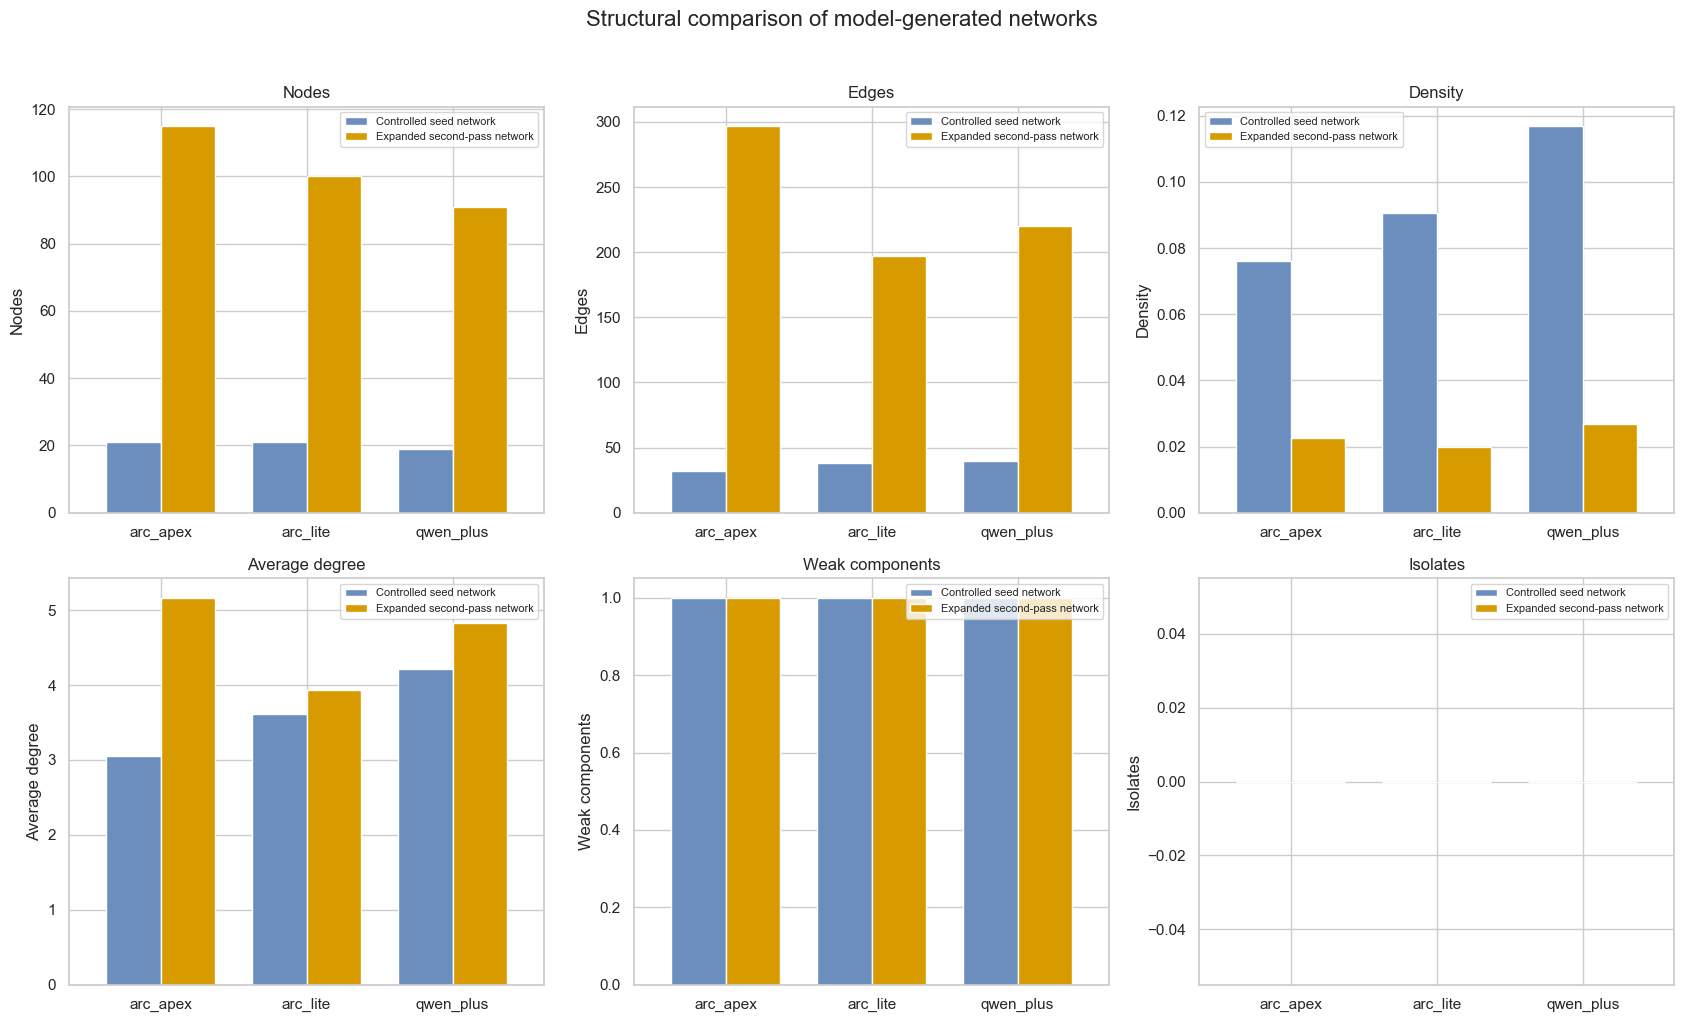

In [58]:
structure_metrics = [
    ("nodes", "Nodes"),
    ("edges", "Edges"),
    ("density", "Density"),
    ("average_degree", "Average degree"),
    ("weak_components", "Weak components"),
    ("isolates", "Isolates"),
]

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flatten()

for ax, (metric, title) in zip(axes, structure_metrics):
    plot_data = (
        network_summary_df
        .pivot(
            index="model",
            columns="network_type",
            values=metric,
        )
        .reindex(MODEL_ORDER)
    )

    plot_data = plot_data.rename(columns=NETWORK_NAMES)

    plot_data.plot(
        kind="bar",
        ax=ax,
        color=["#6C8EBF", "#D79B00"],
        width=0.75,
    )

    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(title)
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="", fontsize=8)

plt.suptitle(
    "Structural comparison of model-generated networks",
    fontsize=16,
    y=1.02,
)
plt.tight_layout()

plt.savefig(
    figures_dir / "01_network_structure_comparison.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

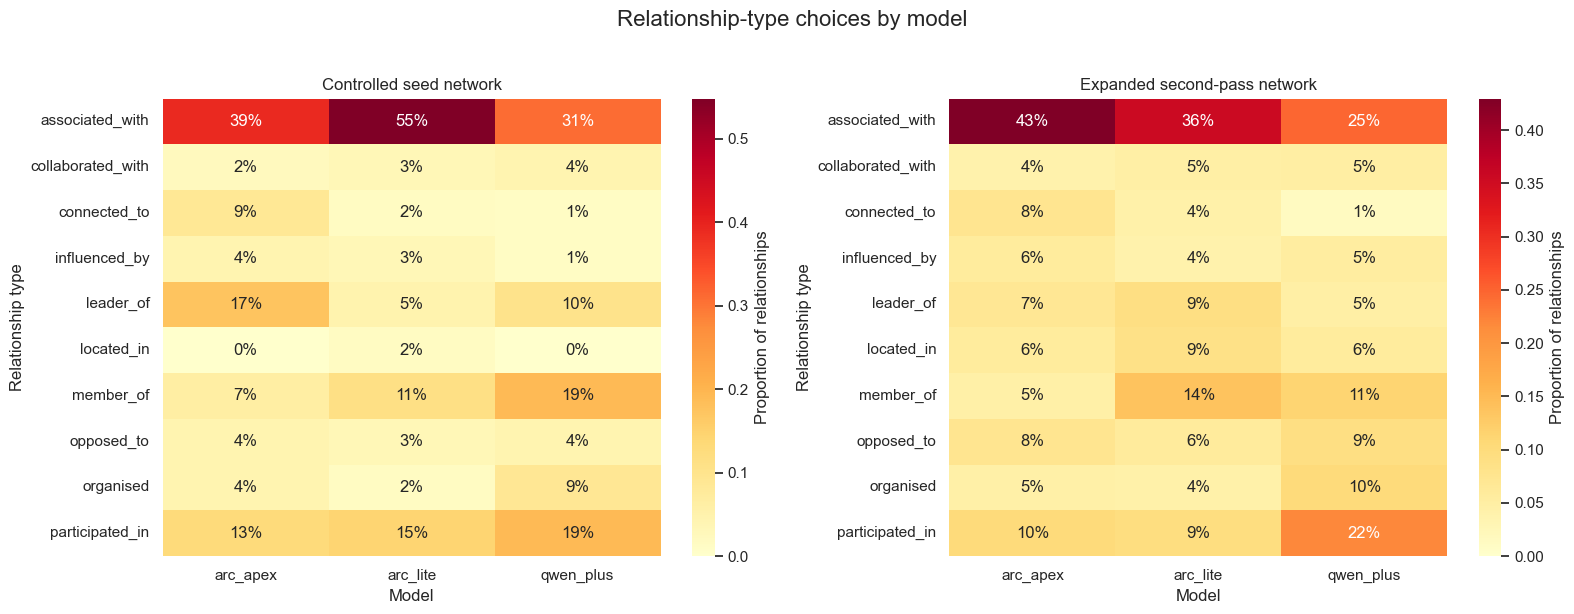

In [63]:
network_types = [
    "controlled_seed_network",
    "expanded_second_pass",
]

relation_order = sorted(
    relation_distribution_df["relation"].dropna().unique()
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, max(6, len(relation_order) * 0.55)),
)

for ax, network_type in zip(axes, network_types):
    subset = relation_distribution_df[
        relation_distribution_df["network_type"].eq(network_type)
    ]

    relation_matrix = (
        subset.pivot(
            index="relation",
            columns="model",
            values="proportion",
        )
        .reindex(index=relation_order, columns=MODEL_ORDER)
        .fillna(0)
    )

    sns.heatmap(
        relation_matrix,
        annot=True,
        fmt=".0%",
        cmap="YlOrRd",
        vmin=0,
        ax=ax,
        cbar_kws={"label": "Proportion of relationships"},
    )

    ax.set_title(NETWORK_NAMES[network_type])
    ax.set_xlabel("Model")
    ax.set_ylabel("Relationship type")

plt.suptitle(
    "Relationship-type choices by model",
    fontsize=16,
    y=1.02,
)
plt.tight_layout()

plt.savefig(
    figures_dir / "02_relation_type_heatmaps.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

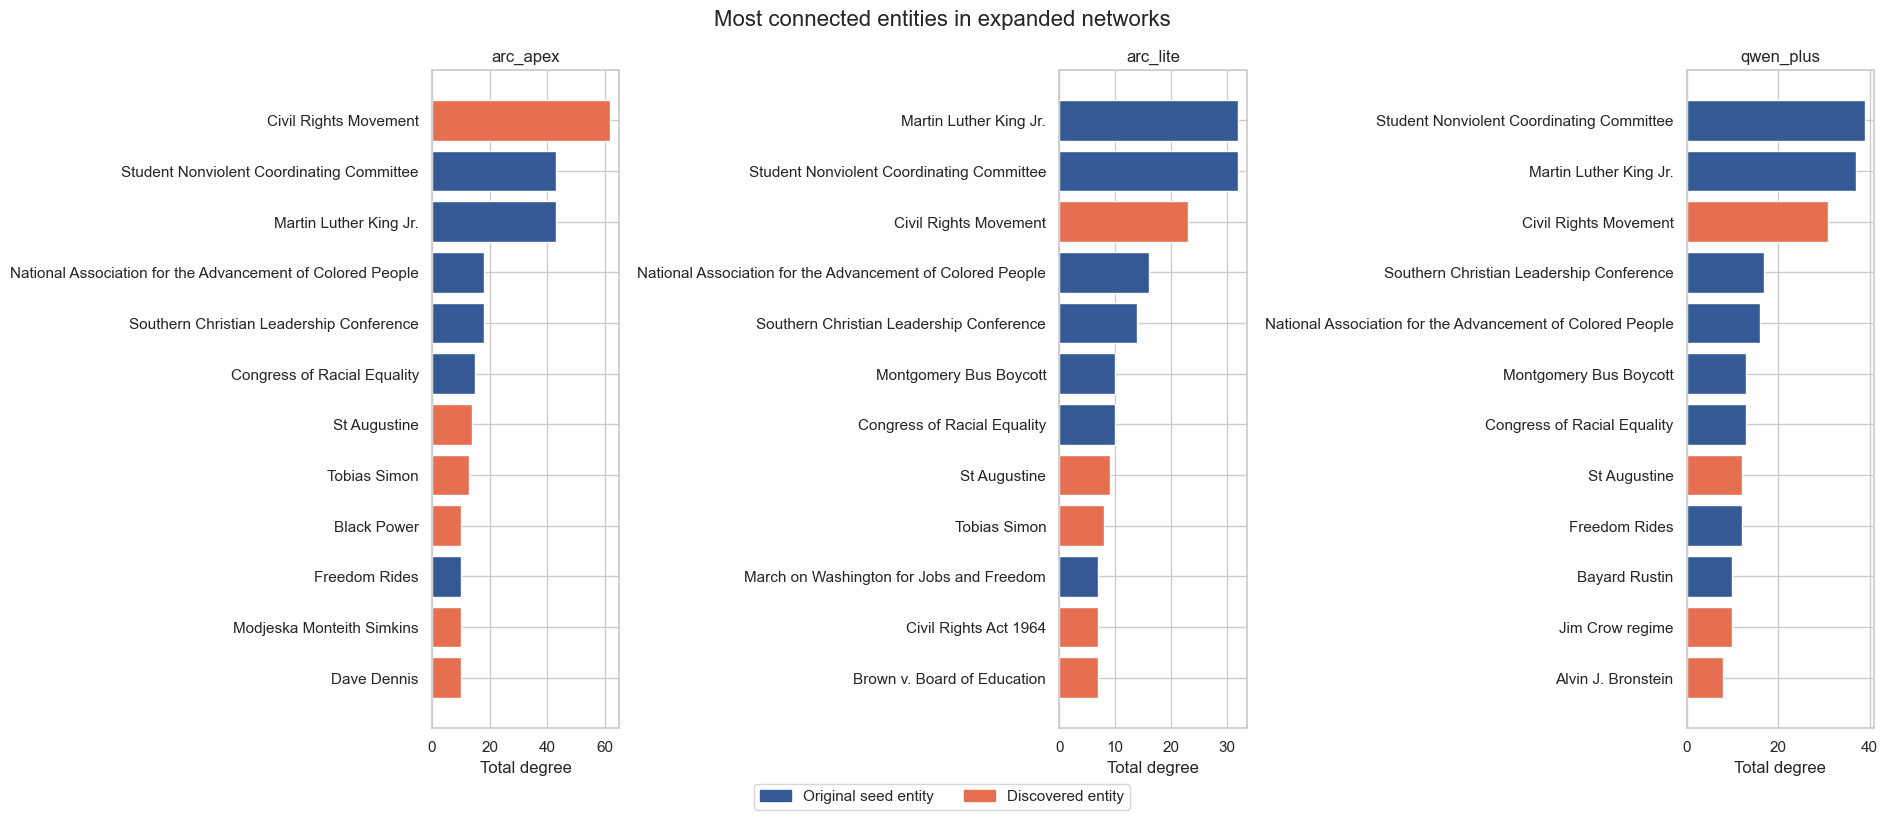

In [60]:
expanded_centrality = centrality_df[
    centrality_df["network_type"].eq("expanded_second_pass")
].copy()

top_central_nodes = (
    expanded_centrality
    .sort_values(
        ["model", "total_degree"],
        ascending=[True, False],
    )
    .groupby("model", group_keys=False)
    .head(12)
)

fig, axes = plt.subplots(
    1,
    len(MODEL_ORDER),
    figsize=(19, 8),
    sharex=False,
)

if len(MODEL_ORDER) == 1:
    axes = [axes]

for ax, model in zip(axes, MODEL_ORDER):
    model_data = (
        top_central_nodes[
            top_central_nodes["model"].eq(model)
        ]
        .sort_values("total_degree")
    )

    colours = [
        "#345995" if is_seed else "#E76F51"
        for is_seed in model_data["is_seed"]
    ]

    ax.barh(
        model_data["node"],
        model_data["total_degree"],
        color=colours,
    )

    ax.set_title(model)
    ax.set_xlabel("Total degree")
    ax.set_ylabel("")

legend_items = [
    Patch(color="#345995", label="Original seed entity"),
    Patch(color="#E76F51", label="Discovered entity"),
]

fig.legend(
    handles=legend_items,
    loc="lower center",
    ncol=2,
    bbox_to_anchor=(0.5, -0.03),
)

plt.suptitle(
    "Most connected entities in expanded networks",
    fontsize=16,
)
plt.tight_layout()

plt.savefig(
    figures_dir / "03_top_central_entities.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

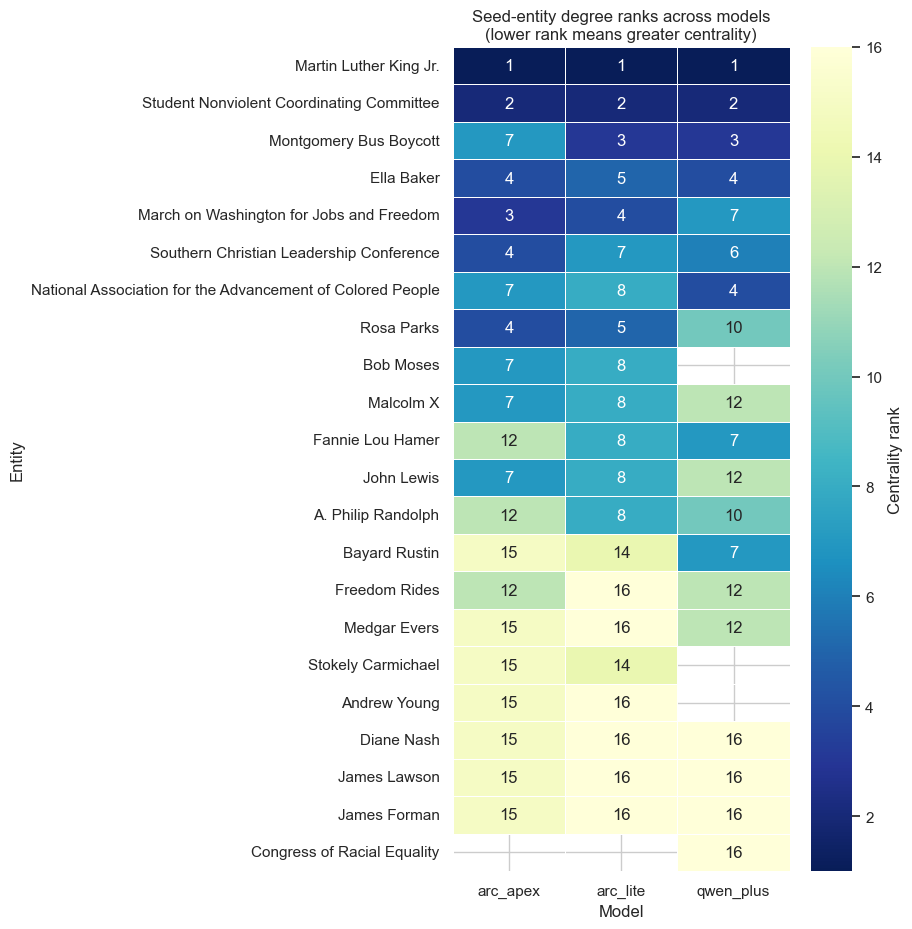

In [61]:
controlled_centrality = centrality_df[
    centrality_df["network_type"].eq(
        "controlled_seed_network"
    )
].copy()

seed_rank_matrix = (
    controlled_centrality
    .pivot(
        index="node",
        columns="model",
        values="total_degree_rank",
    )
    .reindex(columns=MODEL_ORDER)
)

seed_rank_matrix["mean_rank"] = (
    seed_rank_matrix.mean(axis=1)
)

seed_rank_matrix = (
    seed_rank_matrix
    .sort_values("mean_rank")
    .drop(columns="mean_rank")
)

plt.figure(
    figsize=(9, max(8, len(seed_rank_matrix) * 0.43))
)

sns.heatmap(
    seed_rank_matrix,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu_r",
    linewidths=0.4,
    cbar_kws={"label": "Centrality rank"},
)

plt.title(
    "Seed-entity degree ranks across models\n"
    "(lower rank means greater centrality)"
)
plt.xlabel("Model")
plt.ylabel("Entity")
plt.tight_layout()

plt.savefig(
    figures_dir / "04_seed_entity_rank_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

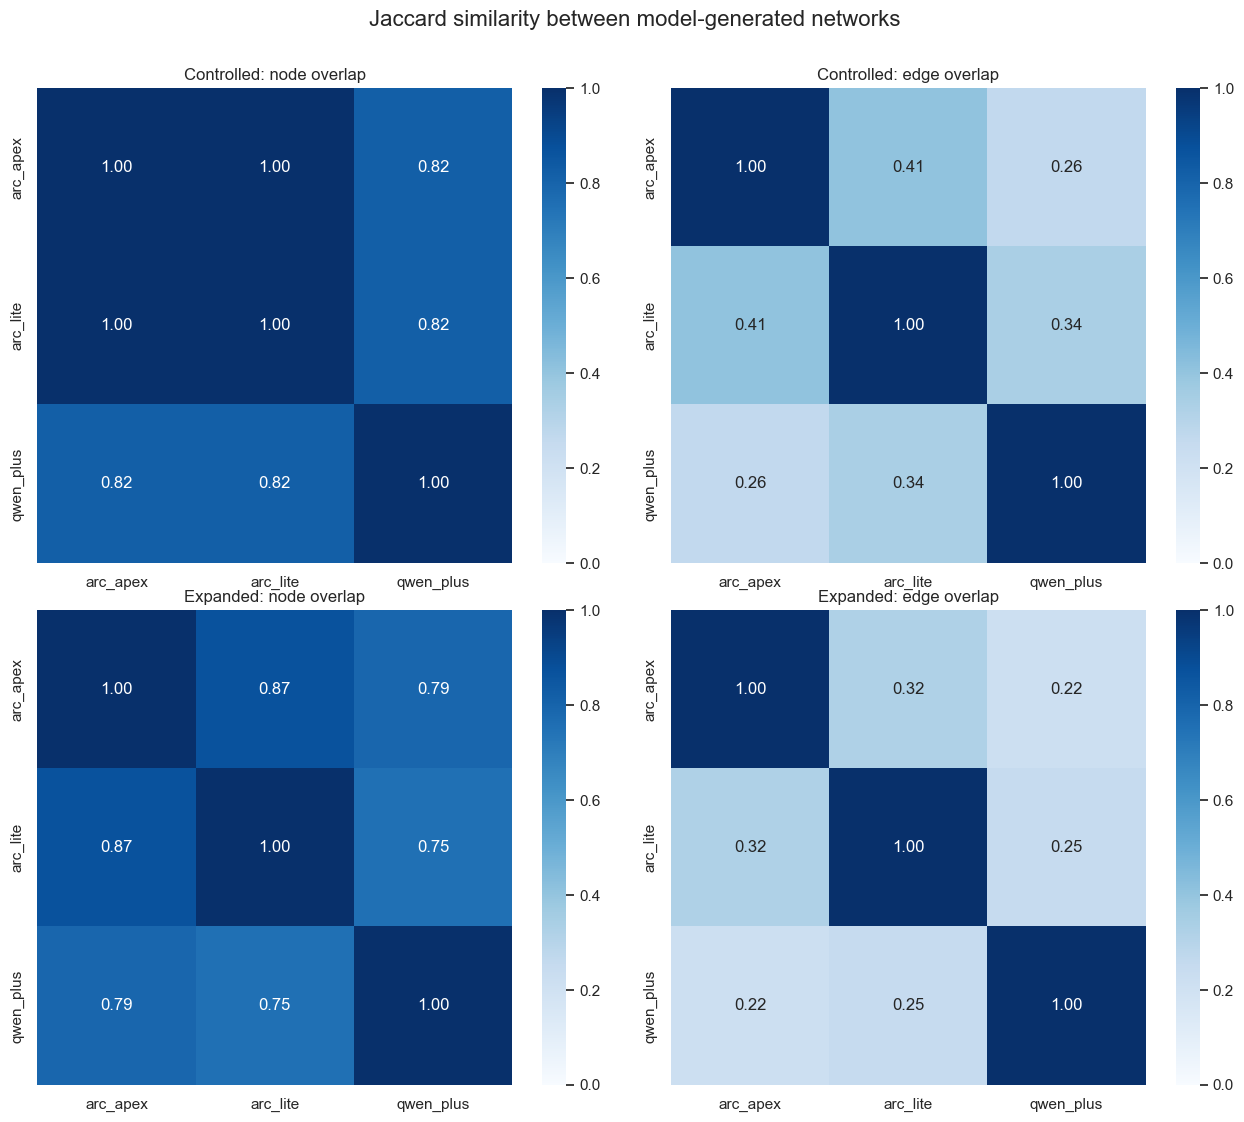

In [64]:
def build_overlap_matrix(data, network_type, metric):
    matrix = pd.DataFrame(
        np.eye(len(MODEL_ORDER)),
        index=MODEL_ORDER,
        columns=MODEL_ORDER,
    )

    subset = data[
        data["network_type"].eq(network_type)
    ]

    for _, row in subset.iterrows():
        model_a = row["model_a"]
        model_b = row["model_b"]

        matrix.loc[model_a, model_b] = row[metric]
        matrix.loc[model_b, model_a] = row[metric]

    return matrix


fig, axes = plt.subplots(2, 2, figsize=(13, 11))

settings = [
    ("controlled_seed", "node_jaccard", "Controlled: node overlap"),
    ("controlled_seed", "edge_jaccard", "Controlled: edge overlap"),
    ("expanded", "node_jaccard", "Expanded: node overlap"),
    ("expanded", "edge_jaccard", "Expanded: edge overlap"),
]

for ax, (network_type, metric, title) in zip(
    axes.flatten(),
    settings,
):
    matrix = build_overlap_matrix(
        pairwise_overlap_df,
        network_type,
        metric,
    )

    sns.heatmap(
        matrix,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        vmin=0,
        vmax=1,
        square=True,
        ax=ax,
    )

    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.suptitle(
    "Jaccard similarity between model-generated networks",
    fontsize=16,
    y=1.01,
)
plt.tight_layout()

plt.savefig(
    figures_dir / "05_model_overlap_heatmaps.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

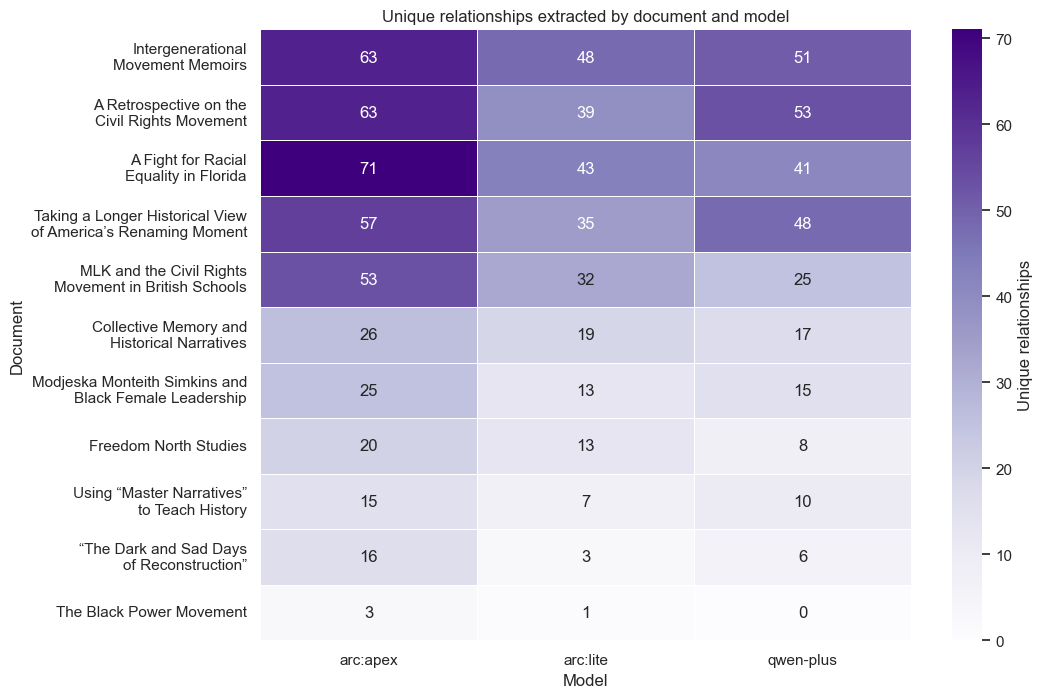

In [65]:
document_edge_counts = (
    combined_analysis_edges
    .groupby(["document", "model"])
    .size()
    .reset_index(name="unique_edges")
)

document_edge_matrix = (
    document_edge_counts
    .pivot(
        index="document",
        columns="model",
        values="unique_edges",
    )
    .reindex(columns=MODEL_ORDER)
    .fillna(0)
)

document_edge_matrix = document_edge_matrix.loc[
    document_edge_matrix.sum(axis=1).sort_values(
        ascending=False
    ).index
]


DOCUMENT_LABELS = {
    "Intergenerational movement memoirs and the emotional costs of activist commitment":
        "Intergenerational\nMovement Memoirs",

    "MorrisAnnRev1999CRM":
        "A Retrospective on the\nCivil Rights Movement",

    "A fight for racial equality in Florida":
        "A Fight for Racial\nEquality in Florida",

    "s41599-024-03182-3":
        "Taking a Longer Historical View\nof America’s Renaming Moment",

    "JAS - MLK teaching UK schools":
        "MLK and the Civil Rights\nMovement in British Schools",

    "Hughes":
        "Collective Memory and\nHistorical Narratives",

    "Modjeska Monteith Simkins and black female leadership  propriety  politics  place and periodization in the African American freedom struggle":
        "Modjeska Monteith Simkins and\nBlack Female Leadership",

    "Brian-Purnell_Freedom-North-Studies-the-Long-Civil-Rights-Movement-and-Twentieth-Century-Liberalism-in-American-Cities":
        "Freedom North Studies",

    "M12_Frost":
        "Using “Master Narratives”\nto Teach History",

    "the-dark-and-sad-days-of-reconstruction-the-politics-of-memory-in-the-civil-rights-era":
        "“The Dark and Sad Days\nof Reconstruction”",

    "The Black Power Movement  A historiographical understanding of how scholarship has shaped the legacy of the Black Power Movement":
        "The Black Power Movement",
}

MODEL_LABELS = {
    "arc_apex": "arc:apex",
    "arc_lite": "arc:lite",
    "qwen_plus": "qwen-plus",
}

heatmap_display = document_edge_matrix.rename(
    index=DOCUMENT_LABELS,
    columns=MODEL_LABELS
)

plt.figure(
    figsize=(11, max(7, len(heatmap_display) * 0.65))
)

sns.heatmap(
    heatmap_display,
    annot=True,
    fmt=".0f",
    cmap="Purples",
    linewidths=0.4,
    cbar_kws={"label": "Unique relationships"},
)

plt.title("Unique relationships extracted by document and model")
plt.xlabel("Model")
plt.ylabel("Document")
plt.tight_layout()

plt.savefig(
    figures_dir / "06_document_relationship_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

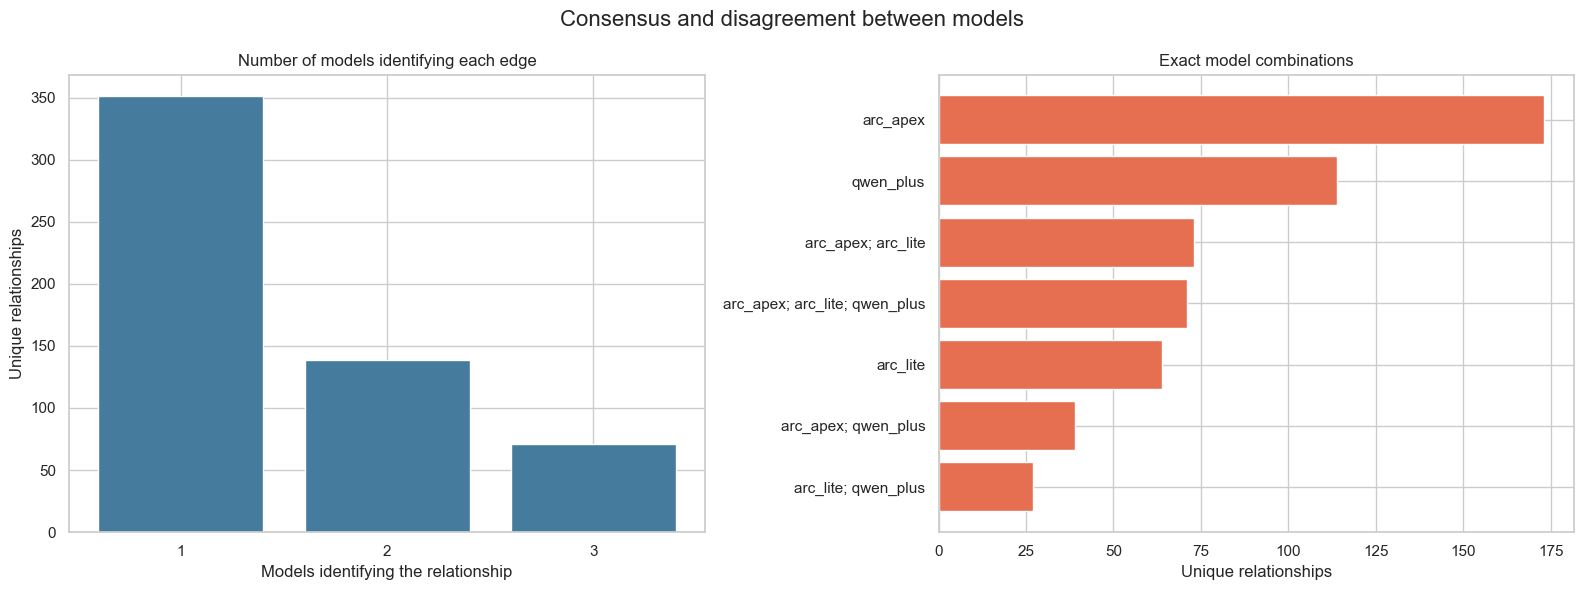

In [66]:
agreement_counts = (
    edge_presence_df["number_of_models"]
    .value_counts()
    .reindex(
        range(1, len(MODEL_ORDER) + 1),
        fill_value=0,
    )
    .sort_index()
)

combination_counts = (
    edge_presence_df["models_present"]
    .value_counts()
    .sort_values()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(
    agreement_counts.index.astype(str),
    agreement_counts.values,
    color="#457B9D",
)

axes[0].set_title("Number of models identifying each edge")
axes[0].set_xlabel("Models identifying the relationship")
axes[0].set_ylabel("Unique relationships")

axes[1].barh(
    combination_counts.index,
    combination_counts.values,
    color="#E76F51",
)

axes[1].set_title("Exact model combinations")
axes[1].set_xlabel("Unique relationships")
axes[1].set_ylabel("")

plt.suptitle(
    "Consensus and disagreement between models",
    fontsize=16,
)
plt.tight_layout()

plt.savefig(
    figures_dir / "07_edge_agreement.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

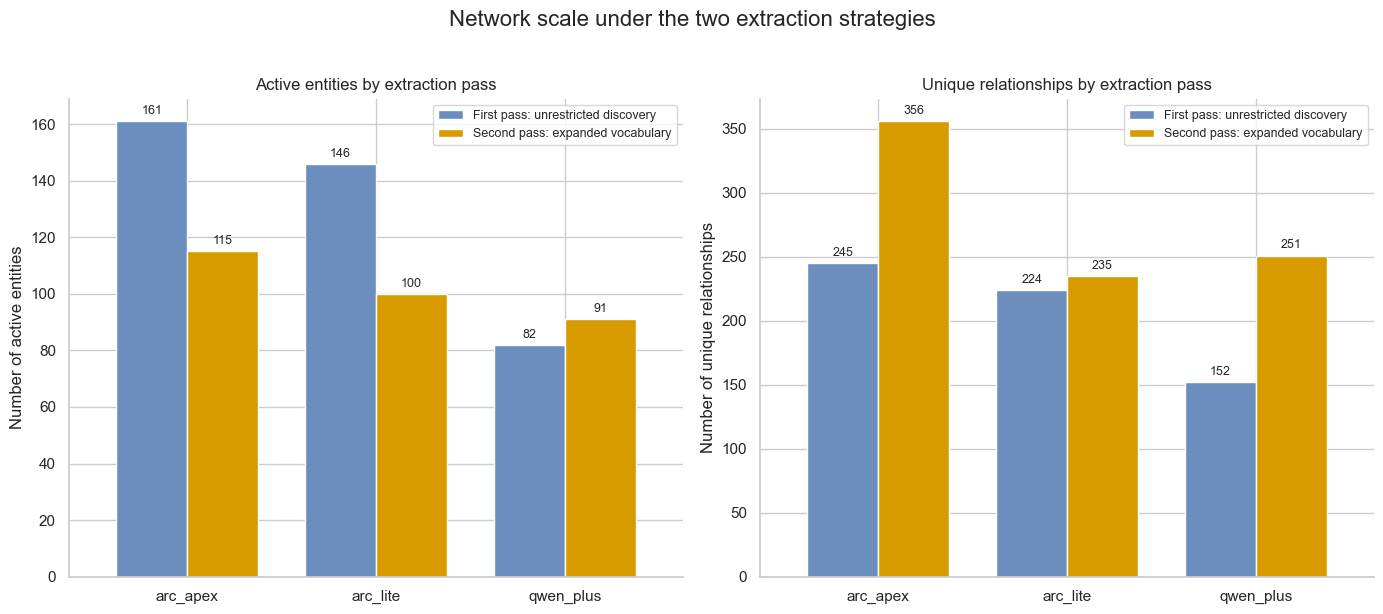

In [67]:
STAGE_ORDER = [
    "first_pass", 
    "combined_after_second_pass"
]

STAGE_LABELS = {
    "first_pass": "First pass: unrestricted discovery",
    "combined_after_second_pass": "Second pass: expanded vocabulary"
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, metric, title, ylabel in [
    (axes[0], "nodes", "Active entities by extraction pass", "Number of active entities"),
    (axes[1], "edges", "Unique relationships by extraction pass", "Number of unique relationships"),
]:
    comparison_matrix = (
        pass_growth_df
        .pivot(
            index="model",
            columns="stage",
            values=metric,
        )
        .reindex(index=MODEL_ORDER)
        .reindex(columns=STAGE_ORDER)
    )

    comparison_matrix.plot(
        kind="bar",
        ax=ax,
        color=["#6C8EBF", "#D79B00"],
        width=0.75,
    )

    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=0)
    ax.legend(
        [STAGE_LABELS[column] for column in comparison_matrix.columns],
        title="",
        fontsize=9
    )
    
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.0f",
            padding=3,
            fontsize=9,
        )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle(
    "Network scale under the two extraction strategies",
    fontsize=16,
    y=1.02,
)

plt.tight_layout()

plt.savefig(
    figures_dir / "08_first_second_pass_network_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

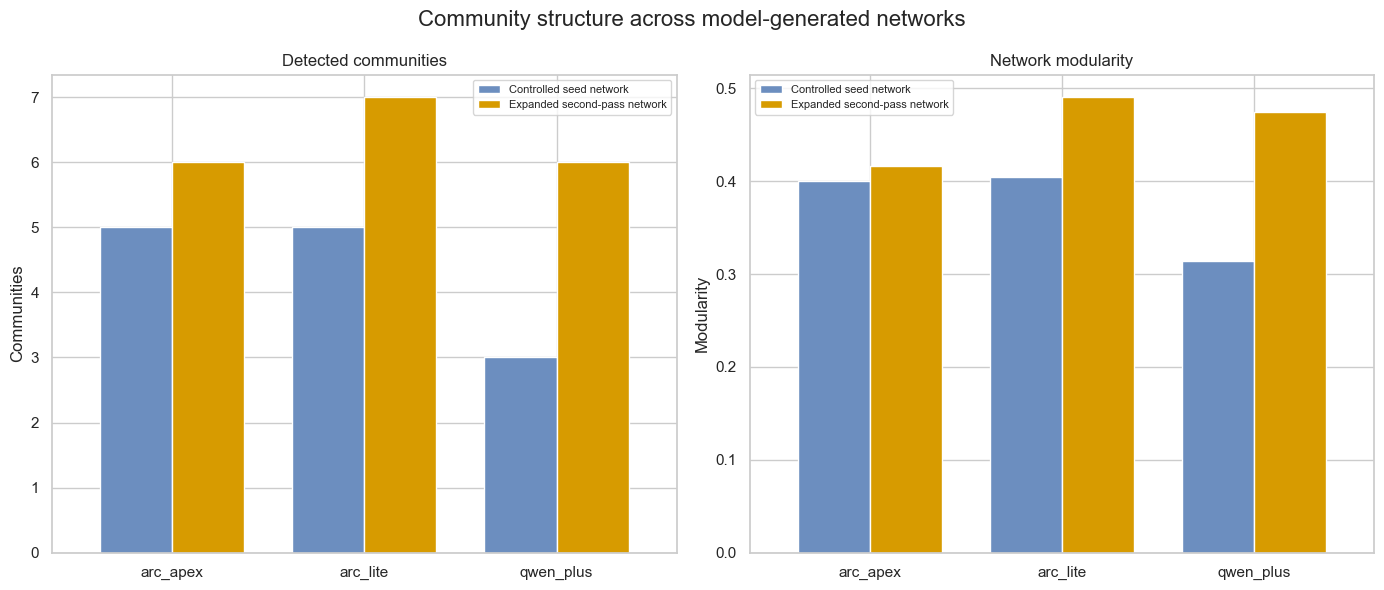

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, metric, title in [
    (axes[0], "communities", "Detected communities"),
    (axes[1], "modularity", "Network modularity"),
]:
    community_matrix = (
        modularity_df
        .pivot(
            index="model",
            columns="network_type",
            values=metric,
        )
        .reindex(MODEL_ORDER)
        .rename(columns=NETWORK_NAMES)
    )

    community_matrix.plot(
        kind="bar",
        ax=ax,
        color=["#6C8EBF", "#D79B00"],
        width=0.75,
    )

    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(metric.title())
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="", fontsize=8)

plt.suptitle(
    "Community structure across model-generated networks",
    fontsize=16,
)
plt.tight_layout()

plt.savefig(
    figures_dir / "09_community_comparison.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

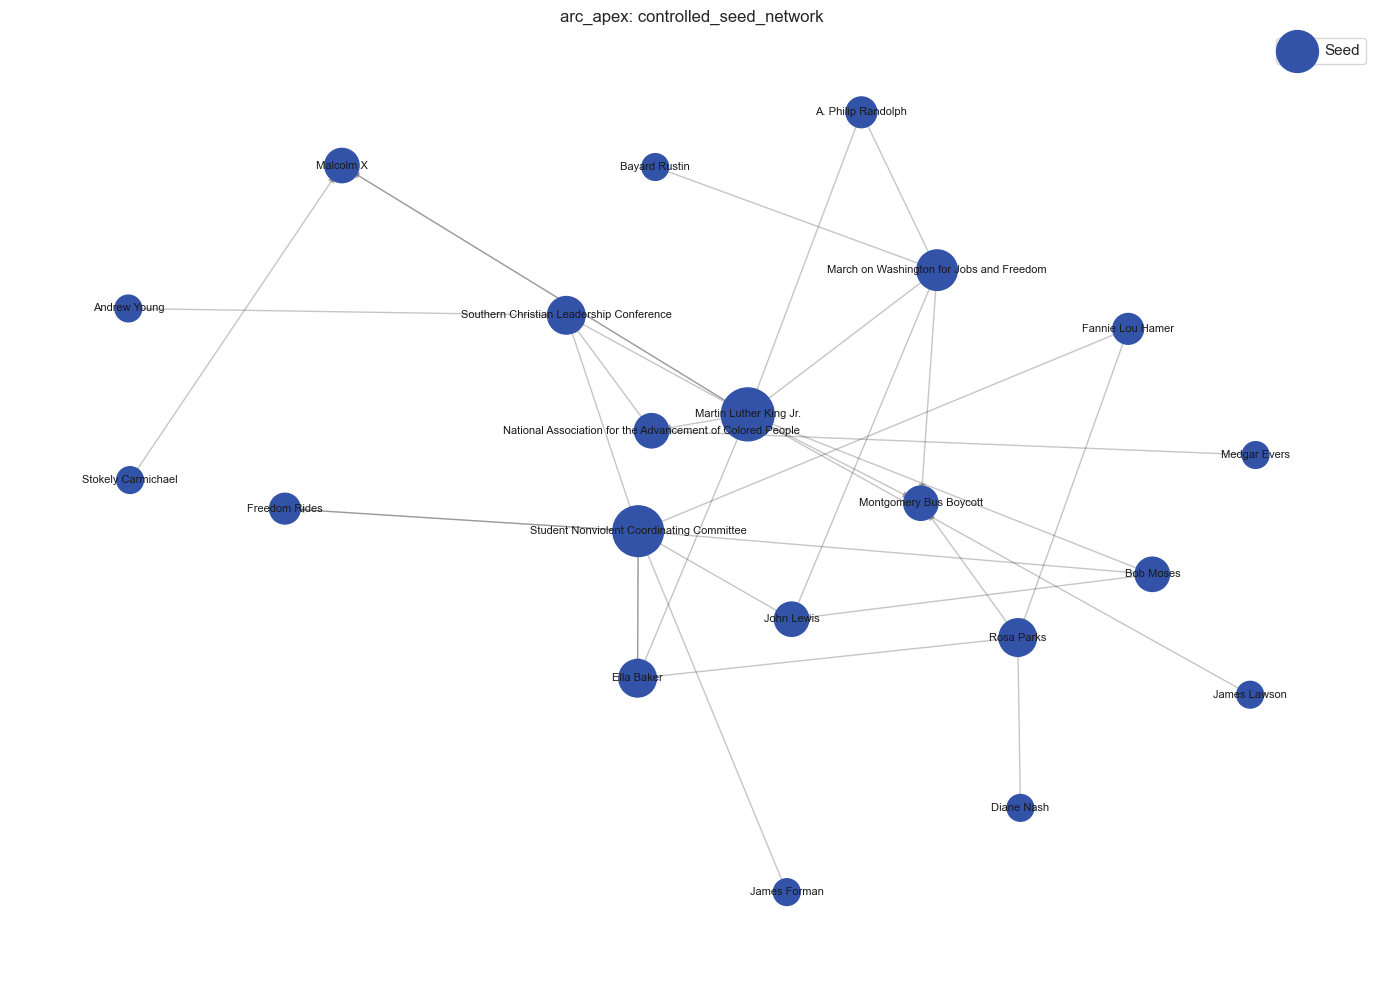

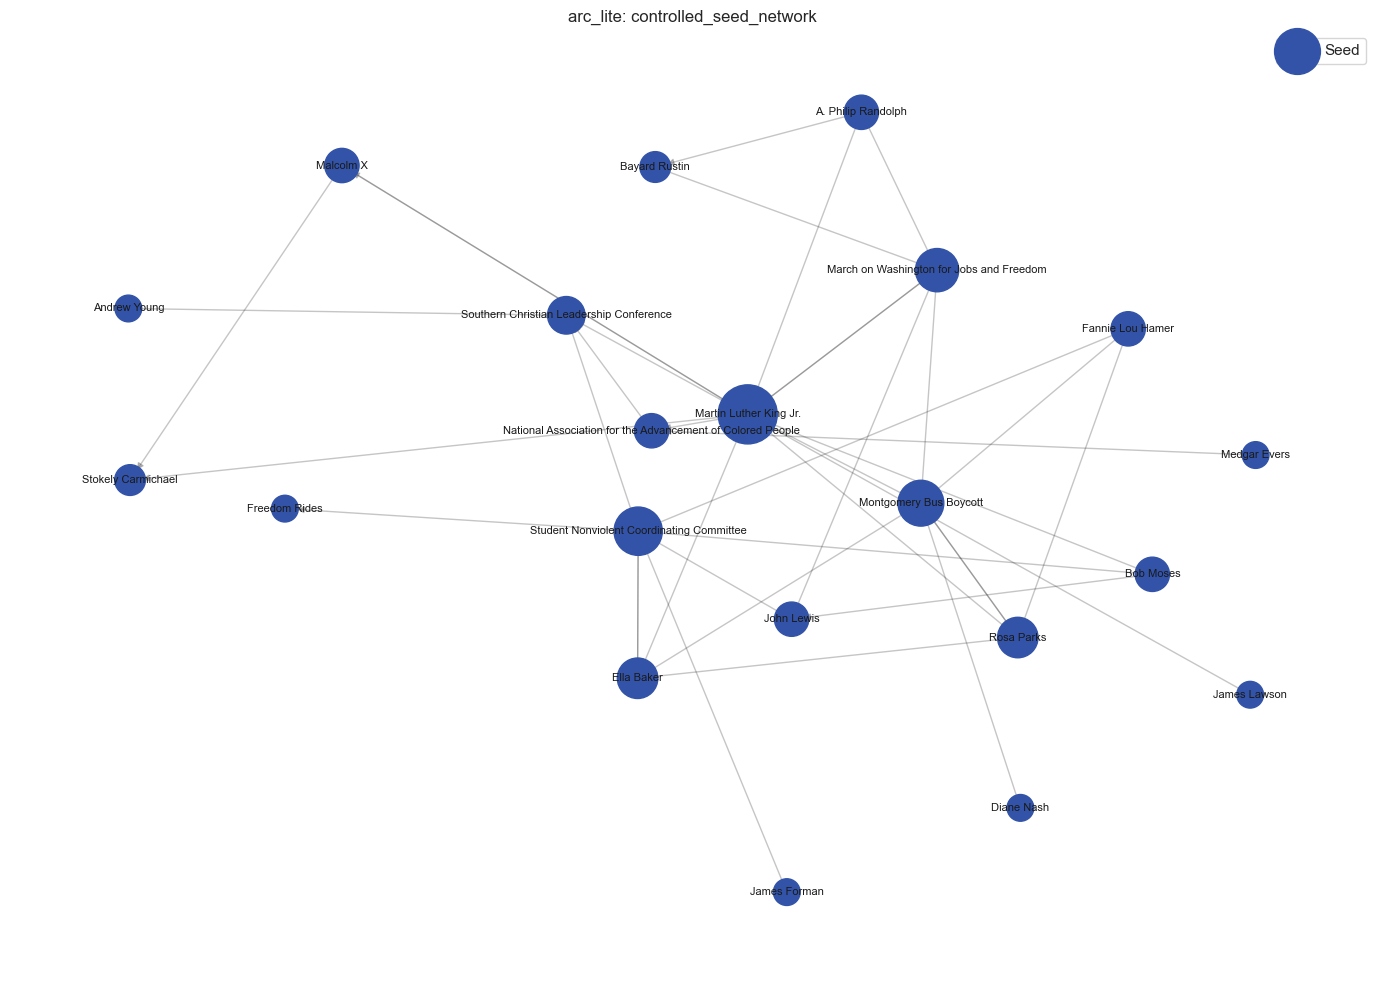

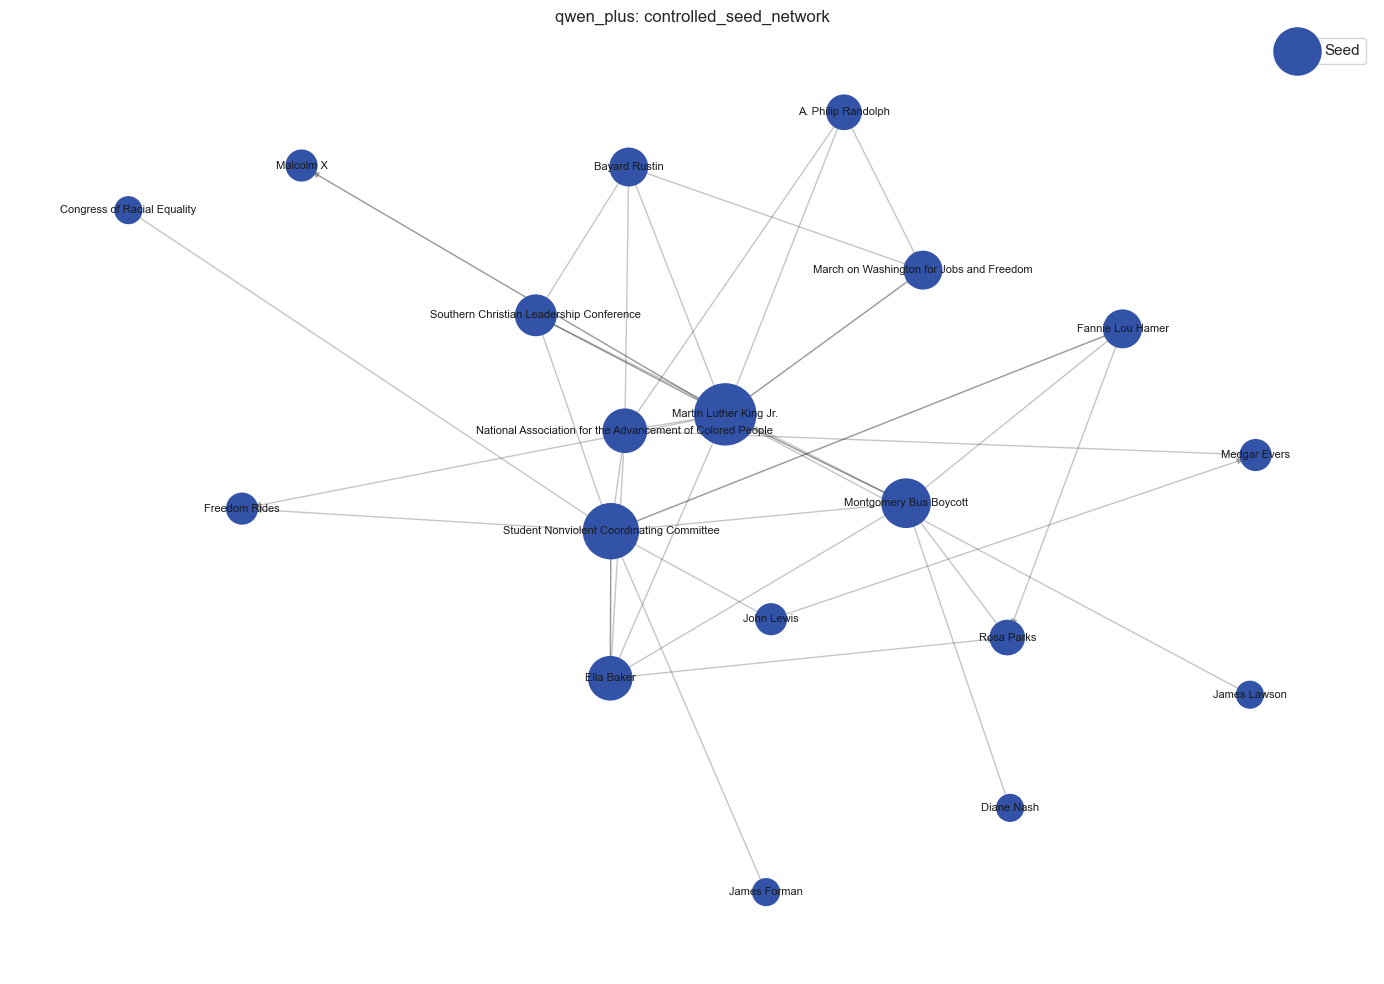

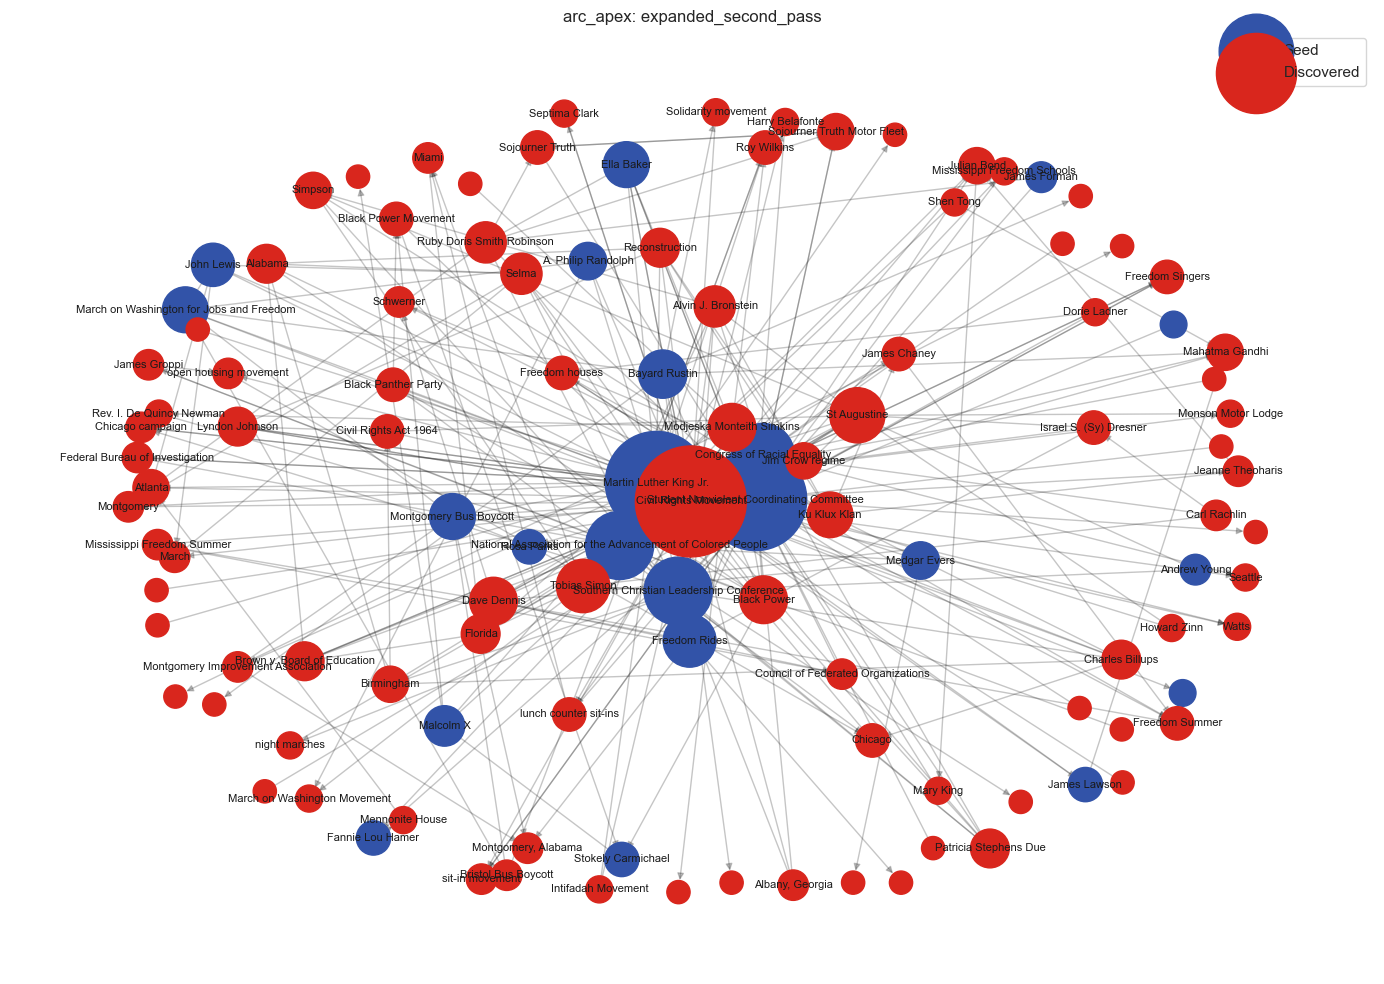

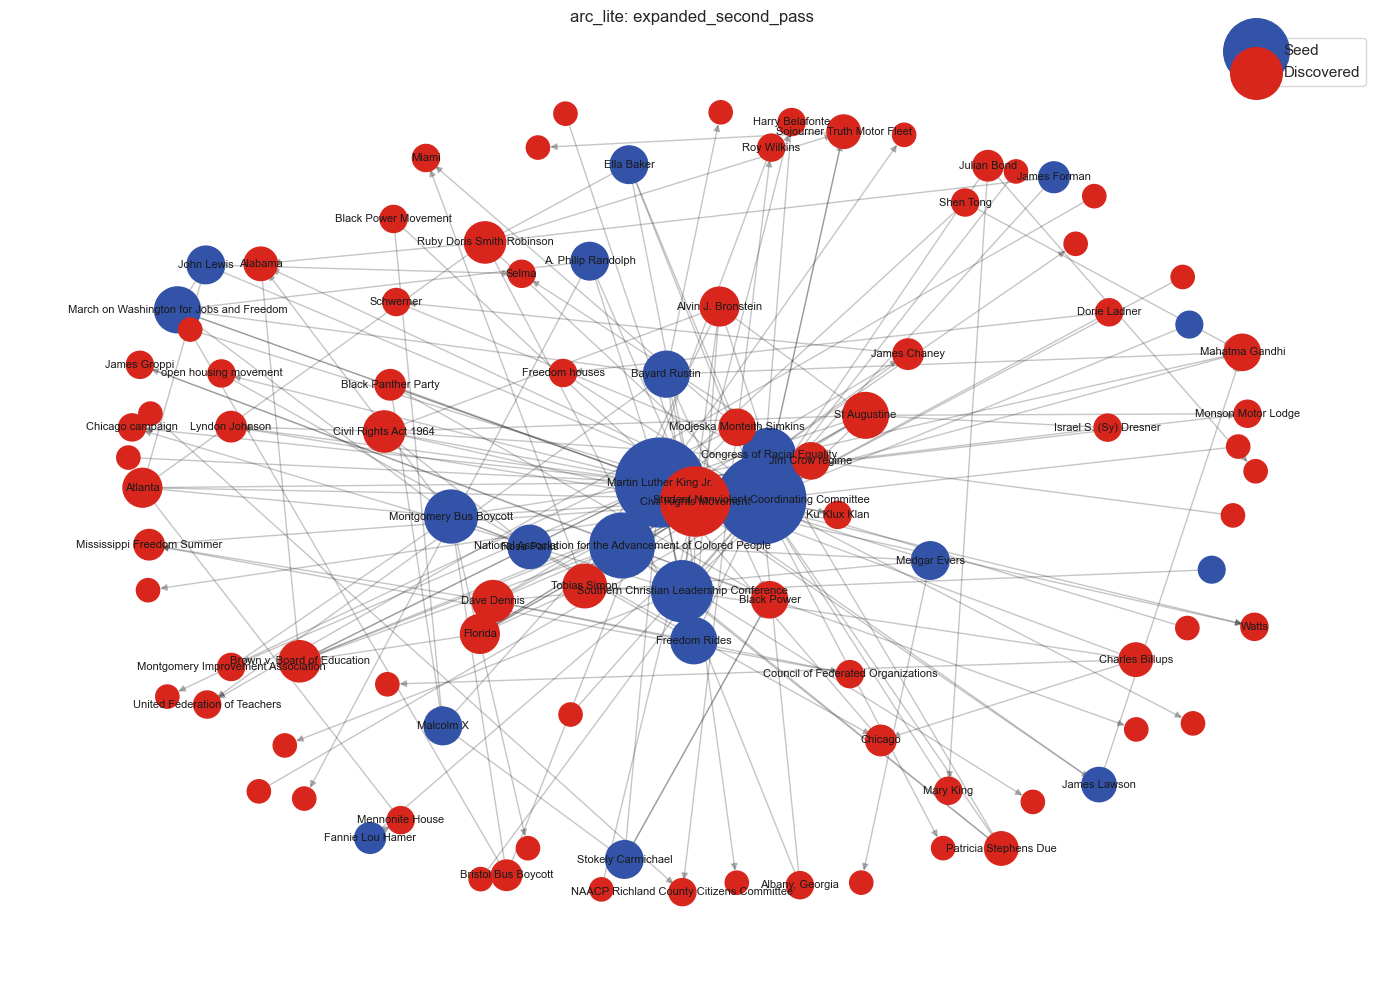

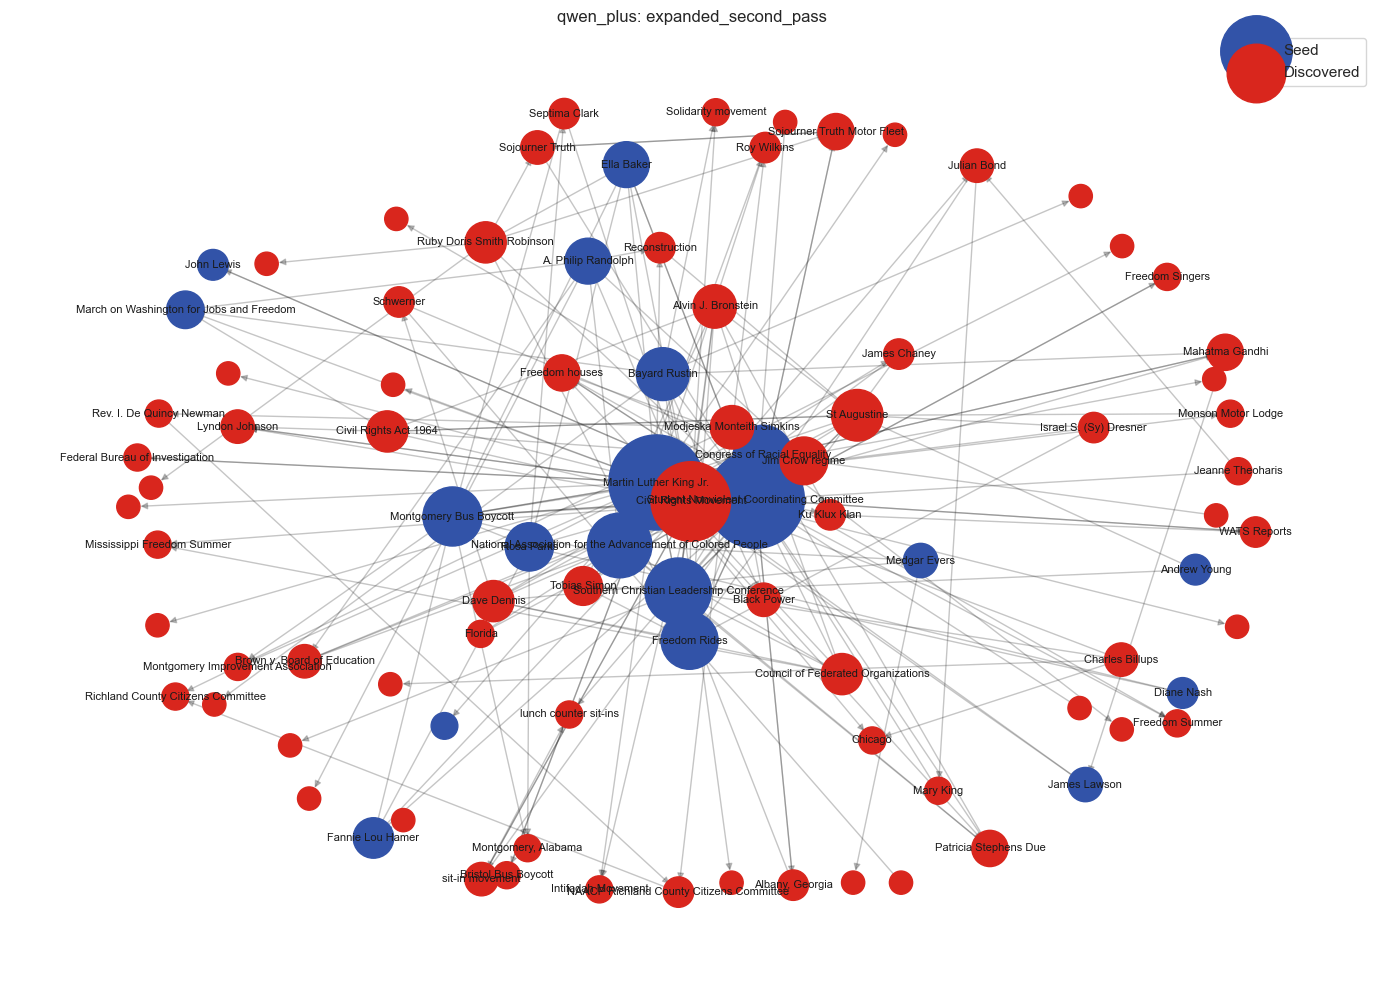

In [69]:
def plot_graph_family(
    graphs,
    network_type,
    label_degree=2
):
    union_graph = nx.compose_all(
        [graph.to_undirected() for graph in graphs.values()]
    )
    common_positions = nx.spring_layout(union_graph, seed=42,k=1.2,)

    for model, graph in graphs.items():
        plt.figure(figsize=(14,10))

        seed_nodes = [
            node for node in graph if node in seed_entities
        ]
        discovered_nodes = [
            node for node in graph if node not in seed_entities
        ]

        nx.draw_networkx_nodes(
            graph,
            common_positions,
            nodelist=seed_nodes,
            node_color="#3253A8",
            node_size=[
                250 + 120 * graph.degree(node)
                for node in seed_nodes
            ],
            label="Seed"
        )
        nx.draw_networkx_nodes(
            graph,
            common_positions,
            nodelist=discovered_nodes,
            node_color="#D9261D",
            node_size=[
                180 + 100 * graph.degree(node)
                for node in discovered_nodes
            ],
            label="Discovered"
        )
        nx.draw_networkx_edges(
            graph,
            common_positions,
            arrows=True,
            alpha=0.25,
            arrowsize=10
        )
        labels = {
            node: node
            for node in graph
            if graph.degree(node) >= label_degree
        }
        nx.draw_networkx_labels(
            graph,
            common_positions,
            labels=labels,
            font_size=8
        )

        plt.title(f"{model}: {network_type}")
        plt.legend()
        plt.axis("off")
        plt.tight_layout()
        plt.savefig(
            run_dir / f"{model}_{network_type}.png",
            dpi=300,
            bbox_inches="tight"
        )
        plt.show()
        plt.close()


plot_graph_family(
    controlled_graphs,
    "controlled_seed_network",
    label_degree=1
)
plot_graph_family(
    expanded_graphs,
    "expanded_second_pass",
    label_degree=2
)

In [70]:
display(network_summary_df)
display(pairwise_overlap_df)
display(modularity_df)
display(pass_growth_df)

,network_type,model,nodes,edges,density,weak_components,isolates,average_degree
0,controlled_seed_network,arc_apex,21,32,0.076190,1,0,3.047619
1,controlled_seed_network,arc_lite,21,38,0.090476,1,0,3.619048
2,controlled_seed_network,qwen_plus,19,40,0.116959,1,0,4.210526
3,expanded_second_pass,arc_apex,115,297,0.022654,1,0,5.165217
4,expanded_second_pass,arc_lite,100,197,0.019899,1,0,3.940000
5,expanded_second_pass,qwen_plus,91,220,0.026862,1,0,4.835165


,network_type,model_a,model_b,shared_nodes,node_union,node_jaccard,shared_edges,edge_union,edge_jaccard,unique_to_a,unique_to_b
0,controlled_seed,arc_apex,arc_lite,21,21,1.000000,25,61,0.409836,14,22
1,controlled_seed,arc_apex,qwen_plus,18,22,0.818182,19,72,0.263889,20,33
2,controlled_seed,arc_lite,qwen_plus,18,22,0.818182,25,74,0.337838,22,27
3,expanded,arc_apex,arc_lite,100,115,0.869565,144,447,0.322148,212,91
4,expanded,arc_apex,qwen_plus,91,115,0.791304,110,497,0.221328,246,141
5,expanded,arc_lite,qwen_plus,82,109,0.752294,98,388,0.252577,137,153


,network_type,model,communities,modularity
0,controlled_seed_network,arc_apex,5,0.400713
1,controlled_seed_network,arc_lite,5,0.404412
2,controlled_seed_network,qwen_plus,3,0.314446
3,expanded_second_pass,arc_apex,6,0.416457
4,expanded_second_pass,arc_lite,7,0.490479
5,expanded_second_pass,qwen_plus,6,0.474952


,model,stage,nodes,edges
0,arc_apex,first_pass,161,245
1,arc_apex,combined_after_second_pass,115,356
2,arc_lite,first_pass,146,224
3,arc_lite,combined_after_second_pass,100,235
4,qwen_plus,first_pass,82,152
5,qwen_plus,combined_after_second_pass,91,251


In [72]:
edges = combined_analysis_edges.copy()

required_cols = ["model", "source", "relation", "target"]
missing_cols = [col for col in required_cols if col not in edges.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

edges["edge_key"] = (
    edges["source"].astype(str).str.strip() + " | " +
    edges["relation"].astype(str).str.strip() + " | " +
    edges["target"].astype(str).str.strip()
)

edge_model_counts = (
    edges
    .groupby("edge_key", dropna=False)
    .agg(
        model_count=("model", "nunique"),
        models=("model", lambda x: "; ".join(sorted(set(map(str, x))))),
        occurrences=("edge_key", "size"),
        source=("source", "first"),
        relation=("relation", "first"),
        target=("target", "first")
    )
    .reset_index()
)

edges_with_counts = edges.merge(
    edge_model_counts[["edge_key", "model_count", "models", "occurrences"]],
    on="edge_key",
    how="left"
)

model_specific_examples = edges_with_counts[
    edges_with_counts["model_count"] == 1
].copy()

sort_columns = ["model", "relation", "occurrences"]
ascending_values = [True, True, False]

if "confidence" in model_specific_examples.columns:
    sort_columns.append("confidence")
    ascending_values.append(False)

model_specific_examples = model_specific_examples.sort_values(
    sort_columns,
    ascending=ascending_values
)

columns_to_show = [
    "model",
    "document",
    "chunk",
    "source",
    "relation",
    "target",
    "occurrences",
    "confidence",
    "evidence"
]

columns_to_show = [
    col for col in columns_to_show
    if col in model_specific_examples.columns
]

display(model_specific_examples[columns_to_show].head(50))

save_folder = final_tables_dir if "final_tables_dir" in globals() else run_dir

model_specific_examples.to_csv(
    save_folder / "model_specific_edge_examples_for_analysis.csv",
    index=False
)

print("Saved model-specific examples to:")
print(save_folder / "model_specific_edge_examples_for_analysis.csv")

,model,document,source,relation,target,occurrences,evidence
82,arc_apex,Brian-Purnell_Freedom-North-Studies-the-Long-C...,Civil Rights Movement,associated_with,Jeanne Theoharis,3,the influential anthology edited by Jeanne The...
98,arc_apex,Hughes,Civil Rights Movement,associated_with,Jeanne Theoharis,3,As historian Jeanne Theoharis (2018: xiv) cont...
197,arc_apex,JAS - MLK teaching UK schools,Civil Rights Movement,associated_with,Jeanne Theoharis,3,"Jeanne Theoharis, ""Hidden in Plain Sight: The ..."
14,arc_apex,A fight for racial equality in Florida,Brooklyn,associated_with,Congress of Racial Equality,2,the Brooklyn branch of CORE
80,arc_apex,Brian-Purnell_Freedom-North-Studies-the-Long-C...,Brooklyn,associated_with,Congress of Racial Equality,2,The Congress of Racial Equality in Brooklyn
95,arc_apex,Hughes,Black Power Movement,associated_with,Civil Rights Movement,2,the positive contributions of the Black Power ...
105,arc_apex,Hughes,I Have a Dream speech,associated_with,Martin Luther King Jr.,2,King's 'I have a dream' speech in 1963
112,arc_apex,Hughes,Martin Luther King Jr.,associated_with,Poor People's Campaign,2,King and the Other America: The poor people's ...
184,arc_apex,JAS - MLK teaching UK schools,Black Panther Party,associated_with,Black Power Movement,2,Black Power is often reduced to symbols associ...
200,arc_apex,JAS - MLK teaching UK schools,Civil Rights Movement,associated_with,Rosa Parks,2,That even Rosa Parks remains unnamed in this s...


Saved model-specific examples to:
C:\Users\Zoe Walton\OneDrive\Masters yay\1.1 Dissertation\Civil Rights\Outputs\LLM Model Comparison\FINAL_SUBMISSION_2026_09_06\tables\model_specific_edge_examples_for_analysis.csv


In [73]:
pair_relation_summary = (
    edges
    .groupby(["source", "target"])
    .agg(
        relation_count=("relation", "nunique"),
        relations=("relation", lambda x: "; ".join(sorted(set(map(str, x))))),
        model_count=("model", "nunique"),
        models=("model", lambda x: "; ".join(sorted(set(map(str, x))))),
        documents=("document", lambda x: "; ".join(sorted(set(map(str, x))))),
        example_evidence=("evidence", lambda x: " || ".join(list(x.dropna().astype(str).head(3))))
    )
    .reset_index()
)

same_pair_different_relation = pair_relation_summary[
    (pair_relation_summary["relation_count"] > 1)
    & (pair_relation_summary["model_count"] > 1)
].sort_values(["relation_count", "model_count"], ascending=False)

display(same_pair_different_relation.head(50))

same_pair_different_relation.to_csv(
    output_dir / "same_pair_different_relation_examples.csv",
    index=False
)

,source,target,relation_count,relations,model_count,models,documents,example_evidence
153,Dave Dennis,Medgar Evers,5,associated_with; collaborated_with; connected_...,3,arc_apex; arc_lite; qwen_plus,Intergenerational movement memoirs and the emo...,I remember my last words with my friend Medgar...
290,Modjeska Monteith Simkins,National Association for the Advancement of Co...,5,associated_with; leader_of; member_of; opposed...,3,arc_apex; arc_lite; qwen_plus,Modjeska Monteith Simkins and black female lea...,Modjeska Simkins and the South Carolina Confer...
152,Dave Dennis,James Chaney,4,associated_with; collaborated_with; connected_...,3,arc_apex; arc_lite; qwen_plus,Intergenerational movement memoirs and the emo...,Dennis's eulogy at Chaney's memorial || his fr...
293,Modjeska Monteith Simkins,Richland County Citizens Committee,4,associated_with; leader_of; member_of; organised,3,arc_apex; arc_lite; qwen_plus,Modjeska Monteith Simkins and black female lea...,"RCCC Radio Programme, 21 June 1972, 1: Simkins..."
357,Sojourner Truth Motor Fleet,Student Nonviolent Coordinating Committee,4,associated_with; connected_to; member_of; orga...,3,arc_apex; arc_lite; qwen_plus,s41599-024-03182-3,SNCC leaders such as Robinson to rename their ...
364,Southern Christian Leadership Conference,St Augustine,4,associated_with; connected_to; organised; part...,3,arc_apex; arc_lite; qwen_plus,A fight for racial equality in Florida,Smathers... suspected that the SCLC faked the ...
1,A. Philip Randolph,Civil Rights Movement,3,associated_with; leader_of; participated_in,3,arc_apex; arc_lite; qwen_plus,MorrisAnnRev1999CRM; the-dark-and-sad-days-of-...,"The expertise of leaders such as Ella Baker, A..."
22,Alvin J. Bronstein,St Augustine,3,associated_with; located_in; participated_in,3,arc_apex; arc_lite; qwen_plus,A fight for racial equality in Florida,By helping to make the law applicable to St Au...
32,Bayard Rustin,Civil Rights Movement,3,associated_with; leader_of; participated_in,3,arc_apex; arc_lite; qwen_plus,Brian-Purnell_Freedom-North-Studies-the-Long-C...,Jerald Podair (2008). Bayard Rustin: American ...
33,Bayard Rustin,Freedom Budget for All Americans,3,associated_with; leader_of; organised,3,arc_apex; arc_lite; qwen_plus,Brian-Purnell_Freedom-North-Studies-the-Long-C...,He championed a Freedom Budget for All America...


In [75]:
edges = combined_analysis_edges.copy()

top_entities = (
    centrality_df[
        centrality_df["network_type"].eq("expanded_second_pass")
    ]
    .sort_values(["model", "total_degree"], ascending=[True, False])
    .groupby("model")
    .head(10)
    [["model", "node", "total_degree", "pagerank", "betweenness"]]
)

entity_evidence_rows = []

for _, row in top_entities.iterrows():
    model = row["model"]
    node = row["node"]

    node_edges = edges[
        (edges["model"] == model)
        & (
            (edges["source"] == node)
            | (edges["target"] == node)
        )
    ].copy()
    
    if "confidence" in node_edges.columns:
        node_edges = node_edges.sort_values("confidence", ascending=False)
    else:
        node_edges = node_edges.sort_values(
            [col for col in ["document", "chunk", "source", "relation", "target"] if col in node_edges.columns]
        )

    node_edges = node_edges.head(5)

    for _, edge in node_edges.iterrows():
        entity_evidence_rows.append({
            "model": model,
            "entity": node,
            "total_degree": row["total_degree"],
            "pagerank": row["pagerank"],
            "betweenness": row["betweenness"],
            "document": edge.get("document", ""),
            "chunk": edge.get("chunk", ""),
            "source": edge.get("source", ""),
            "relation": edge.get("relation", ""),
            "target": edge.get("target", ""),
            "confidence": edge.get("confidence", ""),
            "evidence": edge.get("evidence", "")
        })

top_entity_evidence_df = pd.DataFrame(entity_evidence_rows)

display(top_entity_evidence_df.head(60))

save_folder = final_tables_dir if "final_tables_dir" in globals() else run_dir

top_entity_evidence_df.to_csv(
    save_folder / "top_entity_evidence_examples.csv",
    index=False
)

print("Saved top entity evidence examples to:")
print(save_folder / "top_entity_evidence_examples.csv")

,model,entity,total_degree,pagerank,betweenness,document,chunk,source,relation,target,confidence,evidence
0,arc_apex,Civil Rights Movement,62,0.058807,0.435413,A fight for racial equality in Florida,,Civil Rights Movement,associated_with,Florida,,this essay addresses specifically with regard ...
1,arc_apex,Civil Rights Movement,62,0.058807,0.435413,A fight for racial equality in Florida,,Civil Rights Movement,associated_with,National Association for the Advancement of Co...,,a civil rights organization that the legislatu...
2,arc_apex,Civil Rights Movement,62,0.058807,0.435413,A fight for racial equality in Florida,,Civil Rights Movement,associated_with,St Augustine,,Congress debated in the shadow of the 'trouble...
3,arc_apex,Civil Rights Movement,62,0.058807,0.435413,A fight for racial equality in Florida,,Civil Rights Movement,associated_with,Tobias Simon,,"Tobias Simon, 52, a lawyer in civil rights cau..."
4,arc_apex,Civil Rights Movement,62,0.058807,0.435413,A fight for racial equality in Florida,,Civil Rights Movement,connected_to,Florida,,Florida a tempting target for the Civil Rights...
5,arc_apex,Martin Luther King Jr.,43,0.045977,0.247187,A fight for racial equality in Florida,,Israel S. (Sy) Dresner,collaborated_with,Martin Luther King Jr.,,"King sent a letter to Dresner, asking him to r..."
6,arc_apex,Martin Luther King Jr.,43,0.045977,0.247187,A fight for racial equality in Florida,,Martin Luther King Jr.,associated_with,Monson Motor Lodge,,he was arrested trying to desegregate the rest...
7,arc_apex,Martin Luther King Jr.,43,0.045977,0.247187,A fight for racial equality in Florida,,Martin Luther King Jr.,associated_with,Southern Christian Leadership Conference,,Smathers... suspected that the SCLC faked the ...
8,arc_apex,Martin Luther King Jr.,43,0.045977,0.247187,A fight for racial equality in Florida,,Martin Luther King Jr.,associated_with,St Augustine,,Someone with a shotgun fired a dozen shots int...
9,arc_apex,Martin Luther King Jr.,43,0.045977,0.247187,A fight for racial equality in Florida,,Martin Luther King Jr.,associated_with,Tobias Simon,,Simon told the judge that King himself graciou...


Saved top entity evidence examples to:
C:\Users\Zoe Walton\OneDrive\Masters yay\1.1 Dissertation\Civil Rights\Outputs\LLM Model Comparison\FINAL_SUBMISSION_2026_09_06\tables\top_entity_evidence_examples.csv


In [76]:
network_summary_df.to_csv(
    final_tables_dir / "network_summary.csv",
    index=False
)

centrality_df.to_csv(
    final_tables_dir / "centrality_comparison.csv",
    index=False
)

pairwise_overlap_df.to_csv(
    final_tables_dir / "pairwise_overlap.csv",
    index=False
)

relation_distribution_df.to_csv(
    final_tables_dir / "relation_type_distribution.csv",
    index=False
)

document_edge_matrix.to_csv(
    final_tables_dir / "document_relationship_counts_by_model.csv"
)

document_edge_counts.to_csv(
    final_tables_dir / "document_relationship_counts_long.csv",
    index=False
)


communities_df.to_csv(
    final_tables_dir / "community_memberships.csv",
    index=False
)

modularity_df.to_csv(
    final_tables_dir / "community_summary.csv",
    index=False
)

if "pass_growth_df" in globals():
    pass_growth_df.to_csv(
        final_tables_dir / "pass_growth_summary.csv",
        index=False
    )

print("Final tables exported to:", final_tables_dir)

Final tables exported to: C:\Users\Zoe Walton\OneDrive\Masters yay\1.1 Dissertation\Civil Rights\Outputs\LLM Model Comparison\FINAL_SUBMISSION_2026_09_06\tables


In [77]:
source_figures_dir = run_dir / "figures"

figure_files_to_copy = [
    "01_network_structure_comparison.png",
    "02_relation_type_heatmaps.png",
    "03_top_central_entities.png",
    "04_seed_entity_rank_heatmap.png",
    "05_model_overlap_heatmaps.png",
    "06_document_relationship_heatmap.png",
    "07_edge_agreement.png",
    "09_community_comparison.png",
]

for filename in figure_files_to_copy:
    source_path = source_figures_dir / filename
    destination_path = final_figures_dir / filename

    if source_path.exists():
        shutil.copy2(source_path, destination_path)
        print("Copied:", filename)
    else:
        print("Missing:", filename)

network_visual_files = list(run_dir.glob("*_controlled_seed_network.png")) + list(
    run_dir.glob("*_expanded_second_pass.png")
)

for source_path in network_visual_files:
    destination_path = final_figures_dir / source_path.name
    shutil.copy2(source_path, destination_path)
    print("Copied network visual:", source_path.name)

print("Final figures exported to:", final_figures_dir)

Copied: 01_network_structure_comparison.png
Copied: 02_relation_type_heatmaps.png
Copied: 03_top_central_entities.png
Copied: 04_seed_entity_rank_heatmap.png
Copied: 05_model_overlap_heatmaps.png
Copied: 06_document_relationship_heatmap.png
Copied: 07_edge_agreement.png
Copied: 09_community_comparison.png
Copied network visual: arc_apex_controlled_seed_network.png
Copied network visual: arc_lite_controlled_seed_network.png
Copied network visual: qwen_plus_controlled_seed_network.png
Copied network visual: arc_apex_expanded_second_pass.png
Copied network visual: arc_lite_expanded_second_pass.png
Copied network visual: qwen_plus_expanded_second_pass.png
Final figures exported to: C:\Users\Zoe Walton\OneDrive\Masters yay\1.1 Dissertation\Civil Rights\Outputs\LLM Model Comparison\FINAL_SUBMISSION_2026_09_06\figures


In [78]:
print(final_dir)

print("\nFinal tables:")
for p in sorted(final_tables_dir.glob("*")):
    print(p.name)

print("\nFinal figures:")
for p in sorted(final_figures_dir.glob("*")):
    print(p.name)

C:\Users\Zoe Walton\OneDrive\Masters yay\1.1 Dissertation\Civil Rights\Outputs\LLM Model Comparison\FINAL_SUBMISSION_2026_09_06

Final tables:
centrality_comparison.csv
combined_analysis_edges_canonicalised.csv
combined_analysis_edges_raw_entity_names.csv
community_memberships.csv
community_summary.csv
document_relationship_counts_by_model.csv
document_relationship_counts_long.csv
model_specific_edge_examples_for_analysis.csv
network_summary.csv
pairwise_overlap.csv
pass_growth_summary.csv
relation_type_distribution.csv
top_entity_evidence_examples.csv

Final figures:
01_network_structure_comparison.png
02_relation_type_heatmaps.png
03_top_central_entities.png
04_seed_entity_rank_heatmap.png
05_model_overlap_heatmaps.png
06_document_relationship_heatmap.png
07_edge_agreement.png
09_community_comparison.png
arc_apex_controlled_seed_network.png
arc_apex_expanded_second_pass.png
arc_lite_controlled_seed_network.png
arc_lite_expanded_second_pass.png
qwen_plus_controlled_seed_network.png
qw

In [79]:
final_dir = Path(
    r""
)

final_tables_dir = final_dir / "tables"
final_figures_dir = final_dir / "figures"

print("FINAL DIR:", final_dir)

network_summary = pd.read_csv(final_tables_dir / "network_summary.csv")
centrality = pd.read_csv(final_tables_dir / "centrality_comparison.csv")
overlap = pd.read_csv(final_tables_dir / "pairwise_overlap.csv")
relations = pd.read_csv(final_tables_dir / "relation_type_distribution.csv")
documents = pd.read_csv(final_tables_dir / "document_relationship_counts_by_model.csv")
communities = pd.read_csv(final_tables_dir / "community_summary.csv")

print("\n=== TABLE SHAPES ===")
for name, df in {
    "network_summary": network_summary,
    "centrality": centrality,
    "overlap": overlap,
    "relations": relations,
    "documents": documents,
    "communities": communities,
}.items():
    print(f"{name}: {df.shape}")

print("\n=== NETWORK SUMMARY ===")
display(network_summary)

print("\n=== OVERLAP / JACCARD ===")
display(overlap)

print("\n=== RELATION DISTRIBUTION ===")
display(relations)

print("\n=== DOCUMENT COUNTS ===")
display(documents)

print("\n=== COMMUNITY SUMMARY ===")
display(communities)

print("\n=== TOP 10 CENTRAL ENTITIES PER EXPANDED MODEL ===")
top_expanded = (
    centrality[centrality["network_type"].eq("expanded_second_pass")]
    .sort_values(["model", "total_degree"], ascending=[True, False])
    .groupby("model")
    .head(10)
)
display(top_expanded)

FINAL DIR: C:\Users\Zoe Walton\OneDrive\Masters yay\1.1 Dissertation\Civil Rights\Outputs\LLM Model Comparison\FINAL_SUBMISSION_2026_09_06

=== TABLE SHAPES ===
network_summary: (6, 8)
centrality: (367, 14)
overlap: (6, 11)
relations: (58, 5)
documents: (11, 4)
communities: (6, 4)

=== NETWORK SUMMARY ===


,network_type,model,nodes,edges,density,weak_components,isolates,average_degree
0,controlled_seed_network,arc_apex,21,32,0.076190,1,0,3.047619
1,controlled_seed_network,arc_lite,21,38,0.090476,1,0,3.619048
2,controlled_seed_network,qwen_plus,19,40,0.116959,1,0,4.210526
3,expanded_second_pass,arc_apex,115,297,0.022654,1,0,5.165217
4,expanded_second_pass,arc_lite,100,197,0.019899,1,0,3.940000
5,expanded_second_pass,qwen_plus,91,220,0.026862,1,0,4.835165



=== OVERLAP / JACCARD ===


,network_type,model_a,model_b,shared_nodes,node_union,node_jaccard,shared_edges,edge_union,edge_jaccard,unique_to_a,unique_to_b
0,controlled_seed,arc_apex,arc_lite,21,21,1.000000,25,61,0.409836,14,22
1,controlled_seed,arc_apex,qwen_plus,18,22,0.818182,19,72,0.263889,20,33
2,controlled_seed,arc_lite,qwen_plus,18,22,0.818182,25,74,0.337838,22,27
3,expanded,arc_apex,arc_lite,100,115,0.869565,144,447,0.322148,212,91
4,expanded,arc_apex,qwen_plus,91,115,0.791304,110,497,0.221328,246,141
5,expanded,arc_lite,qwen_plus,82,109,0.752294,98,388,0.252577,137,153



=== RELATION DISTRIBUTION ===


...

,document,arc_apex,arc_lite,qwen_plus
0,Intergenerational movement memoirs and the emo...,63.0,48.0,51.0
1,MorrisAnnRev1999CRM,63.0,39.0,53.0
2,A fight for racial equality in Florida,71.0,43.0,41.0
3,s41599-024-03182-3,57.0,35.0,48.0
4,JAS - MLK teaching UK schools,53.0,32.0,25.0
5,Hughes,26.0,19.0,17.0
6,Modjeska Monteith Simkins and black female lea...,25.0,13.0,15.0
7,Brian-Purnell_Freedom-North-Studies-the-Long-C...,20.0,13.0,8.0
8,M12_Frost,15.0,7.0,10.0
9,the-dark-and-sad-days-of-reconstruction-the-po...,16.0,3.0,6.0



=== COMMUNITY SUMMARY ===


,network_type,model,communities,modularity
0,controlled_seed_network,arc_apex,5,0.400713
1,controlled_seed_network,arc_lite,5,0.404412
2,controlled_seed_network,qwen_plus,3,0.314446
3,expanded_second_pass,arc_apex,6,0.416457
4,expanded_second_pass,arc_lite,7,0.490479
5,expanded_second_pass,qwen_plus,6,0.474952



=== TOP 10 CENTRAL ENTITIES PER EXPANDED MODEL ===


,network_type,model,node,entity_type,is_seed,in_degree,out_degree,total_degree,degree_centrality,betweenness,pagerank,total_degree_rank,betweenness_rank,pagerank_rank
62,expanded_second_pass,arc_apex,Civil Rights Movement,movement,False,25,37,62,0.438596,0.435413,0.058807,1.0,1.0,2.0
65,expanded_second_pass,arc_apex,Martin Luther King Jr.,activist,True,22,21,43,0.342105,0.247187,0.045977,2.0,3.0,3.0
70,expanded_second_pass,arc_apex,Student Nonviolent Coordinating Committee,organisation,True,32,11,43,0.315789,0.276192,0.081326,2.0,2.0,1.0
72,expanded_second_pass,arc_apex,Southern Christian Leadership Conference,organisation,True,10,8,18,0.140351,0.059635,0.023924,4.0,5.0,10.0
126,expanded_second_pass,arc_apex,National Association for the Advancement of Co...,organisation,True,10,8,18,0.140351,0.115149,0.019220,4.0,4.0,12.0
74,expanded_second_pass,arc_apex,Congress of Racial Equality,organisation,True,9,6,15,0.114035,0.057444,0.016185,6.0,6.0,17.0
78,expanded_second_pass,arc_apex,St Augustine,place,False,12,2,14,0.114035,0.029877,0.032716,7.0,12.0,6.0
79,expanded_second_pass,arc_apex,Tobias Simon,person,False,10,3,13,0.096491,0.026710,0.042347,8.0,13.0,4.0
67,expanded_second_pass,arc_apex,Black Power,movement,False,3,7,10,0.087719,0.046720,0.007135,9.0,8.0,33.0
75,expanded_second_pass,arc_apex,Freedom Rides,event,True,7,3,10,0.078947,0.044207,0.015095,9.0,9.0,19.0


In [80]:
final_dir = Path(
    r""
)

tables_dir = final_dir / "tables"

edges = pd.read_csv(tables_dir / "combined_analysis_edges_canonicalised.csv")
model_specific = pd.read_csv(tables_dir / "model_specific_edge_examples_for_analysis.csv")
top_entity_examples = pd.read_csv(tables_dir / "top_entity_evidence_examples.csv")

print("Edges:", edges.shape)
print("Model-specific examples:", model_specific.shape)
print("Top entity examples:", top_entity_examples.shape)

display(edges.head())


Edges: (939, 18)
Model-specific examples: (375, 22)
Top entity examples: (150, 12)


,model,document,source,target,relation,model_name,provider,source_type,target_type,source_is_seed,target_is_seed,edge_scope,mean_confidence,passes,chunks,chunk_ids,evidence,evidence_match_rate
0,arc_apex,A fight for racial equality in Florida,Alabama,Brown v. Board of Education,opposed_to,arc:apex,kcl,place,law,False,False,discovered_discovered,0.70,second_pass,4,second_pass_doc_01_chunk_0004,"In 1956, two years after Brown v. Board of Edu...",0.0
1,arc_apex,A fight for racial equality in Florida,Alvin J. Bronstein,Congress of Racial Equality,associated_with,arc:apex,kcl,person,organisation,False,True,seed_discovered,0.95,second_pass,23,second_pass_doc_01_chunk_0023,he served for nearly half a decade as general ...,1.0
2,arc_apex,A fight for racial equality in Florida,Alvin J. Bronstein,Freedom Rides,associated_with,arc:apex,kcl,person,event,False,True,seed_discovered,0.85,second_pass,23,second_pass_doc_01_chunk_0023,when some of the Brooklyn members were arreste...,1.0
3,arc_apex,A fight for racial equality in Florida,Alvin J. Bronstein,Ku Klux Klan,opposed_to,arc:apex,kcl,person,organisation,False,False,discovered_discovered,0.80,second_pass,22,second_pass_doc_01_chunk_0022,The judge even encouraged Bronstein to sue bot...,1.0
4,arc_apex,A fight for racial equality in Florida,Alvin J. Bronstein,Simpson,associated_with,arc:apex,kcl,person,person,False,False,discovered_discovered,0.85,second_pass,22,second_pass_doc_01_chunk_0022,He met privately with Bronstein and told him t...,0.0


In [81]:
pair_disagreement = (
    edges
    .groupby(["source", "target"])
    .agg(
        relation_count=("relation", "nunique"),
        relations=("relation", lambda x: "; ".join(sorted(set(map(str, x))))),
        model_count=("model", "nunique"),
        models=("model", lambda x: "; ".join(sorted(set(map(str, x))))),
        documents=("document", lambda x: "; ".join(sorted(set(map(str, x))))),
        example_evidence=("evidence", lambda x: " || ".join(list(x.dropna().astype(str).head(4))))
    )
    .reset_index()
)

pair_disagreement = pair_disagreement[
    (pair_disagreement["relation_count"] > 1)
    & (pair_disagreement["model_count"] > 1)
].sort_values(
    ["relation_count", "model_count"],
    ascending=False
)

display(pair_disagreement.head(30))

pair_disagreement.to_csv(
    tables_dir / "close_reading_same_pair_different_labels.csv",
    index=False
)

,source,target,relation_count,relations,model_count,models,documents,example_evidence
153,Dave Dennis,Medgar Evers,5,associated_with; collaborated_with; connected_...,3,arc_apex; arc_lite; qwen_plus,Intergenerational movement memoirs and the emo...,I remember my last words with my friend Medgar...
290,Modjeska Monteith Simkins,National Association for the Advancement of Co...,5,associated_with; leader_of; member_of; opposed...,3,arc_apex; arc_lite; qwen_plus,Modjeska Monteith Simkins and black female lea...,Modjeska Simkins and the South Carolina Confer...
152,Dave Dennis,James Chaney,4,associated_with; collaborated_with; connected_...,3,arc_apex; arc_lite; qwen_plus,Intergenerational movement memoirs and the emo...,Dennis's eulogy at Chaney's memorial || his fr...
293,Modjeska Monteith Simkins,Richland County Citizens Committee,4,associated_with; leader_of; member_of; organised,3,arc_apex; arc_lite; qwen_plus,Modjeska Monteith Simkins and black female lea...,"RCCC Radio Programme, 21 June 1972, 1: Simkins..."
357,Sojourner Truth Motor Fleet,Student Nonviolent Coordinating Committee,4,associated_with; connected_to; member_of; orga...,3,arc_apex; arc_lite; qwen_plus,s41599-024-03182-3,SNCC leaders such as Robinson to rename their ...
364,Southern Christian Leadership Conference,St Augustine,4,associated_with; connected_to; organised; part...,3,arc_apex; arc_lite; qwen_plus,A fight for racial equality in Florida,Smathers... suspected that the SCLC faked the ...
1,A. Philip Randolph,Civil Rights Movement,3,associated_with; leader_of; participated_in,3,arc_apex; arc_lite; qwen_plus,MorrisAnnRev1999CRM; the-dark-and-sad-days-of-...,"The expertise of leaders such as Ella Baker, A..."
22,Alvin J. Bronstein,St Augustine,3,associated_with; located_in; participated_in,3,arc_apex; arc_lite; qwen_plus,A fight for racial equality in Florida,By helping to make the law applicable to St Au...
32,Bayard Rustin,Civil Rights Movement,3,associated_with; leader_of; participated_in,3,arc_apex; arc_lite; qwen_plus,Brian-Purnell_Freedom-North-Studies-the-Long-C...,Jerald Podair (2008). Bayard Rustin: American ...
33,Bayard Rustin,Freedom Budget for All Americans,3,associated_with; leader_of; organised,3,arc_apex; arc_lite; qwen_plus,Brian-Purnell_Freedom-North-Studies-the-Long-C...,He championed a Freedom Budget for All America...


In [82]:
columns_to_show = [
    "model",
    "document",
    "chunk",
    "source",
    "relation",
    "target",
    "occurrences",
    "evidence"
]

columns_to_show = [c for c in columns_to_show if c in model_specific.columns]

display(
    model_specific[columns_to_show]
    .sort_values(["model", "occurrences"], ascending=[True, False])
    .head(60)
)

,model,document,source,relation,target,occurrences,evidence
121,arc_apex,A fight for racial equality in Florida,Civil Rights Movement,influenced_by,Brown v. Board of Education,4,the movement that had gained momentum in the w...
122,arc_apex,JAS - MLK teaching UK schools,Civil Rights Movement,influenced_by,Brown v. Board of Education,4,"Brown as the origin of the movement's ""'classi..."
123,arc_apex,M12_Frost,Civil Rights Movement,influenced_by,Brown v. Board of Education,4,"the Movement was ""inspired"" by Brown v. Board ..."
124,arc_apex,MorrisAnnRev1999CRM,Civil Rights Movement,influenced_by,Brown v. Board of Education,4,The hope generated by the Brown Ruling and the...
0,arc_apex,Brian-Purnell_Freedom-North-Studies-the-Long-C...,Civil Rights Movement,associated_with,Jeanne Theoharis,3,the influential anthology edited by Jeanne The...
1,arc_apex,Hughes,Civil Rights Movement,associated_with,Jeanne Theoharis,3,As historian Jeanne Theoharis (2018: xiv) cont...
2,arc_apex,JAS - MLK teaching UK schools,Civil Rights Movement,associated_with,Jeanne Theoharis,3,"Jeanne Theoharis, ""Hidden in Plain Sight: The ..."
147,arc_apex,A fight for racial equality in Florida,Birmingham,located_in,Alabama,3,protests in Alabama communities like Birmingha...
148,arc_apex,MorrisAnnRev1999CRM,Birmingham,located_in,Alabama,3,"The Birmingham, Alabama, confrontation in 1963"
149,arc_apex,the-dark-and-sad-days-of-reconstruction-the-po...,Birmingham,located_in,Alabama,3,"a church in Birmingham, Alabama"


In [85]:
from itertools import combinations
edges = pd.read_csv(final_tables_dir / "combined_analysis_edges_canonicalised.csv")

# If the file includes multiple passes/network types, keep only final second-pass rows.
# This safely does nothing if those columns are absent.
for col in ["pass", "network_type", "stage"]:
    if col in edges.columns:
        print(col, edges[col].dropna().unique())

if "pass" in edges.columns:
    possible_second = edges[edges["pass"].astype(str).str.contains("second", case=False, na=False)]
    if len(possible_second) > 0:
        edges = possible_second.copy()

if "network_type" in edges.columns:
    possible_expanded = edges[edges["network_type"].astype(str).str.contains("expanded|second", case=False, na=False)]
    if len(possible_expanded) > 0:
        edges = possible_expanded.copy()

required = ["model", "document", "source", "relation", "target"]
missing = [c for c in required if c not in edges.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Normalise strings
for c in required:
    edges[c] = edges[c].astype(str).str.strip()

# Different count definitions
summary = []

for model, df in edges.groupby("model"):
    accepted_occurrences = len(df)

    unique_document_triples = (
        df[["document", "source", "relation", "target"]]
        .drop_duplicates()
        .shape[0]
    )

    unique_global_triples = (
        df[["source", "relation", "target"]]
        .drop_duplicates()
        .shape[0]
    )

    directed_source_target_pairs = (
        df[["source", "target"]]
        .drop_duplicates()
        .shape[0]
    )

    summary.append({
        "model": model,
        "accepted_occurrences": accepted_occurrences,
        "unique_document_source_relation_target": unique_document_triples,
        "unique_global_source_relation_target": unique_global_triples,
        "directed_source_target_pairs": directed_source_target_pairs
    })

count_audit = pd.DataFrame(summary).sort_values("model")
display(count_audit)

count_audit.to_csv(final_tables_dir / "final_count_definitions_audit.csv", index=False)

# Pairwise Jaccard using global source-relation-target triples
def edge_set(df):
    return set(
        zip(
            df["source"],
            df["relation"],
            df["target"]
        )
    )

pairwise_rows = []

for model_a, model_b in combinations(sorted(edges["model"].unique()), 2):
    a = edge_set(edges[edges["model"] == model_a])
    b = edge_set(edges[edges["model"] == model_b])

    shared = len(a & b)
    union = len(a | b)

    pairwise_rows.append({
        "model_a": model_a,
        "model_b": model_b,
        "unique_edges_a": len(a),
        "unique_edges_b": len(b),
        "shared_edges": shared,
        "union_edges": union,
        "jaccard": shared / union if union else 0,
        "unique_to_a": len(a - b),
        "unique_to_b": len(b - a)
    })

pairwise_global_edge_jaccard = pd.DataFrame(pairwise_rows)
display(pairwise_global_edge_jaccard)

pairwise_global_edge_jaccard.to_csv(
    final_tables_dir / "pairwise_global_edge_jaccard_audit.csv",
    index=False
)

,model,accepted_occurrences,unique_document_source_relation_target,unique_global_source_relation_target,directed_source_target_pairs
0,arc_apex,412,412,356,297
1,arc_lite,253,253,235,197
2,qwen_plus,274,274,251,220


,model_a,model_b,unique_edges_a,unique_edges_b,shared_edges,union_edges,jaccard,unique_to_a,unique_to_b
0,arc_apex,arc_lite,356,235,144,447,0.322148,212,91
1,arc_apex,qwen_plus,356,251,110,497,0.221328,246,141
2,arc_lite,qwen_plus,235,251,98,388,0.252577,137,153


In [86]:
# ============================================================
# CLOSE READING EVIDENCE: selected pairs
# ============================================================

edges = pd.read_csv(final_tables_dir / "combined_analysis_edges_canonicalised.csv")

for col in edges.columns:
    if edges[col].dtype == "object":
        edges[col] = edges[col].astype(str).str.strip()

pairs_to_check = [
    ("Southern Christian Leadership Conference", "St Augustine"),
    ("Modjeska Monteith Simkins", "National Association for the Advancement of Colored People"),
    ("Modjeska Monteith Simkins", "NAACP"),
]

rows = []

for a, b in pairs_to_check:
    mask = (
        ((edges["source"] == a) & (edges["target"] == b)) |
        ((edges["source"] == b) & (edges["target"] == a))
    )
    rows.append(edges[mask].copy())

case_evidence = pd.concat(rows, ignore_index=True).drop_duplicates()

cols = [
    "model",
    "document",
    "chunk",
    "source",
    "relation",
    "target",
    "source_type",
    "target_type",
    "confidence",
    "evidence"
]

cols = [c for c in cols if c in case_evidence.columns]

case_evidence = case_evidence.sort_values(
    [c for c in ["source", "target", "document", "chunk", "model", "relation"] if c in case_evidence.columns]
)

display(case_evidence[cols])

case_evidence.to_csv(final_tables_dir / "close_reading_case_evidence.csv", index=False)

,model,document,source,relation,target,source_type,target_type,evidence
9,arc_apex,Modjeska Monteith Simkins and black female lea...,Modjeska Monteith Simkins,associated_with,National Association for the Advancement of Co...,person,organisation,Modjeska Simkins and the South Carolina Confer...
10,arc_apex,Modjeska Monteith Simkins and black female lea...,Modjeska Monteith Simkins,leader_of,National Association for the Advancement of Co...,person,organisation,in 1941 she became the Association's state sec...
11,arc_apex,Modjeska Monteith Simkins and black female lea...,Modjeska Monteith Simkins,member_of,National Association for the Advancement of Co...,person,organisation,she was serving on the Executive Committee of ...
12,arc_apex,Modjeska Monteith Simkins and black female lea...,Modjeska Monteith Simkins,opposed_to,National Association for the Advancement of Co...,person,organisation,she denounced the NAACP's local male leaders a...
13,arc_apex,Modjeska Monteith Simkins and black female lea...,Modjeska Monteith Simkins,participated_in,National Association for the Advancement of Co...,person,organisation,Simkins participated in every major NAACP init...
14,arc_lite,Modjeska Monteith Simkins and black female lea...,Modjeska Monteith Simkins,member_of,National Association for the Advancement of Co...,person,organisation,Simkins’s most important contribution to the n...
15,arc_lite,Modjeska Monteith Simkins and black female lea...,Modjeska Monteith Simkins,opposed_to,National Association for the Advancement of Co...,person,organisation,Simkins fell steadily out of favour with impor...
16,arc_lite,Modjeska Monteith Simkins and black female lea...,Modjeska Monteith Simkins,participated_in,National Association for the Advancement of Co...,person,organisation,"young Modjeska, who began attending local NAAC..."
17,qwen_plus,Modjeska Monteith Simkins and black female lea...,Modjeska Monteith Simkins,member_of,National Association for the Advancement of Co...,person,organisation,"By the late 1930s, she was serving on the Exec..."
18,qwen_plus,Modjeska Monteith Simkins and black female lea...,Modjeska Monteith Simkins,participated_in,National Association for the Advancement of Co...,person,organisation,"During the 1940s and early 1950s, Simkins part..."


In [87]:
pd.set_option("display.max_colwidth", 300)

edges = pd.read_csv(final_tables_dir / "combined_analysis_edges_canonicalised.csv")

for col in edges.columns:
    if edges[col].dtype == "object":
        edges[col] = edges[col].astype(str).str.strip()

case_mask = (
    (
        (edges["source"].eq("Southern Christian Leadership Conference") & edges["target"].eq("St Augustine")) |
        (edges["source"].eq("St Augustine") & edges["target"].eq("Southern Christian Leadership Conference"))
    )
    |
    (
        (edges["source"].eq("Modjeska Monteith Simkins") & edges["target"].eq("National Association for the Advancement of Colored People")) |
        (edges["target"].eq("Modjeska Monteith Simkins") & edges["source"].eq("National Association for the Advancement of Colored People"))
    )
)

case_rows = edges[case_mask].copy()

cols = [
    "model",
    "document",
    "chunk",
    "chunk_id",
    "source",
    "relation",
    "target",
    "source_type",
    "target_type",
    "evidence"
]

cols = [c for c in cols if c in case_rows.columns]

display(
    case_rows[cols]
    .sort_values([c for c in ["document", "chunk", "chunk_id", "source", "target", "model", "relation"] if c in cols])
)

case_rows[cols].to_csv(final_tables_dir / "case_study_rows_with_chunks.csv", index=False)

,model,document,source,relation,target,source_type,target_type,evidence
58,arc_apex,A fight for racial equality in Florida,Southern Christian Leadership Conference,associated_with,St Augustine,organisation,place,Smathers... suspected that the SCLC faked the attack || Taylor Branch's Pillar of Fire (1998) provides a masterly account of the SCLC's operations in St Augustine. || a biracial group that included Reverend Andrew Young of the SCLC || he filed lawsuits on behalf of the SCLC because biracial nego...
59,arc_apex,A fight for racial equality in Florida,Southern Christian Leadership Conference,connected_to,St Augustine,organisation,place,the SCLC campaign
60,arc_apex,A fight for racial equality in Florida,Southern Christian Leadership Conference,organised,St Augustine,organisation,place,"the Southern Christian Leadership Conference under Martin Luther King, Jr picked St Augustine to highlight the persistence of legally enforced white supremacy"
61,arc_apex,A fight for racial equality in Florida,Southern Christian Leadership Conference,participated_in,St Augustine,organisation,place,Blacks and other Whites from elsewhere joined them and the SCLC demonstrators
446,arc_lite,A fight for racial equality in Florida,Southern Christian Leadership Conference,associated_with,St Augustine,organisation,place,He targeted fifteen motels and restaurants in the St Augustine area || Taylor Branch’s Pillar of Fire (1998) provides a masterly account of the SCLC’s operations in St Augustine. || the SCLC campaign contributed noticeably to the education of a judge named Bryan Simpson. || the SCLC sought to su...
447,arc_lite,A fight for racial equality in Florida,Southern Christian Leadership Conference,organised,St Augustine,organisation,place,"the Southern Christian Leadership Conference (SCLC) campaigned there to desegregate dining and lodging facilities. || the Southern Christian Leadership Conference under Martin Luther King, Jr picked St Augustine to highlight the persistence of legally enforced white supremacy"
448,arc_lite,A fight for racial equality in Florida,Southern Christian Leadership Conference,participated_in,St Augustine,organisation,place,the SCLC’s rights of assembly... the SCLC protests were nonviolent || the Southern Christian Leadership Conference (SCLC) campaigned there to desegregate dining and lodging facilities.
696,qwen_plus,A fight for racial equality in Florida,Southern Christian Leadership Conference,organised,St Augustine,organisation,place,SCLC protests were nonviolent || the SCLC campaign contributed noticeably to the education of a judge named Bryan Simpson || the SCLC sought to sustain the momentum by organizing night marches || the Southern Christian Leadership Conference (SCLC) campaigned there to desegregate dining and lodgi...
702,qwen_plus,A fight for racial equality in Florida,St Augustine,participated_in,Southern Christian Leadership Conference,place,organisation,"The transformation of Simpson’s sympathies did not occur immediately, however. Judge Charles Mathis, Jr of St Augustine enforced local ordinances by imposing high bail and heavy fines on the demonstrators, and thus backed up Sheriff Davis’s harassment."
258,arc_apex,Modjeska Monteith Simkins and black female leadership propriety politics place and periodization in the African American freedom struggle,Modjeska Monteith Simkins,associated_with,National Association for the Advancement of Colored People,person,organisation,"Modjeska Simkins and the South Carolina Conference of the NAACP || Modjeska Simkins and the South Carolina Conference of the NAACP, 1939–1957 || Simkins fell steadily out of favour with important factions within the state NAACP leadership || Woods, 'Modjeska Simkins and the South Carolina Confer..."


In [88]:
possible_config_names = [
    "ACTIVE_MODEL_CONFIGS",
    "MODEL_CONFIGS",
    "model_configs",
    "models",
    "MODELS"
]

for name in possible_config_names:
    if name in globals():
        print(f"\nFOUND: {name}")
        config = globals()[name]
        print(config)


FOUND: ACTIVE_MODEL_CONFIGS
[{'label': 'arc_apex', 'provider': 'kcl', 'model': 'arc:apex', 'api_url': 'https://api.ai.create.kcl.ac.uk/v1/chat/completions', 'api_key': 'sk-r-jbHn6wUaDFJUmQe-_TCg', 'max_tokens': 8192}, {'label': 'arc_lite', 'provider': 'kcl', 'model': 'arc:lite', 'api_url': 'https://api.ai.create.kcl.ac.uk/v1/chat/completions', 'api_key': 'sk-r-jbHn6wUaDFJUmQe-_TCg'}, {'label': 'qwen_plus', 'provider': 'qwen', 'model': 'qwen-plus', 'api_url': 'https://ws-9nrwq4un1m7cemfv.ap-southeast-1.maas.aliyuncs.com/compatible-mode/v1/chat/completions', 'api_key': 'sk-ws-H.YMEYXR.PjXP.MEUCIQDJw1X8fNfULSg5_hdEJ-cCTcc2x4vxnbR_ZaLUweY0lgIgf0RXmvCsNnn9LNo-WUTYfVOPmWo4hOxLi2dnOQqZRvo', 'extra_body': {'enable_thinking': False}}]

FOUND: MODEL_CONFIGS
[{'label': 'arc_apex', 'provider': 'kcl', 'model': 'arc:apex', 'api_url': 'https://api.ai.create.kcl.ac.uk/v1/chat/completions', 'api_key': 'sk-r-jbHn6wUaDFJUmQe-_TCg', 'max_tokens': 8192}, {'label': 'arc_lite', 'provider': 'kcl', 'model': '

In [ ]:
candidate_files = []
for base in [globals().get("final_tables_dir", None), globals().get("run_dir", None), globals().get("output_dir", None)]:
    if base is not None:
        base = Path(base)
        if base.exists():
            candidate_files.extend(base.rglob("*first*pass*edge*.csv"))
            candidate_files.extend(base.rglob("*first_pass_edges*.csv"))

print("Candidate first-pass files:")
for f in candidate_files:
    print(f)

# If needed, manually set this after inspecting printed options:
first_pass_path = candidate_files[0]
first_edges = pd.read_csv(first_pass_path)

for col in first_edges.columns:
    if first_edges[col].dtype == "object":
        first_edges[col] = first_edges[col].astype(str).str.strip()

print(first_edges.columns.tolist())
display(first_edges.head())

In [2]:
seed_entities = set(seed_entities.keys()) if isinstance(seed_entities, dict) else set(seed_entities)

entity_rows = []

for _, row in first_edges.iterrows():
    for side in ["source", "target"]:
        entity = row.get(side, "")
        if entity and entity not in seed_entities:
            entity_rows.append({
                "entity": entity,
                "model": row.get("model", ""),
                "document": row.get("document", ""),
                "chunk": row.get("chunk", row.get("chunk_id", "")),
                "relation": row.get("relation", "")
            })

entity_occurrences = pd.DataFrame(entity_rows)

expanded_entity_support = (
    entity_occurrences
    .groupby("entity", dropna=False)
    .agg(
        first_pass_occurrences=("entity", "size"),
        supporting_models=("model", "nunique"),
        supporting_documents=("document", "nunique"),
        supporting_chunks=("chunk", "nunique"),
        models=("model", lambda x: "; ".join(sorted(set(map(str, x))))),
        documents=("document", lambda x: "; ".join(sorted(set(map(str, x)))))
    )
    .reset_index()
    .sort_values(["first_pass_occurrences", "supporting_models", "supporting_documents"], ascending=False)
)

promoted_entities = expanded_entity_support[
    expanded_entity_support["first_pass_occurrences"] >= 2
].copy()

summary = pd.DataFrame({
    "measure": [
        "Promoted entities with at least 2 first-pass occurrences",
        "Promoted entities supported by at least 2 models",
        "Promoted entities supported by at least 2 documents",
        "Promoted entities supported by only 1 model",
        "Promoted entities supported by only 1 document"
    ],
    "count": [
        len(promoted_entities),
        (promoted_entities["supporting_models"] >= 2).sum(),
        (promoted_entities["supporting_documents"] >= 2).sum(),
        (promoted_entities["supporting_models"] == 1).sum(),
        (promoted_entities["supporting_documents"] == 1).sum()
    ]
})

display(summary)
display(promoted_entities.head(30))

summary.to_csv(final_tables_dir / "expanded_vocabulary_robustness_summary.csv", index=False)
promoted_entities.to_csv(final_tables_dir / "expanded_vocabulary_support_by_entity.csv", index=False)

NameError: name 'SEED_ENTITIES' is not defined

In [3]:
doc_counts = pd.read_csv(final_tables_dir / "document_relationship_counts_by_model.csv")

long_counts = doc_counts.melt(
    id_vars="document",
    value_vars=[c for c in doc_counts.columns if c != "document"],
    var_name="model",
    value_name="unique_relationships"
)

def normalise_text(x):
    return re.sub(r"[^a-z0-9]+", " ", str(x).lower()).strip()

def assign_selected_chunks(document):
    d = normalise_text(document)

    if "jas" in d or "mlk teaching" in d or "british schools" in d:
        return 46

    if "s41599" in d or "onomastic activism" in d:
        return 31

    if "modjeska monteith simkins" in d:
        return 24

    if "fight for racial equality" in d or "florida" in d:
        return 23

    if "intergenerational movement memoirs" in d:
        return 23

    if "morrisannrev1999crm" in d or "retrospective" in d:
        return 22

    if "dark and sad days" in d or "politics of memory" in d:
        return 20

    if d == "hughes" or "collective memory" in d:
        return 18

    if "freedom north" in d or "purnell" in d:
        return 11

    if "m12 frost" in d or "master narratives" in d:
        return 8

    if "black power movement" in d and "historiographical" in d:
        return 2

    return pd.NA

long_counts["selected_chunks"] = long_counts["document"].apply(assign_selected_chunks)

missing = long_counts[long_counts["selected_chunks"].isna()]
if not missing.empty:
    print("Still missing selected chunk counts for:")
    display(missing[["document", "model", "unique_relationships"]])
else:
    print("All documents matched successfully.")

long_counts["unique_relationships"] = pd.to_numeric(
    long_counts["unique_relationships"], errors="coerce"
)

long_counts["relationships_per_selected_chunk"] = (
    long_counts["unique_relationships"] / long_counts["selected_chunks"]
)

normalised = long_counts.sort_values(
    ["model", "relationships_per_selected_chunk"],
    ascending=[True, False]
)

display(normalised)

normalised.to_csv(
    final_tables_dir / "document_relationships_per_selected_chunk.csv",
    index=False
)

print("Saved to:", final_tables_dir / "document_relationships_per_selected_chunk.csv")

NameError: name 'pd' is not defined